<a href="https://colab.research.google.com/github/CRISTIANJULIOCESAR/ENSANUT/blob/main/ok_de_nb_%26_supervised_clustering_with_nb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install  git+https://github.com/CRISTIANJULIOCESAR/naive_bayes.git

  Cloning https://github.com/CRISTIANJULIOCESAR/naive_bayes.git to /tmp/pip-req-build-vvi4h0rt
  Running command git clone --filter=blob:none --quiet https://github.com/CRISTIANJULIOCESAR/naive_bayes.git /tmp/pip-req-build-vvi4h0rt
  Resolved https://github.com/CRISTIANJULIOCESAR/naive_bayes.git to commit 0a9ad45a8c8b60d6d4faf9390c0e670d51634512
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for bayes-minimal: filename=bayes_minimal-0.1.1-py3-none-any.whl size=4700 sha256=f119bdac4c0fe4a4bd116d8b59198905746809a4ca24de996fad70981702a1b9
  Stored in directory: /tmp/pip-ephem-wheel-cache-vgdjpnli/wheels/2b/09/c1/e43cfd9834b96d401a952dcb876e7e4c2864e6a2c6025ff352
Successfully built bayes-minimal


📦 Cargando datos...

🚀 ANALIZANDO: HIGH RISK


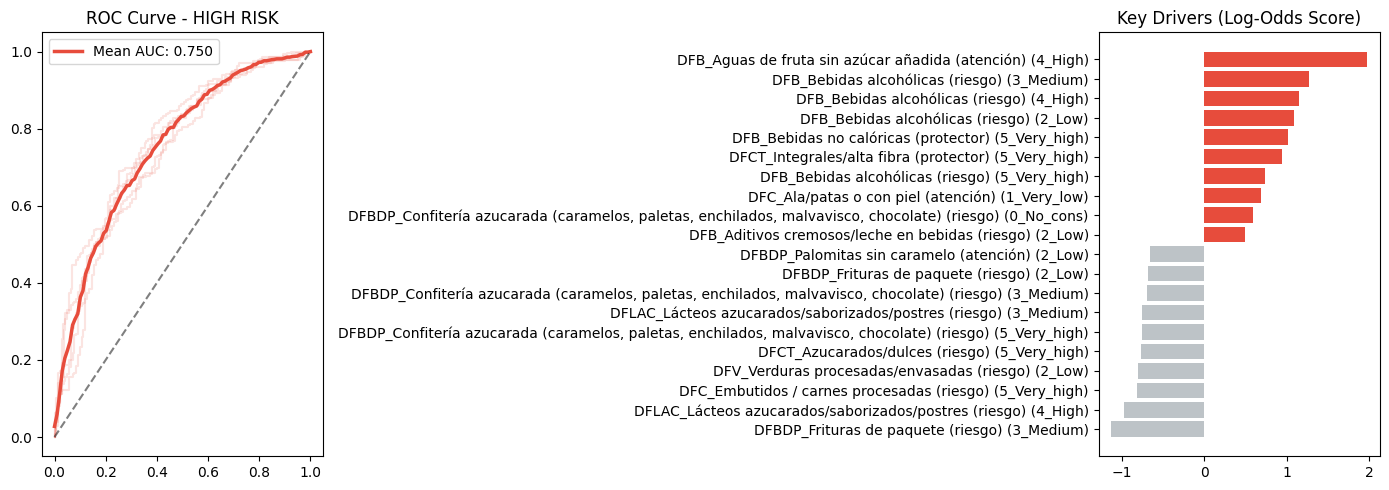


🚀 ANALIZANDO: HEALTHY


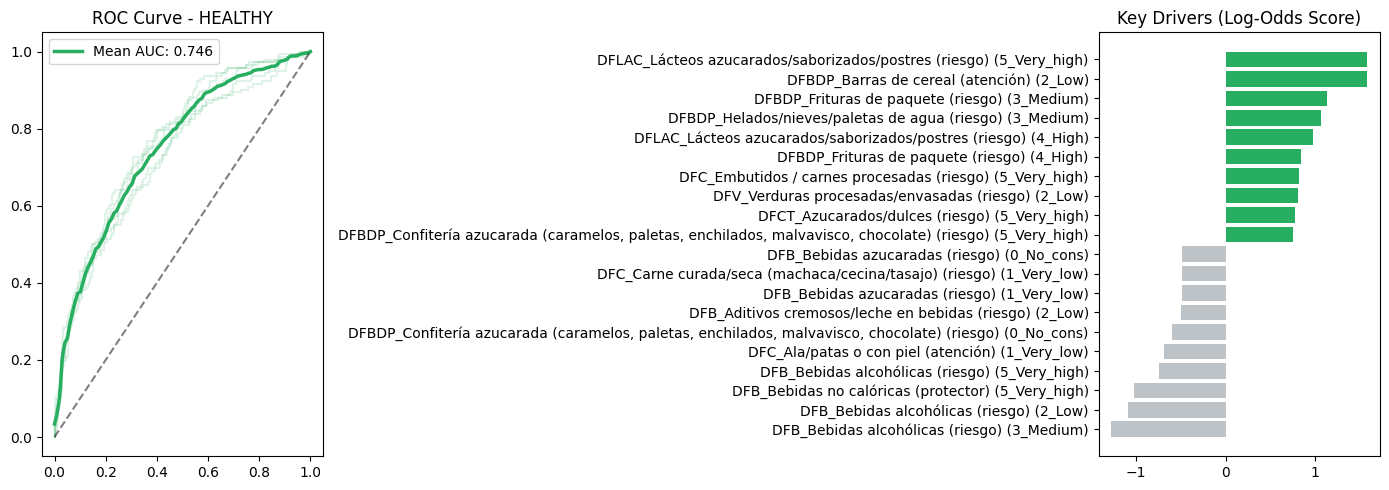


✅ Proceso completado. Resultados en: /content/Bayesian_Final_Results.xlsx


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import re
import warnings
import os
import bayes  # <--- Tu librería
from google.colab import drive
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, recall_score, matthews_corrcoef

# --- Configuración de Rutas ---
PATH_BASE = "/content/drive/MyDrive/POSTDOCTORADO C3/ENSANUT/2023/pruebas/NUTRICION/"
PATH_OUTPUT = "/content/Bayesian_Final_Results.xlsx"

# 1. HELPERS (Mantener igual para limpieza de labels)
def clean_label(text):
    text = re.sub(r'^\d+_', '', str(text))
    text = re.sub(r'\b[A-Z0-9]+_', '', text)
    return text.replace('_', ' ').strip().capitalize()

def clean_idx(df):
    d = df.copy()
    if "FOLIO_I" in [str(n).upper() for n in d.index.names]: d = d.reset_index()
    for c in ['FOLIO_I', 'FOLIO_INT']:
        if c in d.columns: d[c] = d[c].astype(str).str.strip()
    return d

# 2. CARGA Y PREPROCESAMIENTO (Igual que el tuyo)
if not os.path.exists('/content/drive'): drive.mount('/content/drive')

print("📦 Cargando datos...")
with open(PATH_BASE + "antro/antro_mx.pkl", "rb") as f: antro = pickle.load(f)
with open(PATH_BASE + "FFQ COLAPSED/matrix/FFQ_matriz_pa1xpa2xpa4.pkl", "rb") as f: ffq = pickle.load(f)

df_m = clean_idx(ffq).merge(clean_idx(antro)[['FOLIO_I', 'FOLIO_INT', 'edad', 'RCV_Alto']], on=['FOLIO_I', 'FOLIO_INT'])
df_m = df_m[(df_m['edad'] > 9) & (df_m['RCV_Alto'].notna())].reset_index(drop=True)

# Discretización FFQ
bins = [-0.001, 0.001, 1, 3, 7, 14, np.inf]
labs = ["0_No_cons", "1_Very_low", "2_Low", "3_Medium", "4_High", "5_Very_high"]
cols_ffq = [c for c in df_m.columns if str(c).startswith(('DFBDP_', 'DFB_', 'DFCT_', 'DFC_', 'DFV_', 'DFLAC_', 'DFLEG_'))]

dummies_list = [pd.get_dummies(pd.cut(df_m[col], bins=bins, labels=labs), prefix=col, prefix_sep='|') for col in cols_ffq]
df_dummies = pd.concat(dummies_list, axis=1)
y_true = df_m['RCV_Alto'].astype(int).values

# 3. ANÁLISIS REFACTORIZADO (Usando BayesClassifier)
def run_full_analysis(target_val, label, color):
    print(f"\n🚀 ANALIZANDO: {label}")
    y_bin = (y_true == target_val).astype(int)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    metrics_list, tprs = [], []
    base_fpr = np.linspace(0, 1, 100)

    # Instanciamos tu modelo
    clf = bayes.BayesClassifier(alpha=1.0, min_cases=10, use_prior=True, sep="|")

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)

    for i, (train_idx, test_idx) in enumerate(cv.split(df_dummies, y_bin)):
        # Fit & Predict usando tu librería
        clf.fit(df_dummies.iloc[train_idx], y_bin[train_idx])
        y_proba = clf.predict_proba(df_dummies.iloc[test_idx])[:, 1]
        y_pred = (y_proba >= 0.5).astype(int)

        # Métricas
        fpr, tpr, _ = roc_curve(y_bin[test_idx], y_proba)
        tprs.append(np.interp(base_fpr, fpr, tpr))
        tn, fp, fn, tp = confusion_matrix(y_bin[test_idx], y_pred).ravel()

        metrics_list.append({
            'Fold': i+1, 'AUC': auc(fpr, tpr),
            'Sens': recall_score(y_bin[test_idx], y_pred, zero_division=0),
            'Spec': tn/(tn+fp) if (tn+fp)>0 else 0,
            'Acc': accuracy_score(y_bin[test_idx], y_pred),
            'MCC': matthews_corrcoef(y_bin[test_idx], y_pred)
        })
        plt.plot(fpr, tpr, alpha=0.15, color=color)

    # Plot ROC Promedio
    mean_tpr = np.mean(tprs, axis=0)
    plt.plot(base_fpr, mean_tpr, color=color, lw=2.5, label=f"Mean AUC: {auc(base_fpr, mean_tpr):.3f}")
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.title(f"ROC Curve - {label}")
    plt.legend()

    # --- Drivers Plot (Usando clf.feature_table_) ---
    clf.fit(df_dummies, y_bin) # Fit final con todo
    table = clf.feature_table_

    top_drivers = pd.concat([table.nlargest(10, 'Score'), table.nsmallest(10, 'Score')]).sort_values('Score')

    plt.subplot(1, 2, 2)
    plt.barh(top_drivers['Subcategoría'] + " (" + top_drivers['Valor_Variable'] + ")",
             top_drivers['Score'], color=[color if x > 0 else '#bdc3c7' for x in top_drivers['Score']])
    plt.title("Key Drivers (Log-Odds Score)")
    plt.tight_layout()
    plt.show()

    return table, pd.DataFrame(metrics_list)

# 4. EJECUCIÓN FINAL
res_high, met_high = run_full_analysis(1, "HIGH RISK", "#e74c3c")
res_healthy, met_healthy = run_full_analysis(0, "HEALTHY", "#27ae60")

# Guardar a Excel
with pd.ExcelWriter(PATH_OUTPUT) as writer:
    res_high.to_excel(writer, sheet_name='Drivers_Risk', index=False)
    met_high.to_excel(writer, sheet_name='Metrics_Risk', index=False)

print(f"\n✅ Proceso completado. Resultados en: {PATH_OUTPUT}")

📦 Cargando datos...

🚀 INICIANDO AUDITORÍA TÉCNICA: HIGH RISK
📍 FOLD 1:
   [MATRIZ] TP:  232 | TN:   70 | FP:  73 | FN:  44
   [SCORES] AUC: 0.7699 | Sens: 0.8406 | Spec: 0.4895
            Acc: 0.7208 | MCC: 0.3517
--------------------------------------------------
📍 FOLD 2:
   [MATRIZ] TP:  229 | TN:   63 | FP:  79 | FN:  48
   [SCORES] AUC: 0.7367 | Sens: 0.8267 | Spec: 0.4437
            Acc: 0.6969 | MCC: 0.2900
--------------------------------------------------
📍 FOLD 3:
   [MATRIZ] TP:  232 | TN:   68 | FP:  74 | FN:  45
   [SCORES] AUC: 0.7625 | Sens: 0.8375 | Spec: 0.4789
            Acc: 0.7160 | MCC: 0.3375
--------------------------------------------------
📍 FOLD 4:
   [MATRIZ] TP:  246 | TN:   64 | FP:  78 | FN:  31
   [SCORES] AUC: 0.7508 | Sens: 0.8881 | Spec: 0.4507
            Acc: 0.7399 | MCC: 0.3830
--------------------------------------------------
📍 FOLD 5:
   [MATRIZ] TP:  234 | TN:   69 | FP:  73 | FN:  42
   [SCORES] AUC: 0.7285 | Sens: 0.8478 | Spec: 0.4859
  

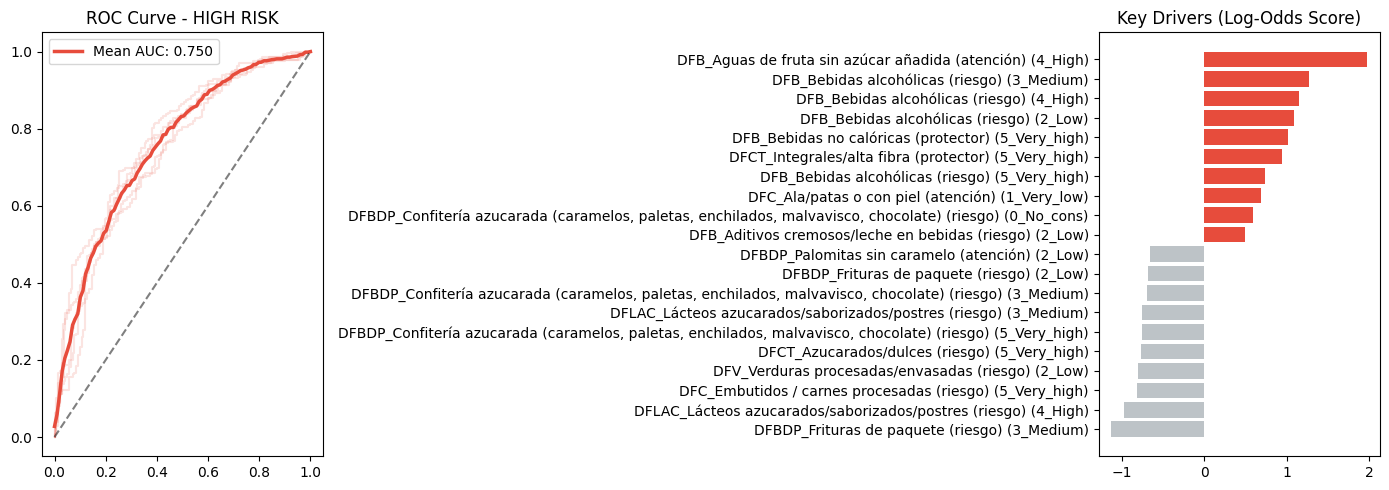


🚀 INICIANDO AUDITORÍA TÉCNICA: HEALTHY
📍 FOLD 1:
   [MATRIZ] TP:   72 | TN:  227 | FP:  49 | FN:  71
   [SCORES] AUC: 0.7664 | Sens: 0.5035 | Spec: 0.8225
            Acc: 0.7136 | MCC: 0.3410
--------------------------------------------------
📍 FOLD 2:
   [MATRIZ] TP:   71 | TN:  222 | FP:  55 | FN:  71
   [SCORES] AUC: 0.7405 | Sens: 0.5000 | Spec: 0.8014
            Acc: 0.6993 | MCC: 0.3112
--------------------------------------------------
📍 FOLD 3:
   [MATRIZ] TP:   76 | TN:  222 | FP:  55 | FN:  66
   [SCORES] AUC: 0.7575 | Sens: 0.5352 | Spec: 0.8014
            Acc: 0.7112 | MCC: 0.3437
--------------------------------------------------
📍 FOLD 4:
   [MATRIZ] TP:   68 | TN:  239 | FP:  38 | FN:  74
   [SCORES] AUC: 0.7414 | Sens: 0.4789 | Spec: 0.8628
            Acc: 0.7327 | MCC: 0.3720
--------------------------------------------------
📍 FOLD 5:
   [MATRIZ] TP:   74 | TN:  221 | FP:  55 | FN:  68
   [SCORES] AUC: 0.7257 | Sens: 0.5211 | Spec: 0.8007
            Acc: 0.7057 

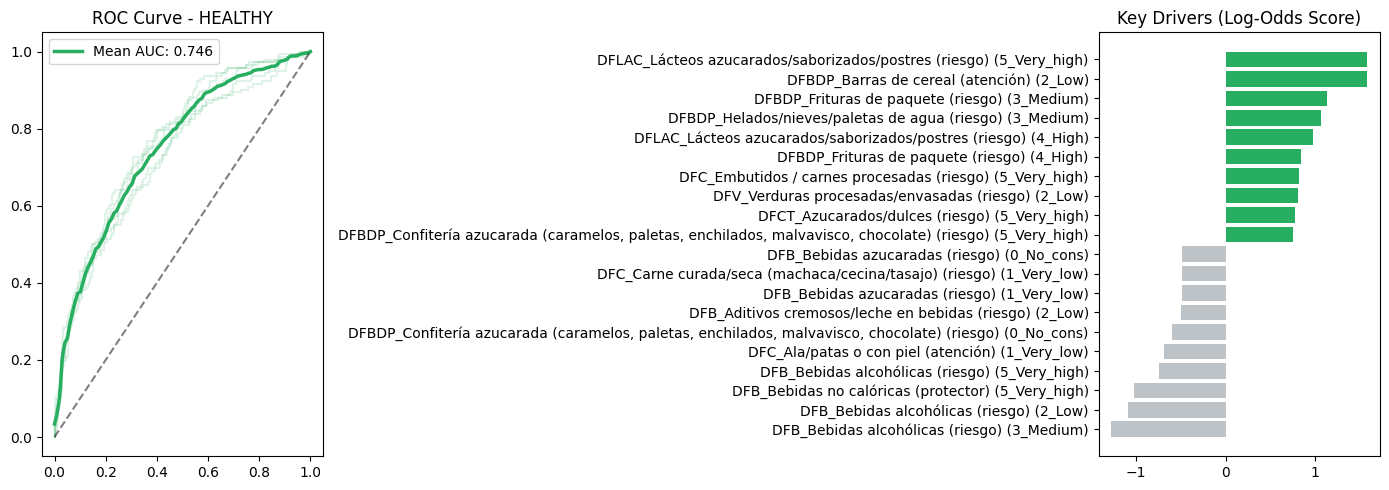


✅ Análisis completado con éxito. Excel generado en: /content/Bayesian_Final_Results.xlsx


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import re
import warnings
import os
import bayes  # <--- Tu librería
from google.colab import drive
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, recall_score, matthews_corrcoef

# --- Configuración de Rutas ---
PATH_BASE = "/content/drive/MyDrive/POSTDOCTORADO C3/ENSANUT/2023/pruebas/NUTRICION/"
PATH_OUTPUT = "/content/Bayesian_Final_Results.xlsx"

# 1. HELPERS
def clean_label(text):
    text = re.sub(r'^\d+_', '', str(text))
    text = re.sub(r'\b[A-Z0-9]+_', '', text)
    return text.replace('_', ' ').strip().capitalize()

def clean_idx(df):
    d = df.copy()
    if "FOLIO_I" in [str(n).upper() for n in d.index.names]: d = d.reset_index()
    for c in ['FOLIO_I', 'FOLIO_INT']:
        if c in d.columns: d[c] = d[c].astype(str).str.strip()
    return d

# 2. CARGA Y PREPROCESAMIENTO
if not os.path.exists('/content/drive'): drive.mount('/content/drive')

print("📦 Cargando datos...")
with open(PATH_BASE + "antro/antro_mx.pkl", "rb") as f: antro = pickle.load(f)
with open(PATH_BASE + "FFQ COLAPSED/matrix/FFQ_matriz_pa1xpa2xpa4.pkl", "rb") as f: ffq = pickle.load(f)

df_m = clean_idx(ffq).merge(clean_idx(antro)[['FOLIO_I', 'FOLIO_INT', 'edad', 'RCV_Alto']], on=['FOLIO_I', 'FOLIO_INT'])
df_m = df_m[(df_m['edad'] > 9) & (df_m['RCV_Alto'].notna())].reset_index(drop=True)

# Discretización FFQ
bins = [-0.001, 0.001, 1, 3, 7, 14, np.inf]
labs = ["0_No_cons", "1_Very_low", "2_Low", "3_Medium", "4_High", "5_Very_high"]
cols_ffq = [c for c in df_m.columns if str(c).startswith(('DFBDP_', 'DFB_', 'DFCT_', 'DFC_', 'DFV_', 'DFLAC_', 'DFLEG_'))]

dummies_list = [pd.get_dummies(pd.cut(df_m[col], bins=bins, labels=labs), prefix=col, prefix_sep='|') for col in cols_ffq]
df_dummies = pd.concat(dummies_list, axis=1)
y_true = df_m['RCV_Alto'].astype(int).values

# =============================================================================
# 3. ANÁLISIS CON MÉTRICAS DETALLADAS (AUDITORÍA FOLD POR FOLD)
# =============================================================================
def run_full_analysis(target_val, label, color):
    print("\n" + "="*70)
    print(f"🚀 INICIANDO AUDITORÍA TÉCNICA: {label}")
    print("="*70)

    y_bin = (y_true == target_val).astype(int)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    metrics_list, tprs = [], []
    base_fpr = np.linspace(0, 1, 100)

    clf = bayes.BayesClassifier(alpha=1.0, min_cases=10, use_prior=True, sep="|")

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)

    for i, (train_idx, test_idx) in enumerate(cv.split(df_dummies, y_bin)):
        # Fit & Predict
        clf.fit(df_dummies.iloc[train_idx], y_bin[train_idx])
        y_proba = clf.predict_proba(df_dummies.iloc[test_idx])[:, 1]
        y_pred = (y_proba >= 0.5).astype(int)

        # --- Cálculo de Matriz de Confusión Cruda ---
        tn, fp, fn, tp = confusion_matrix(y_bin[test_idx], y_pred).ravel()

        # --- Cálculo de Métricas ---
        fpr, tpr, _ = roc_curve(y_bin[test_idx], y_proba)
        tprs.append(np.interp(base_fpr, fpr, tpr))

        fold_metrics = {
            'Fold': i+1,
            'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
            'AUC': auc(fpr, tpr),
            'Sens': recall_score(y_bin[test_idx], y_pred, zero_division=0),
            'Spec': tn/(tn+fp) if (tn+fp)>0 else 0,
            'Acc': accuracy_score(y_bin[test_idx], y_pred),
            'MCC': matthews_corrcoef(y_bin[test_idx], y_pred)
        }
        metrics_list.append(fold_metrics)

        # --- Impresión en Consola Detallada ---
        print(f"📍 FOLD {i+1}:")
        print(f"   [MATRIZ] TP: {tp:4d} | TN: {tn:4d} | FP: {fp:3d} | FN: {fn:3d}")
        print(f"   [SCORES] AUC: {fold_metrics['AUC']:.4f} | Sens: {fold_metrics['Sens']:.4f} | Spec: {fold_metrics['Spec']:.4f}")
        print(f"            Acc: {fold_metrics['Acc']:.4f} | MCC: {fold_metrics['MCC']:.4f}")
        print("-" * 50)

        plt.plot(fpr, tpr, alpha=0.15, color=color)

    # DataFrame para cálculos estadísticos
    df_metrics = pd.DataFrame(metrics_list)

    # --- Resumen Final de Auditoría ---
    print(f"\n📊 RESUMEN FINAL - {label} (Promedio ± Desviación)")
    summary = df_metrics.drop(columns=['Fold']).agg(['mean', 'std']).T
    print(summary.to_string())
    print("-" * 70)

    # Plot ROC Promedio
    mean_tpr = np.mean(tprs, axis=0)
    plt.plot(base_fpr, mean_tpr, color=color, lw=2.5, label=f"Mean AUC: {auc(base_fpr, mean_tpr):.3f}")
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.title(f"ROC Curve - {label}")
    plt.legend()

    # --- Drivers Plot ---
    clf.fit(df_dummies, y_bin)
    table = clf.feature_table_
    top_drivers = pd.concat([table.nlargest(10, 'Score'), table.nsmallest(10, 'Score')]).sort_values('Score')

    plt.subplot(1, 2, 2)
    plt.barh(top_drivers['Subcategoría'] + " (" + top_drivers['Valor_Variable'] + ")",
             top_drivers['Score'], color=[color if x > 0 else '#bdc3c7' for x in top_drivers['Score']])
    plt.title("Key Drivers (Log-Odds Score)")
    plt.tight_layout()
    plt.show()

    return table, df_metrics

# 4. EJECUCIÓN FINAL
res_high, met_high = run_full_analysis(1, "HIGH RISK", "#e74c3c")
res_healthy, met_healthy = run_full_analysis(0, "HEALTHY", "#27ae60")

# Guardar a Excel
with pd.ExcelWriter(PATH_OUTPUT) as writer:
    res_high.to_excel(writer, sheet_name='Drivers_Risk', index=False)
    met_high.to_excel(writer, sheet_name='Metrics_Risk', index=False)
    res_healthy.to_excel(writer, sheet_name='Drivers_Healthy', index=False)
    met_healthy.to_excel(writer, sheet_name='Metrics_Healthy', index=False)

print(f"\n✅ Análisis completado con éxito. Excel generado en: {PATH_OUTPUT}")

In [6]:
res_high.head(10)


,Subcategoría,Valor_Variable,N(CX),N(X),P(C|X),P(C),Epsilon,Score
0,DFB_Aguas de fruta sin azúcar añadida (atención),4_High,13,13,1.000000,0.660458,2.585207,1.977794
1,DFB_Bebidas alcohólicas (riesgo),3_Medium,75,85,0.882353,0.660458,4.320030,1.271575
2,DFB_Bebidas alcohólicas (riesgo),4_High,60,69,0.869565,0.660458,3.667950,1.147025
3,DFB_Bebidas alcohólicas (riesgo),2_Low,85,99,0.858586,0.660458,4.162871,1.085034
4,DFB_Bebidas no calóricas (protector),5_Very_high,138,163,0.846626,0.660458,5.019125,1.015114
5,DFCT_Integrales/alta fibra (protector),5_Very_high,29,34,0.852941,0.660458,2.370075,0.948174
6,DFB_Bebidas alcohólicas (riesgo),5_Very_high,60,74,0.810811,0.660458,2.731221,0.741560
7,DFC_Ala/patas o con piel (atención),1_Very_low,134,168,0.797619,0.660458,3.754177,0.688663
8,"DFBDP_Confitería azucarada (caramelos, paletas...",0_No_cons,641,823,0.778858,0.660458,7.172658,0.593839
9,DFB_Aditivos cremosos/leche en bebidas (riesgo),2_Low,82,107,0.766355,0.660458,2.313157,0.499481


In [7]:
res_high.sort_values(by='Score', ascending=True).head(10)

,Subcategoría,Valor_Variable,N(CX),N(X),P(C|X),P(C),Epsilon,Score
269,DFBDP_Frituras de paquete (riesgo),3_Medium,53,138,0.384058,0.660458,-6.856605,-1.126627
268,DFLAC_Lácteos azucarados/saborizados/postres (...,4_High,35,83,0.421687,0.660458,-4.593595,-0.969565
267,DFC_Embutidos / carnes procesadas (riesgo),5_Very_high,28,61,0.459016,0.660458,-3.322354,-0.820328
266,DFV_Verduras procesadas/envasadas (riesgo),2_Low,12,26,0.461538,0.660458,-2.141884,-0.804364
265,DFCT_Azucarados/dulces (riesgo),5_Very_high,16,34,0.470588,0.660458,-2.337906,-0.772489
264,"DFBDP_Confitería azucarada (caramelos, paletas...",5_Very_high,81,170,0.476471,0.660458,-5.065758,-0.754354
263,DFLAC_Lácteos azucarados/saborizados/postres (...,3_Medium,85,178,0.477528,0.660458,-5.153788,-0.750211
262,"DFBDP_Confitería azucarada (caramelos, paletas...",3_Medium,153,312,0.490385,0.660458,-6.343743,-0.699485
261,DFBDP_Frituras de paquete (riesgo),2_Low,154,312,0.493590,0.660458,-6.224192,-0.686743
260,DFC_Carne curada/seca (machaca/cecina/tasajo) ...,2_Low,14,28,0.500000,0.660458,-1.792967,-0.661264


#Clustering supervisado

In [8]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 20.4 MB/s eta 0:00:00


In [9]:
!pip install optuna

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib.patches as patches
import pandas as pd
import numpy as np
import pickle
import re
import math
import textwrap
import warnings
import os
import optuna
import lightgbm as lgb
from collections import defaultdict
from google.colab import drive

# Librerías para ROC, CV y métricas de clasificación
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_curve, auc, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, matthews_corrcoef, balanced_accuracy_score
)
from scipy.special import expit  # Función Sigmoide

# =============================================================================
# 0. CONFIGURACIÓN Y CARGA
# =============================================================================
warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

print("🚀 INICIANDO SCRIPT COMPLETO: OPTIMIZACIÓN + EVALUACIÓN...")

# 1. Montar Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print("📂 Drive ya está montado.")

# 2. Rutas de Archivos (Ajustadas a tu estructura)
path_base_dir = "/content/drive/MyDrive/POSTDOCTORADO C3/ENSANUT/2023/pruebas/NUTRICION/"
path_antro = path_base_dir + "antro/antro_mx.pkl"
path_ffq = path_base_dir + "FFQ COLAPSED/matrix/FFQ_matriz_pa1xpa2xpa4.pkl"
path_salida_excel = "/content/Resultados_Bayesiano_Final_Detallado.xlsx"

# 3. Carga de datos
try:
    with open(path_antro, "rb") as f:
        antro_mx = pickle.load(f)
    with open(path_ffq, "rb") as f:
        FFQc_mx = pickle.load(f)
    print("   ✅ Archivos cargados correctamente.")
except Exception as e:
    print(f"❌ Error cargando archivos: {e}")
    raise e

# =============================================================================
# 1. PREPARACIÓN DE DATOS
# =============================================================================
def clean_idx(df):
    d = df.copy()
    if "FOLIO_I" in [str(n).upper() for n in d.index.names]:
        d = d.reset_index()
    d.columns = d.columns.str.strip()
    for c in ['FOLIO_I', 'FOLIO_INT']:
        if c in d.columns:
            d[c] = d[c].astype(str).str.strip()
    return d

antro_mx = antro_mx[antro_mx['edad'] > 9]
tmp_ffq = clean_idx(FFQc_mx)
tmp_antro = clean_idx(antro_mx)

FFQ_PREFIXES = ('DFBDP_', 'DFB_', 'DFCT_', 'DFC_', 'DFFAST_', 'DFF_', 'DFLAC_', 'DFLEG_', 'DFMAIZ_', 'DFMISC_', 'DFPES_', 'DFSOP_', 'DFV_')
cols_ffq = [c for c in tmp_ffq.columns if str(c).startswith(FFQ_PREFIXES)]

df_master = tmp_ffq[['FOLIO_I', 'FOLIO_INT'] + cols_ffq].merge(
    tmp_antro[['FOLIO_I', 'FOLIO_INT', 'edad', 'RCV_Alto']],
    on=['FOLIO_I', 'FOLIO_INT'], how='inner'
)

df_clean = df_master[(df_master['edad'] > 9) & (df_master['RCV_Alto'].notna())].copy()

# --- DEFINICIÓN DE VARIABLES PARA EL MODELO ---
y_true = df_clean['RCV_Alto'].astype(int).values
X_analysis = df_clean[cols_ffq].select_dtypes(include=[np.number])

# EL FIX: Definir X_np y y_np antes de Optuna
X_np = X_analysis.values
y_np = y_true

print(f"📊 Dataset listo: {X_np.shape[0]} filas, {X_np.shape[1]} columnas.")


🚀 INICIANDO SCRIPT COMPLETO: OPTIMIZACIÓN + EVALUACIÓN...
📂 Drive ya está montado.
   ✅ Archivos cargados correctamente.
📊 Dataset listo: 2094 filas, 73 columnas.


In [11]:
print("\n--- BLOQUE 2: OPTIMIZACIÓN DE HIPERPARÁMETROS ---")

from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_categorical('n_estimators', [1000,2000]),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    # CV rápido de 3 folds para optimizar
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        lgb.LGBMClassifier(**params, n_jobs=-1),
        X_np, y_np, cv=cv, scoring='roc_auc'
    )
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) # Ajusta n_trials según tu paciencia

best_params = study.best_params
print(f"✅ Mejores parámetros (AUC: {study.best_value:.4f}): {best_params}")

[I 2026-01-11 22:40:46,300] A new study created in memory with name: no-name-69e976db-9d4f-43e3-950c-f384209bf547



--- BLOQUE 2: OPTIMIZACIÓN DE HIPERPARÁMETROS ---


[I 2026-01-11 22:40:53,019] Trial 0 finished with value: 0.740761080144369 and parameters: {'n_estimators': 2000, 'learning_rate': 0.04107910051766716, 'num_leaves': 33, 'max_depth': 9, 'min_child_samples': 61, 'subsample': 0.6914686119585385, 'colsample_bytree': 0.8028024727324317, 'reg_alpha': 1.3840086744506328e-08, 'reg_lambda': 7.263090398958035e-05}. Best is trial 0 with value: 0.740761080144369.
[I 2026-01-11 22:40:54,835] Trial 1 finished with value: 0.7559881746707305 and parameters: {'n_estimators': 1000, 'learning_rate': 0.03095978521660071, 'num_leaves': 98, 'max_depth': 7, 'min_child_samples': 91, 'subsample': 0.6737487634967751, 'colsample_bytree': 0.821110827989725, 'reg_alpha': 0.18935588922811206, 'reg_lambda': 5.883659097470727e-08}. Best is trial 1 with value: 0.7559881746707305.
[I 2026-01-11 22:40:56,529] Trial 2 finished with value: 0.7511463796370026 and parameters: {'n_estimators': 1000, 'learning_rate': 0.09564741874865387, 'num_leaves': 59, 'max_depth': 7, 'mi

✅ Mejores parámetros (AUC: 0.7762): {'n_estimators': 1000, 'learning_rate': 0.011169170078281662, 'num_leaves': 39, 'max_depth': 4, 'min_child_samples': 94, 'subsample': 0.8709609347100213, 'colsample_bytree': 0.6010498393248049, 'reg_alpha': 1.0801763846143847e-06, 'reg_lambda': 3.3237508338725145e-08}



--- BLOQUE 3: VALIDACIÓN, ENTRENAMIENTO FINAL Y SHAP ---
1. Ejecutando Cross-Validation (5 Folds) para evaluar rendimiento...


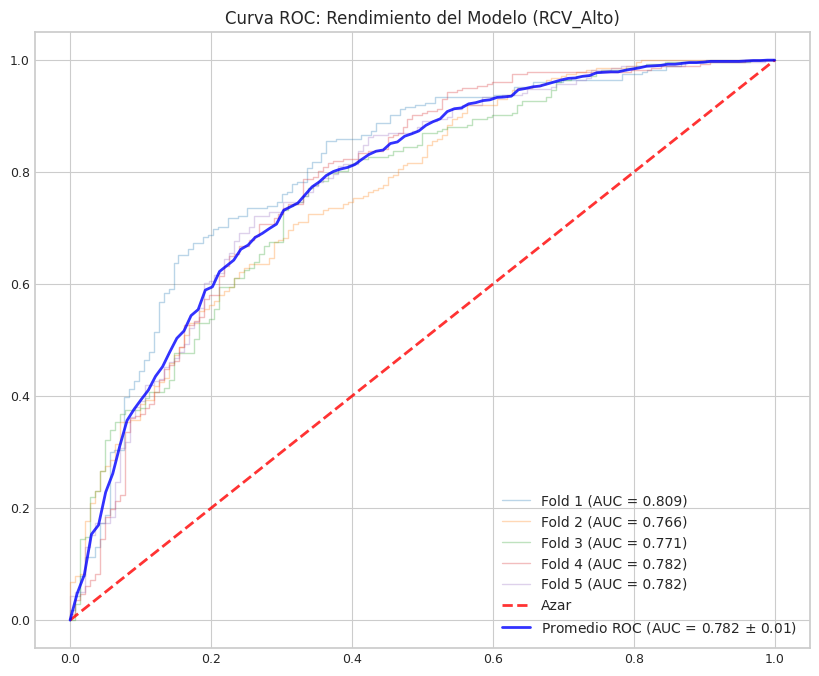


TABLA DE MÉTRICAS POR FOLD:
    Fold    AUC    MCC    Acc Bal_Acc   Sens   Spec Precision    NPV     F1    FPR    FNR       TP      TN      FP      FN
       1 0.8087 0.4743 0.7733  0.7201 0.8877 0.5524    0.7929 0.7182 0.8376 0.4476 0.1123      245      79      64      31
       2 0.7664 0.3506 0.7208  0.6653 0.8375 0.4930    0.7632 0.6087 0.7986 0.5070 0.1625      232      70      72      45
       3 0.7712 0.3863 0.7399  0.6745 0.8773 0.4718    0.7642 0.6634 0.8168 0.5282 0.1227      243      67      75      34
       4 0.7824 0.4422 0.7637  0.6926 0.9134 0.4718    0.7713 0.7363 0.8364 0.5282 0.0866      253      67      75      24
       5 0.7819 0.4231 0.7536  0.6937 0.8804 0.5070    0.7764 0.6857 0.8251 0.4930 0.1196      243      72      70      33
Promedio 0.7821 0.4153 0.7502  0.6892 0.8793 0.4992    0.7736 0.6824 0.8229 0.5008 0.1207 243.2000 71.0000 71.2000 33.4000

2. Entrenando modelo final con el 100% de los datos...


LGBMClassifier(colsample_bytree=0.6010498393248049,
               learning_rate=0.011169170078281662, max_depth=4,
               min_child_samples=94, n_estimators=1000, n_jobs=-1,
               num_leaves=39, reg_alpha=1.0801763846143847e-06,
               reg_lambda=3.3237508338725145e-08, subsample=0.8709609347100213)

In [53]:
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_curve, auc, roc_auc_score, confusion_matrix,
                             matthews_corrcoef, accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score)
import numpy as np
import pandas as pd
import shap
import lightgbm as lgb

print("\n--- BLOQUE 3: VALIDACIÓN, ENTRENAMIENTO FINAL Y SHAP ---")

# =============================================================================
# PARTE A: VALIDACIÓN CRUZADA (CV=5) CON TODAS LAS MÉTRICAS
# =============================================================================
print("1. Ejecutando Cross-Validation (5 Folds) para evaluar rendimiento...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

# Lista para guardar las métricas de cada fold
resultados_cv = []

fig, ax = plt.subplots(figsize=(10, 8))

for i, (train, test) in enumerate(cv.split(X_np, y_np)):
    # 1. Entrenar modelo
    model_cv = lgb.LGBMClassifier(**best_params, n_jobs=-1, verbose=-1)
    model_cv.fit(X_np[train], y_np[train])

    # 2. Predecir Probabilidades (para AUC y ROC)
    probas_ = model_cv.predict_proba(X_np[test])[:, 1]

    # 3. Predecir Clases (0 o 1) para métricas basadas en matriz de confusión
    preds_ = model_cv.predict(X_np[test])

    # --- CÁLCULO DE CURVA ROC Y AUC ---
    fpr, tpr, thresholds = roc_curve(y_np[test], probas_)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    ax.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Fold {i+1} (AUC = {roc_auc:.3f})')

    # --- CÁLCULO DE MÉTRICAS DETALLADAS ---
    tn, fp, fn, tp = confusion_matrix(y_np[test], preds_).ravel()

    # Cálculos manuales para métricas específicas
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensibilidad / Recall
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0  # Especificidad
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0   # Valor Predictivo Negativo
    fpr_val = fp / (tn + fp) if (tn + fp) > 0 else 0 # Tasa de Falsos Positivos (1-Spec)
    fnr_val = fn / (tp + fn) if (tp + fn) > 0 else 0 # Tasa de Falsos Negativos (1-Sens)

    # Métricas de sklearn
    mcc = matthews_corrcoef(y_np[test], preds_)
    acc = accuracy_score(y_np[test], preds_)
    bal_acc = balanced_accuracy_score(y_np[test], preds_)
    prec = precision_score(y_np[test], preds_, zero_division=0)
    f1 = f1_score(y_np[test], preds_)

    # Guardar en la lista
    resultados_cv.append({
        "Fold": i + 1,
        "AUC": roc_auc,
        "MCC": mcc,
        "Acc": acc,
        "Bal_Acc": bal_acc,
        "Sens": sens,
        "Spec": spec,
        "Precision": prec,
        "NPV": npv,
        "F1": f1,
        "FPR": fpr_val,
        "FNR": fnr_val,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })
TARGET_COL = "RCV_Alto"


# --- GRAFICAR PROMEDIO ROC ---
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Azar', alpha=.8)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Promedio ROC (AUC = %0.3f $\pm$ %0.2f)' % (mean_auc, std_auc),
        lw=2, alpha=.8)
ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title=f"Curva ROC: Rendimiento del Modelo ({TARGET_COL})")
ax.legend(loc="lower right")
plt.show()

# =============================================================================
# IMPRIMIR TABLA DE RESULTADOS
# =============================================================================
df_resultados = pd.DataFrame(resultados_cv)

# Agregar fila de promedio al final
promedios = df_resultados.mean()
promedios["Fold"] = "Promedio" # Etiqueta para la fila
df_resultados = pd.concat([df_resultados, promedios.to_frame().T], ignore_index=True)

# Formato de visualización (3 decimales para floats, enteros para conteos)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\nTABLA DE MÉTRICAS POR FOLD:")
# Formateamos solo para imprimir bonito
print(df_resultados.to_string(formatters={
    'AUC': '{:,.3f}'.format, 'MCC': '{:,.3f}'.format, 'Acc': '{:,.3f}'.format,
    'Bal_Acc': '{:,.3f}'.format, 'Sens': '{:,.3f}'.format, 'Spec': '{:,.3f}'.format,
    'Precision': '{:,.3f}'.format, 'NPV': '{:,.3f}'.format, 'F1': '{:,.3f}'.format,
    'FPR': '{:,.3f}'.format, 'FNR': '{:,.3f}'.format,
    'TP': '{:.0f}'.format, 'TN': '{:.0f}'.format, 'FP': '{:.0f}'.format, 'FN': '{:.0f}'.format
}, index=False))

# =============================================================================
# PARTE B: ENTRENAMIENTO FINAL (100% DATOS)
# =============================================================================
print("\n2. Entrenando modelo final con el 100% de los datos...")
final_model = lgb.LGBMClassifier(**best_params, n_jobs=-1)
final_model.fit(X_np, y_np)

In [54]:
# --- DEFINICIÓN DE VARIABLES PARA EL MODELO ---
y_true = df_clean['RCV_Alto'].astype(int).values
X_analysis = df_clean[cols_ffq].select_dtypes(include=[np.number])

# EL FIX: Definir X_np y y_np antes de Optuna
X_np = X_analysis.values
y_np = y_true

In [55]:
X_df = X_analysis

3. Calculando valores SHAP globales...
✅ Matriz SHAP lista: (2094, 73)
📊 Estadísticas SHAP -> Max Abs: 1.4462 | Mean Abs: 0.0538

4. Generando Beeswarm Plot Global...
✅ Nombres de características limpiados para el gráfico.


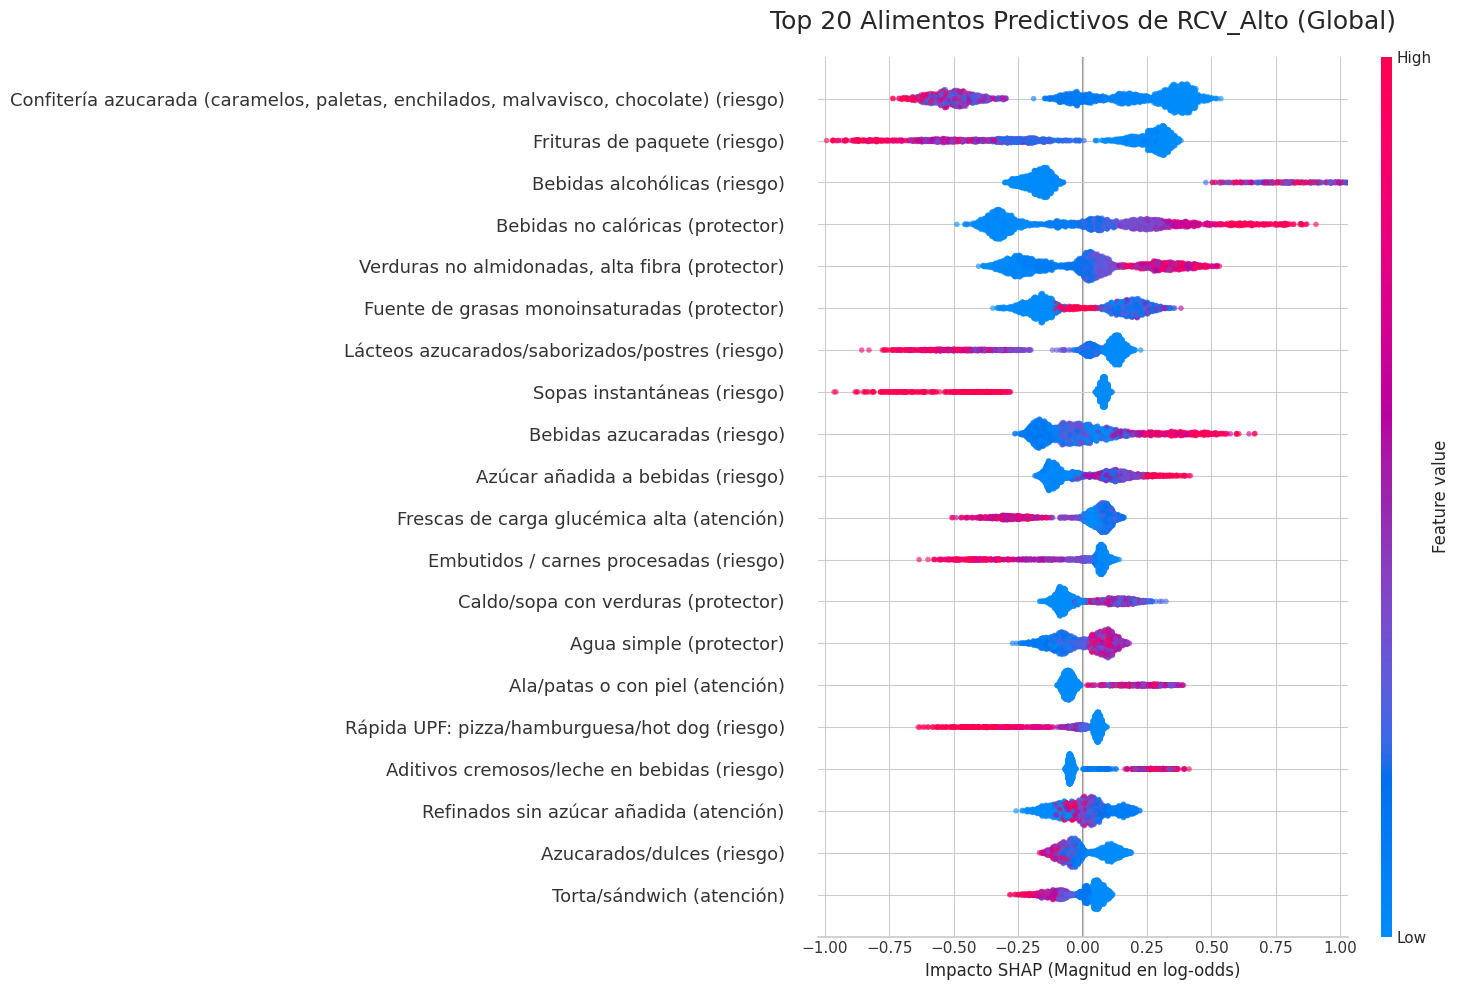


4. Generando Beeswarm Plot Global...
✅ Nombres limpiados: sin siglas ni paréntesis.


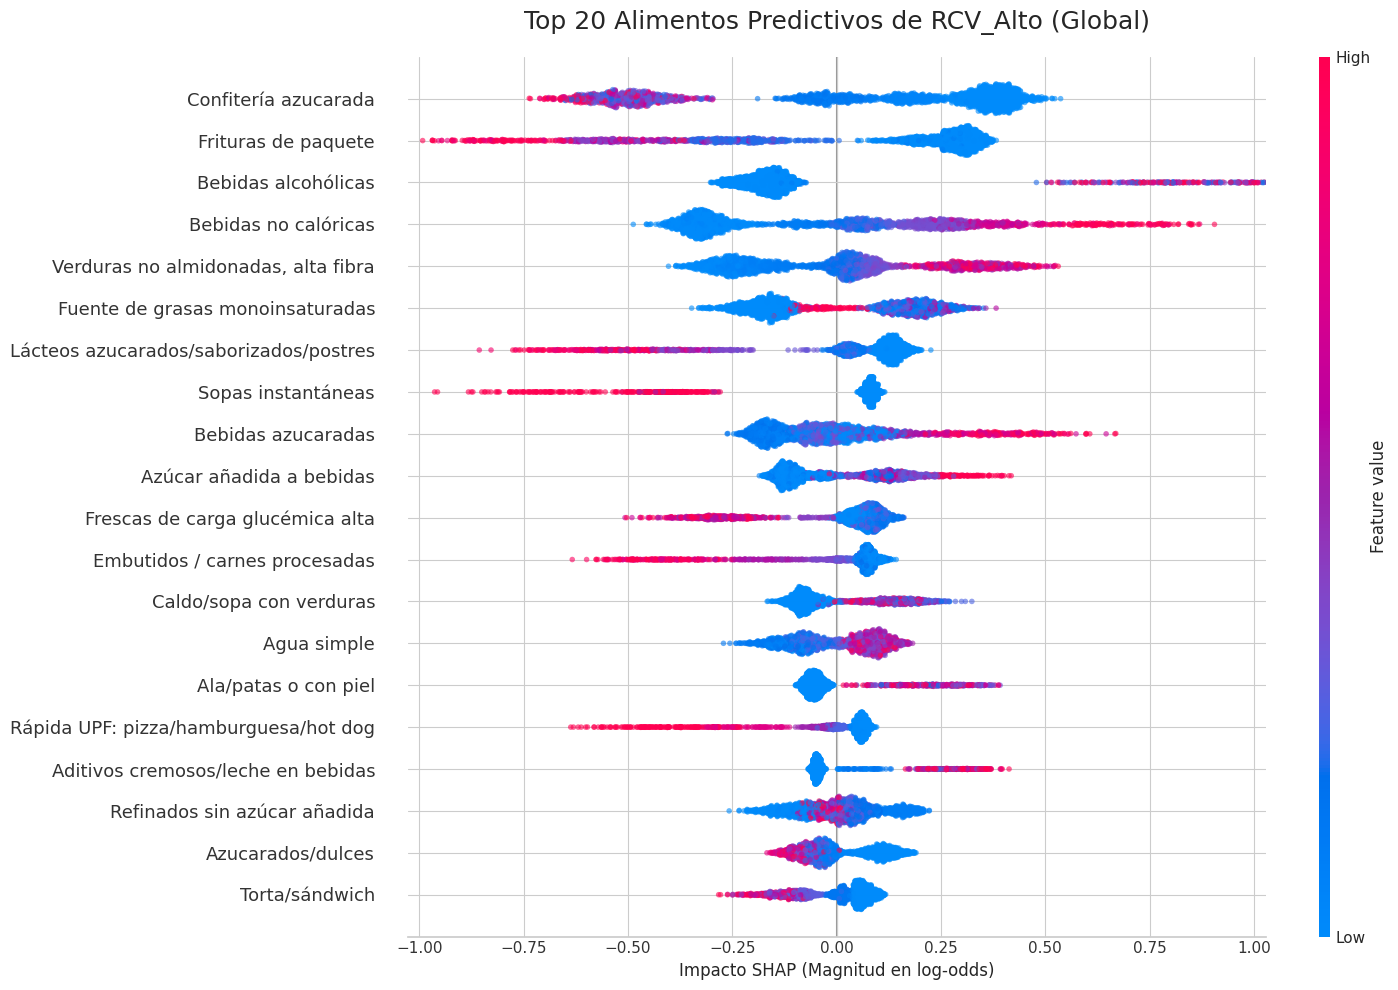

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap
# Importamos re para expresiones regulares (aunque pandas lo maneja internamente, es bueno tenerlo)
import re
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap

print("3. Calculando valores SHAP globales...")
explainer = shap.TreeExplainer(final_model)
shap_results = explainer.shap_values(X_np)

# Manejo de salida binaria (LightGBM/XGBoost a veces devuelven lista)
if isinstance(shap_results, list):
    print("ℹ️ Detectada lista de clases, seleccionando clase positiva (índice 1).")
    shap_values = shap_results[1]
else:
    shap_values = shap_results

# Validación de dimensiones
assert len(shap_values) == len(df_master), "❌ ERROR CRÍTICO: Desfase de dimensiones."
print(f"✅ Matriz SHAP lista: {shap_values.shape}")

# =============================================================================
# DIAGNÓSTICO DE VALORES (PARA ENTENDER POR QUÉ SE VE MAL)
# =============================================================================
max_val = np.max(np.abs(shap_values))
mean_val = np.mean(np.abs(shap_values))
print(f"📊 Estadísticas SHAP -> Max Abs: {max_val:.4f} | Mean Abs: {mean_val:.4f}")

if max_val < 0.001:
    print("⚠️ ADVERTENCIA: Los valores SHAP son extremadamente bajos. El modelo podría no estar aprendiendo mucho de estas variables.")


# =============================================================================
# PARTE C: BEESWARM GLOBAL ROBUSTO
# =============================================================================
print("\n4. Generando Beeswarm Plot Global...")

# 1. Asegurar que X_df sea puramente numérico para el coloreado
X_df_numeric = X_df.select_dtypes(include=[np.number])

# --- NUEVO BLOQUE: LIMPIEZA DE NOMBRES DE COLUMNAS ---
# Creamos una copia para no alterar el DataFrame original por si se usa luego
X_plot = X_df_numeric.copy()

# Usamos una expresión regular para eliminar los prefijos.
# r'^[A-Z]+_' significa:
# ^      -> Al inicio del texto
# [A-Z]+ -> Una o más letras mayúsculas
# _      -> Seguidas de un guion bajo
X_plot.columns = X_plot.columns.str.replace(r'^[A-Z]+_', '', regex=True)

# Ejemplo de lo que hace: "DFBDP_Confitería azucarada..." -> "Confitería azucarada..."
print("✅ Nombres de características limpiados para el gráfico.")
# -----------------------------------------------------


# 2. Configuración de la figura
fig = plt.figure(figsize=(15, 10))

# 3. Plotting con control manual
# ¡IMPORTANTE! Ahora usamos 'X_plot' en lugar de 'X_df_numeric'
shap.summary_plot(
    shap_values,
    X_plot,           # <-- USAMOS EL DATAFRAME CON NOMBRES LIMPIOS
    max_display=20,
    show=False,
    plot_size=None,
    alpha=0.6,
    plot_type='dot'
)

# 4. Ajuste INTELIGENTE del eje X
all_vals = np.abs(shap_values.flatten())
xlim_val = np.percentile(all_vals, 99.9) * 1.1

if xlim_val < 0.001:
    xlim_val = 0.01

plt.xlim(-xlim_val, xlim_val)

# 5. Estética final
plt.title(f"Top 20 Alimentos Predictivos de {TARGET_COL} (Global)", fontsize=18, pad=20)
plt.xlabel("Impacto SHAP (Magnitud en log-odds)", fontsize=12)
plt.tight_layout()

plt.show()


# =============================================================================
# PARTE C: BEESWARM GLOBAL ROBUSTO (ACTUALIZADO)
# =============================================================================
print("\n4. Generando Beeswarm Plot Global...")

X_df_numeric = X_df.select_dtypes(include=[np.number])

# --- BLOQUE DE LIMPIEZA DE NOMBRES ---
X_plot = X_df_numeric.copy()

# 1. Quitar los acrónimos (DFBDP_, etc.) - YA LO TENÍAS
X_plot.columns = X_plot.columns.str.replace(r'^[A-Z]+_', '', regex=True)

# 2. Quitar TODO lo que está entre paréntesis (incluyendo el paréntesis mismo)
# r'\s*\('  -> Busca espacios opcionales seguidos de un paréntesis abierto
# .* -> Seguido de cualquier cosa (greedy)
# \)'       -> Hasta el último paréntesis cerrado
X_plot.columns = X_plot.columns.str.replace(r'\s*\(.*\)', '', regex=True)

# Ejemplo de resultado:
# Antes: "Confitería azucarada (caramelos...) (riesgo)" -> Ahora: "Confitería azucarada"
# Antes: "Frituras de paquete (riesgo)"                 -> Ahora: "Frituras de paquete"
print("✅ Nombres limpiados: sin siglas ni paréntesis.")
# -------------------------------------

fig = plt.figure(figsize=(15, 10))

shap.summary_plot(
    shap_values,
    X_plot,       # Usamos el dataframe limpio
    max_display=20,
    show=False,
    plot_size=None,
    alpha=0.6,
    plot_type='dot'
)

# Ajuste del eje X
all_vals = np.abs(shap_values.flatten())
xlim_val = np.percentile(all_vals, 99.9) * 1.1
if xlim_val < 0.001: xlim_val = 0.01
plt.xlim(-xlim_val, xlim_val)

plt.title(f"Top 20 Alimentos Predictivos de {TARGET_COL} (Global)", fontsize=18, pad=20)
plt.xlabel("Impacto SHAP (Magnitud en log-odds)", fontsize=12)
plt.tight_layout()

plt.show()

In [51]:
!pip install igraph
!pip install leidenalg


🚀 1/5 Reduciendo dimensiones con PCA...
🚀 2/5 Ejecutando UMAP 3D...
🔍 3/5 Calculando métricas para optimización...
✅ Resolución Óptima Sugerida: 0.2700 (5 clusters)


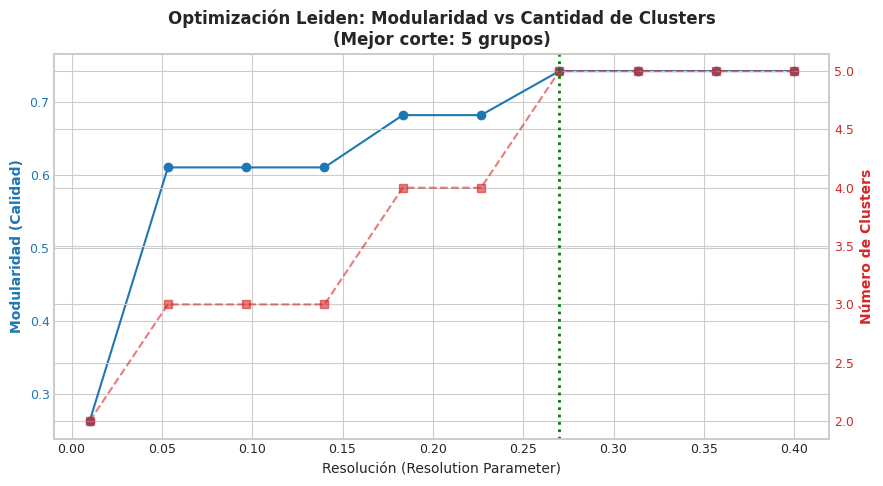

In [ ]:
# =============================================================================
# CÓDIGO MAESTRO FINAL: UMAP 3D + OPTIMIZACIÓN VISUAL (CODO) + 3D PLOT
# =============================================================================

import umap
import leidenalg
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
from mpl_toolkits.mplot3d import Axes3D

# --- 1. CONFIGURACIÓN VISUAL ---
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})
VIEW_ELEV, VIEW_AZIM = 25, 135

def draw_bounding_cube(ax, data, color='gray', alpha=0.2):
    min_x, min_y, min_z = data.min(axis=0)
    max_x, max_y, max_z = data.max(axis=0)
    v = np.array([
        [min_x, min_y, min_z], [max_x, min_y, min_z], [max_x, max_y, min_z], [min_x, max_y, min_z],
        [min_x, min_y, max_z], [max_x, min_y, max_z], [max_x, max_y, max_z], [min_x, max_y, max_z]
    ])
    edges = [(0,1), (1,2), (2,3), (3,0), (4,5), (5,6), (6,7), (7,4), (0,4), (1,5), (2,6), (3,7)]
    for start, end in edges:
        ax.plot3D(*zip(v[start], v[end]), color=color, alpha=alpha, lw=0.8, linestyle='--')

# --- 2. PROCESAMIENTO DE DATOS ---
# Asegura que tus datos estén en 'data_input'
data_input = shap_values if 'shap_values' in globals() else X_np

print("🚀 1/5 Reduciendo dimensiones con PCA...")
pca = PCA(n_components=10)
data_pca = pca.fit_transform(data_input)

# =============================================================================
# PASO 1: GENERACIÓN DEL EMBEDDING 3D
# =============================================================================
print("🚀 2/5 Ejecutando UMAP 3D...")
reducer = umap.UMAP(n_neighbors=600, min_dist=0.1, n_components=3, random_state=42, metric='euclidean',n_epochs=200)
embedding_3d = reducer.fit_transform(data_pca)

# =============================================================================
# PASO 2: BARIDO DE RESOLUCIÓN (OPTIMIZACIÓN)
# =============================================================================
print("🔍 3/5 Calculando métricas para optimización...")

# Grafo sobre el espacio UMAP 3D
adj_3d = kneighbors_graph(embedding_3d, n_neighbors=250, mode='connectivity', include_self=False)
g = ig.Graph(directed=False)
g.add_vertices(adj_3d.shape[0])
g.add_edges(list(zip(*adj_3d.nonzero())))

resolutions = np.linspace(0.01, 0.4, 10) # Rango de prueba
modularity_scores = []
n_clusters_list = []

for res in resolutions:
    part = leidenalg.find_partition(g, leidenalg.RBConfigurationVertexPartition,
                                   resolution_parameter=res, seed=42)
    modularity_scores.append(part.modularity)
    n_clusters_list.append(len(part))

# Encontrar el máximo matemático
best_idx = np.argmax(modularity_scores)
best_res = resolutions[best_idx]
best_n_clusters = n_clusters_list[best_idx]
print(f"✅ Resolución Óptima Sugerida: {best_res:.4f} ({best_n_clusters} clusters)")

# =============================================================================
# PASO 2.5: MOSTRAR GRÁFICA DE DECISIÓN (CODO) EN COLAB
# =============================================================================
# Usamos un estilo con rejilla solo para este gráfico 2D
with sns.axes_style("whitegrid"):
    fig_elbow, ax1 = plt.subplots(figsize=(10, 5))

    # Eje Izquierdo: Modularidad
    color = 'tab:blue'
    ax1.set_xlabel('Resolución (Resolution Parameter)')
    ax1.set_ylabel('Modularidad (Calidad)', color=color, fontweight='bold')
    ax1.plot(resolutions, modularity_scores, color=color, marker='o', label='Modularidad')
    ax1.tick_params(axis='y', labelcolor=color)

    # Eje Derecho: Número de Clusters
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Número de Clusters', color=color, fontweight='bold')
    ax2.plot(resolutions, n_clusters_list, color=color, marker='s', linestyle='--', alpha=0.6, label='N Clusters')
    ax2.tick_params(axis='y', labelcolor=color)

    # Línea vertical del óptimo
    plt.axvline(x=best_res, color='green', linestyle=':', linewidth=2, label=f'Óptimo: {best_res:.3f}')

    plt.title(f'Optimización Leiden: Modularidad vs Cantidad de Clusters\n(Mejor corte: {best_n_clusters} grupos)', fontweight='bold')
    plt.show() # <--- ¡ESTO HARÁ QUE SE VEA EN COLAB!

# =============================================================================
# PASO 3: VISUALIZACIÓN FINAL 3D
# =============================================================================
print("🎨 4/5 Generando visualización 3D...")

# Recalcular partición final con el mejor parámetro
partition = leidenalg.find_partition(g, leidenalg.RBConfigurationVertexPartition,
                                     resolution_parameter=best_res, seed=42)
cluster_labels = np.array(partition.membership)
n_groups = len(np.unique(cluster_labels))

# Estilo blanco limpio para 3D
sns.set_style("white")
fig = plt.figure(figsize=(22, 9))
plt.suptitle(f"3D LANDSCAPE - CLUSTERING SOBRE UMAP (Res: {best_res:.3f})", fontsize=20, fontweight='bold')

# --- A) CLUSTERS ---
ax1 = fig.add_subplot(121, projection='3d')
draw_bounding_cube(ax1, embedding_3d)

scatter1 = ax1.scatter(embedding_3d[:, 0], embedding_3d[:, 1], embedding_3d[:, 2],
            c=cluster_labels, cmap='tab10', s=35, alpha=0.7, edgecolor='none')

# Etiquetas de los clusters
for i in range(n_groups):
    points = embedding_3d[cluster_labels == i]
    if len(points) > 0:
        center = np.median(points, axis=0)
        ax1.text(center[0], center[1], center[2], f'C {i}', fontsize=12, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax1.set_title("Comunidades Detectadas", fontsize=15)
ax1.set_axis_off(); ax1.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

# --- B) RIESGO ---
ax2 = fig.add_subplot(122, projection='3d')
draw_bounding_cube(ax2, embedding_3d)
risk_colors = np.array(['#87CEEB' if x == 0 else '#E53935' for x in y_np])
ax2.scatter(embedding_3d[:, 0], embedding_3d[:, 1], embedding_3d[:, 2],
            c=risk_colors, s=35, alpha=0.7, edgecolor='none')

ax2.set_title("Distribución de Riesgo (Ground Truth)", fontsize=15)
ax2.set_axis_off(); ax2.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# BLOQUE 5: VISUALIZACIÓN INTERACTIVA 3D (PLOTLY: VISTA DE CUBO)
# =============================================================================

import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# --- VERIFICACIÓN Y PREPARACIÓN DE DATOS ---
if 'embedding_3d' not in locals():
    print("❌ ERROR: La variable 'embedding_3d' no se ha generado.")
    exit()

df_plotly = pd.DataFrame(embedding_3d[:, :3], columns=['UMAP_1', 'UMAP_2', 'UMAP_3'])
df_plotly['Cluster'] = cluster_labels.astype(str)
df_plotly['Riesgo'] = np.where(y_np == 1, 'Alto Riesgo', 'Bajo Riesgo')
df_plotly['Cluster_Label'] = 'C' + df_plotly['Cluster']

print("🌐 Generando gráficos interactivos 3D (Plotly con Vista de Cubo)...")

# --- 2. GRÁFICO A: CLUSTERS (AGRUPAMIENTO) ---
fig_a = px.scatter_3d(
    df_plotly,
    x='UMAP_1',
    y='UMAP_2',
    z='UMAP_3',
    color='Cluster_Label',
    symbol='Cluster_Label',
    opacity=0.8,
    title='A) CLUSTERS (Interactivo)',
    height=700,
    hover_data=['Cluster_Label']
)

# Ajustes estéticos
fig_a.update_layout(scene=dict(
                              # Ejes Visibles
                              xaxis=dict(visible=True, title='UMAP 1'),
                              yaxis=dict(visible=True, title='UMAP 2'),
                              zaxis=dict(visible=True, title='UMAP 3'),
                              aspectmode='cube', # <--- CLAVE: FUERZA LA RELACIÓN DE ASPECTO 1:1:1
                              camera=dict(
                                  up=dict(x=0, y=0, z=1),
                                  center=dict(x=0, y=0, z=0),
                                  eye=dict(x=1.25*np.cos(VIEW_AZIM*np.pi/180), y=1.25*np.sin(VIEW_AZIM*np.pi/180), z=VIEW_ELEV/30)
                              )),
                   margin=dict(r=0, l=0, b=0, t=40))

# --- 3. GRÁFICO B: RIESGO (COMPARATIVA) ---
fig_b = px.scatter_3d(
    df_plotly,
    x='UMAP_1',
    y='UMAP_2',
    z='UMAP_3',
    color='Riesgo',
    color_discrete_map={'Alto Riesgo': '#E53935', 'Bajo Riesgo': '#87CEEB'},
    opacity=0.8,
    title='B) DISTRIBUCIÓN DE RIESGO (Interactivo)',
    height=700,
    hover_data=['Riesgo', 'Cluster_Label']
)

# Sincronizar estética
fig_b.update_layout(scene=fig_a.layout.scene)


# --- 4. MOSTRAR AMBOS ---
print("\nGráfico A (Clusters):")
fig_a.show()

print("\nGráfico B (Riesgo):")
fig_b.show()

In [37]:
# =============================================================================
# BLOQUE 5: TABLA DE PERFILES ESTADÍSTICOS (MEDIA ± SD)
# =============================================================================

import pandas as pd
import numpy as np
import math
from IPython.display import display, HTML

print("📊 Generando Tabla Descriptiva por Cluster (Media ± SD)...")

# --- 1. PREPARACIÓN DE LA FUNCIÓN DE ALINEACIÓN (Del PASO 3) ---
# Usamos el mismo proceso de alineación del panel clínico
if 'df_master' in globals() and 'antro_mx' in globals() and 'cluster_labels' in globals():

    # 1a. Definir las variables a perfilar (solo métricas continuas que no sean criterios binarios)
    VARS_CONTINUAS = [
        'edad', 'Peso_kg', 'Talla_cm', 'IMC', 'Cintura_cm',
        'PAS_mmHg', 'PAD_mmHg', 'WHtR', 'BRI', 'BFP_wc_age',
        'RCV_Score'
    ]

    # 1b. Alineación de Folios (mismo proceso que el panel 3D)
    df_plot = df_master[['FOLIO_I', 'FOLIO_INT']].copy()
    def safe_clean_cols(df):
        d = df.copy()
        if "FOLIO_I" in d.index.names: d = d.reset_index()
        d.columns = d.columns.str.strip()
        return d

    df_temp = df_plot.merge(safe_clean_cols(antro_mx), on=['FOLIO_I', 'FOLIO_INT'], how='left')

    # 2. Añadir Etiquetas de Cluster
    if len(df_temp) == len(cluster_labels):
        df_temp['Cluster'] = cluster_labels
    else:
        print("❌ ERROR: Desfase en la alineación de datos. Usando solo las variables disponibles.")
        # Fallback si las dimensiones no coinciden (esto suele indicar un error en un paso anterior)
        # Asumimos que X_df/X_analysis están alineados con cluster_labels
        df_temp = df_master.copy()
        df_temp['Cluster'] = cluster_labels

    # 3. Filtrar columnas continuas disponibles
    cols_to_analyze = [v for v in VARS_CONTINUAS if v in df_temp.columns]

    # 4. Agrupación y Agregación
    grouped_stats = df_temp.groupby('Cluster')[cols_to_analyze].agg(['mean', 'std', 'count'])

    # 5. Formateo Final (Media ± SD)
    final_table = pd.DataFrame()
    for var in cols_to_analyze:
        mean = grouped_stats[var]['mean'].round(1)
        std = grouped_stats[var]['std'].round(1)

        # Formato de columna: Mean (SD)
        final_table[var] = mean.astype(str) + ' ± ' + std.astype(str)

    # Añadir N (Tamaño del Cluster)
    final_table.insert(0, 'N', grouped_stats[cols_to_analyze[0]]['count'])

    # Imprimir resultado
    print("✅ Tabla generada con éxito:")
    display(final_table)
else:
    print("❌ ERROR: Faltan variables clave (df_master, antro_mx, o cluster_labels) para generar la tabla.")

📊 Generando Tabla Descriptiva por Cluster (Media ± SD)...
✅ Tabla generada con éxito:


,N,edad,Peso_kg,Talla_cm,IMC,Cintura_cm,PAS_mmHg,PAD_mmHg,WHtR,BRI,BFP_wc_age,RCV_Score
Cluster,,,,,,,,,,,,
0,591,29.8 ± 20.6,63.1 ± 19.1,156.0 ± 14.8,25.3 ± 6.5,97.3 ± 13.3,121.2 ± 20.1,74.2 ± 12.6,0.6 ± 0.1,5.9 ± 2.0,37.6 ± 9.6,1.7 ± 2.2
1,512,48.1 ± 18.7,70.4 ± 17.3,153.7 ± 16.4,29.1 ± 6.3,98.6 ± 13.4,123.0 ± 19.5,73.5 ± 11.1,0.6 ± 0.1,6.4 ± 2.2,40.4 ± 10.1,3.4 ± 2.1
2,348,41.2 ± 21.2,68.6 ± 17.9,154.2 ± 16.7,28.0 ± 6.4,97.9 ± 12.9,121.1 ± 20.5,72.9 ± 11.5,0.6 ± 0.1,6.3 ± 2.1,39.7 ± 10.3,2.8 ± 2.2
3,327,38.8 ± 15.3,76.8 ± 18.0,163.2 ± 10.5,28.7 ± 5.7,97.7 ± 14.5,121.9 ± 17.8,76.9 ± 12.1,0.6 ± 0.1,5.6 ± 2.4,32.8 ± 10.2,3.5 ± 2.0
4,316,30.4 ± 18.2,66.6 ± 17.9,157.5 ± 10.5,26.6 ± 6.5,97.1 ± 15.9,117.3 ± 19.4,73.2 ± 11.0,0.6 ± 0.1,5.9 ± 2.5,38.2 ± 10.9,2.1 ± 2.3


In [20]:
!pip install adjustText

📊 Calculando Odds Ratios...
✅ Datos válidos para graficar: 5 clusters.
  Label     OR  Lower  Upper
3    C3 3.5864 2.5948 4.9567
1    C1 2.7991 2.1916 3.5750
2    C2 1.4767 1.1430 1.9079
4    C4 0.5507 0.4320 0.7020
0    C0 0.2686 0.2200 0.3279


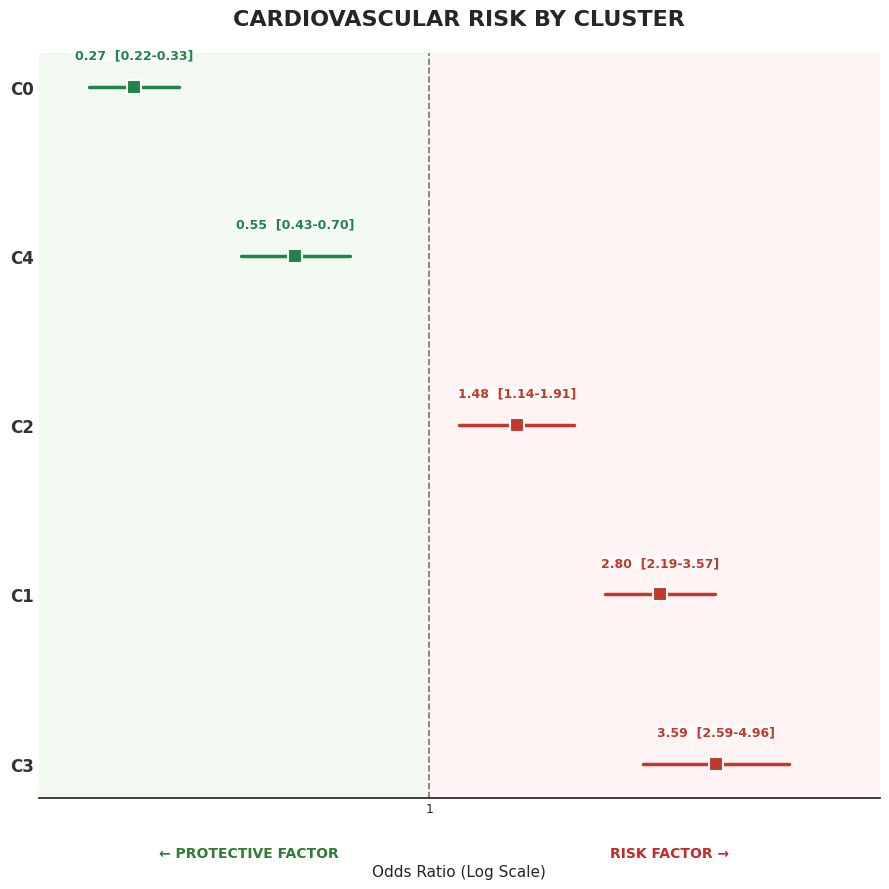

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.stats import chi2_contingency

# =============================================================================
# 1. CÁLCULO ROBUSTO DE ODDS RATIOS
# =============================================================================
print("📊 Calculando Odds Ratios...")
tabla_riesgos = []
unique_clusters = sorted(np.unique(cluster_labels))

for cl in unique_clusters:
    # Tablas de contingencia
    in_cluster = (cluster_labels == cl)
    sick = (df_master['RCV_Alto'].values == 1)

    a = np.sum(in_cluster & sick)      # Expuestos Enfermos
    b = np.sum(in_cluster & ~sick)     # Expuestos Sanos
    c = np.sum(~in_cluster & sick)     # No Expuestos Enfermos
    d = np.sum(~in_cluster & ~sick)    # No Expuestos Sanos

    # --- CORRECCIÓN DE HALDANE-ANSCOMBE ---
    # Si alguna celda es 0, sumamos 0.5 a todas para evitar divisiones por cero o log(0)
    if (a==0 or b==0 or c==0 or d==0):
        a += 0.5; b += 0.5; c += 0.5; d += 0.5

    # Cálculo OR
    if b * c == 0:
        or_val = np.nan # Evitar crash si sigue siendo 0 (raro con corrección)
    else:
        or_val = (a * d) / (b * c)

    # Cálculo Intervalo Confianza (95%)
    try:
        # Error estándar del log-odds
        se = np.sqrt(1/a + 1/b + 1/c + 1/d)
        lower = np.exp(np.log(or_val) - 1.96 * se)
        upper = np.exp(np.log(or_val) + 1.96 * se)
    except:
        lower, upper = np.nan, np.nan

    # Valor P
    try: _, p_val, _, _ = chi2_contingency([[a, b], [c, d]])
    except: p_val = 1.0

    # Color y Etiqueta
    label = f"C{cl}"
    if pd.isna(or_val): color = "#95A5A6"
    elif p_val > 0.05: color = "#95A5A6" # Gris si no es significativo
    elif or_val > 1: color = "#C0392B"   # Rojo si es riesgo
    else: color = "#1E8449"             # Verde si es protector

    tabla_riesgos.append({
        'Label': label, 'OR': or_val, 'Lower': lower, 'Upper': upper,
        'Color': color
    })

# Crear DataFrame y limpiar infinitos explícitamente
df_plot = pd.DataFrame(tabla_riesgos)
df_plot.replace([np.inf, -np.inf], np.nan, inplace=True) # Convertir inf a NaN
df_plot = df_plot.dropna().sort_values('OR', ascending=False)

# DIAGNÓSTICO: Ver si tenemos datos
print(f"✅ Datos válidos para graficar: {len(df_plot)} clusters.")
if df_plot.empty:
    print("⚠️ ¡ALERTA! El dataframe está vacío. Revisa tus datos de entrada (cluster_labels o RCV_Alto).")
else:
    print(df_plot[['Label', 'OR', 'Lower', 'Upper']])


# =============================================================================
# 2. GRAFICACIÓN (Solo si hay datos)
# =============================================================================
if not df_plot.empty:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

    fig, ax = plt.subplots(figsize=(9, 9))
    y_pos = np.arange(len(df_plot))

    # --- FONDOS ---
    # Ajustamos el límite derecho del fondo rojo dinámicamente
    max_limit = max(10, df_plot['Upper'].max() * 1.5)
    ax.axvspan(0.001, 1, color='#E8F5E9', alpha=0.6) # Verde
    ax.axvspan(1, max_limit*10, color='#FFEBEE', alpha=0.6) # Rojo
    ax.axvline(1, color='#555555', linestyle='--', linewidth=1.2, alpha=0.8)

    # --- DIBUJAR PUNTOS Y LÍNEAS ---
    for i, row in df_plot.iterrows():
        # Usamos iloc para asegurar el índice posicional correcto 0, 1, 2...
        idx_pos = df_plot.index.get_loc(i)
        y = y_pos[idx_pos]

        # Línea de intervalo
        ax.plot([row['Lower'], row['Upper']], [y, y], color=row['Color'],
                linewidth=2.5, solid_capstyle='round', zorder=2)

        # Punto central
        ax.plot(row['OR'], y, 's', color=row['Color'], markersize=10,
                markeredgecolor='white', markeredgewidth=1.5, zorder=3)

        # Etiqueta de texto sobre el punto
        label_text = f"{row['OR']:.2f}  [{row['Lower']:.2f}-{row['Upper']:.2f}]"
        ax.text(row['OR'], y + 0.15, label_text,
                ha='center', va='bottom',
                fontsize=9, fontweight='bold', color=row['Color'],
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.2))

    # --- EJES Y ESCALAS ---
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_plot['Label'], fontsize=12, fontweight='bold', color='#333')

    ax.set_xlabel("Odds Ratio (Log Scale)", fontsize=11, labelpad=35)
    ax.set_title("CARDIOVASCULAR RISK BY CLUSTER", fontsize=16, fontweight='bold', pad=20)

    ax.set_xscale('log')

    # Límites dinámicos seguros
    x_min = max(0.05, df_plot['Lower'].min() * 0.8)
    x_max = df_plot['Upper'].max() * 1.5
    ax.set_xlim(x_min, x_max)

    # Formateador del eje X
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: "{:.1f}".format(x) if x < 1 else "{:.0f}".format(x)))

    # Flechas informativas
    ax.text(0.25, -0.08, "← PROTECTIVE FACTOR", transform=ax.transAxes, ha='center', color='#2E7D32', fontweight='bold', fontsize=10)
    ax.text(0.75, -0.08, "RISK FACTOR →", transform=ax.transAxes, ha='center', color='#C62828', fontweight='bold', fontsize=10)

    sns.despine(left=True, top=True, right=True)
    ax.tick_params(axis='y', length=0)
    ax.grid(axis='x', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

📊 Generando tabla de resultados...

--- RESUMEN DE RIESGO POR CLUSTER ---
 cluster     OR  CI_low  CI_high  p_value  significant_p<0.05 interpretation
       3 3.5864  2.5948   4.9567   0.0000                True    Higher risk
       1 2.7991  2.1916   3.5750   0.0000                True    Higher risk
       2 1.4767  1.1430   1.9079   0.0034                True    Higher risk
       4 0.5507  0.4320   0.7020   0.0000                True     Lower risk
       0 0.2686  0.2200   0.3279   0.0000                True     Lower risk


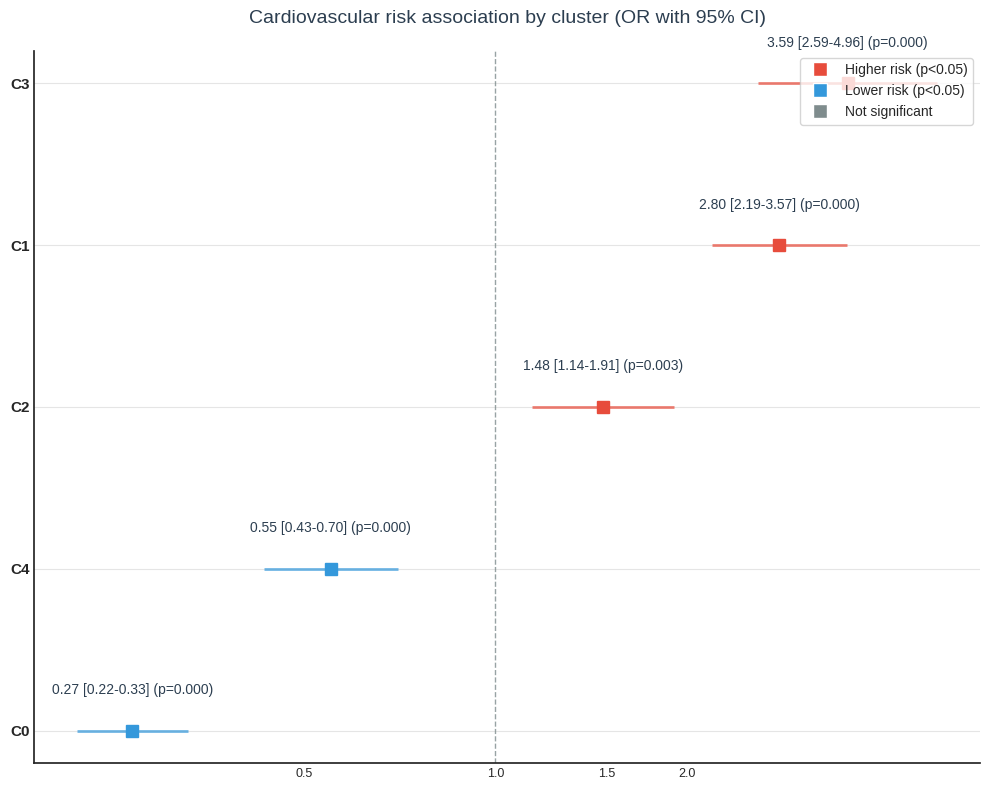

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.stats import chi2_contingency
from matplotlib.lines import Line2D

# =============================================================================
# 1. CÁLCULO DE DATOS (TABLA Y MÉTRICAS)
# =============================================================================
print("📊 Generando tabla de resultados...")
tabla_completa = []
unique_clusters = sorted(np.unique(cluster_labels))

for cl in unique_clusters:
    in_cluster = (cluster_labels == cl)
    sick = (df_master['RCV_Alto'].values == 1)

    a = np.sum(in_cluster & sick)      # Expuestos Enfermos
    b = np.sum(in_cluster & ~sick)     # Expuestos Sanos
    c = np.sum(~in_cluster & sick)     # No Expuestos Enfermos
    d = np.sum(~in_cluster & ~sick)    # No Expuestos Sanos

    # Corrección de Haldane-Anscombe
    if (a==0 or b==0 or c==0 or d==0):
        a+=0.5; b+=0.5; c+=0.5; d+=0.5

    or_val = (a * d) / (b * c)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    lower = np.exp(np.log(or_val) - 1.96 * se)
    upper = np.exp(np.log(or_val) + 1.96 * se)

    try: _, p_val, _, _ = chi2_contingency([[a, b], [c, d]])
    except: p_val = 1.0

    # Interpretación para la tabla
    significant = p_val < 0.05
    if not significant: interpretation = "Not significant"
    elif or_val > 1: interpretation = "Higher risk"
    else: interpretation = "Lower risk"

    tabla_completa.append({
        'cluster': cl,
        'OR': or_val,
        'CI_low': lower,
        'CI_high': upper,
        'p_value': p_val,
        'significant_p<0.05': significant,
        'interpretation': interpretation
    })

df_results = pd.DataFrame(tabla_completa).sort_values('OR', ascending=False)

# Mostrar la tabla como en la captura
print("\n--- RESUMEN DE RIESGO POR CLUSTER ---")
print(df_results.to_string(index=False))

# =============================================================================
# 2. GRAFICACIÓN ESTILO FOREST PLOT (NUEVO ESTILO)
# =============================================================================
plt.style.use('seaborn-v0_8-white') # Estilo limpio
fig, ax = plt.subplots(figsize=(10, 8))

# Invertimos el orden para que el OR más alto esté arriba en el eje Y
df_plot = df_results.iloc[::-1].reset_index(drop=True)
y_pos = np.arange(len(df_plot))

# Configuración de colores según la captura
COLOR_HIGH = "#E74C3C" # Rojo
COLOR_LOW = "#3498DB"  # Azul
COLOR_NS = "#7F8C8D"   # Gris (Not Significant)

# Línea vertical de referencia (OR = 1)
ax.axvline(1, color='#7F8C8D', linestyle='--', linewidth=1, alpha=0.8, zorder=1)

# Dibujar cada fila
for i, row in df_plot.iterrows():
    # Determinar color
    if not row['significant_p<0.05']:
        color_row = COLOR_NS
    else:
        color_row = COLOR_HIGH if row['OR'] > 1 else COLOR_LOW

    # Línea de Intervalo
    ax.hlines(y=i, xmin=row['CI_low'], xmax=row['CI_high'],
              color=color_row, linewidth=2, alpha=0.7, zorder=2)

    # Marcador cuadrado (Square)
    ax.plot(row['OR'], i, 's', color=color_row, markersize=8, zorder=3)

    # Texto de etiqueta: OR [Low-High] (p=value)
    txt = f"{row['OR']:.2f} [{row['CI_low']:.2f}-{row['CI_high']:.2f}] (p={row['p_value']:.3f})"
    ax.text(row['OR'], i + 0.25, txt, va='center', ha='center',
            fontsize=10, color="#2C3E50", fontweight='medium')

# --- ESTÉTICA DE EJES ---
ax.set_yticks(y_pos)
ax.set_yticklabels([f"C{int(c)}" for c in df_plot['cluster']], fontsize=11, fontweight='bold')

# Escala logarítmica para OR
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([0.5, 1, 1.5, 2])

# Títulos
ax.set_title("Cardiovascular risk association by cluster (OR with 95% CI)",
             fontsize=14, pad=20, loc='center', color="#2C3E50")

# Líneas de cuadrícula horizontales muy tenues
ax.yaxis.grid(True, linestyle='-', alpha=0.2, color='gray')
ax.xaxis.grid(False)

# Leyenda personalizada (Top Right)
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Higher risk (p<0.05)', markerfacecolor=COLOR_HIGH, markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Lower risk (p<0.05)', markerfacecolor=COLOR_LOW, markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Not significant', markerfacecolor=COLOR_NS, markersize=10)
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=10)

# Limpiar bordes
sns.despine(left=False, bottom=False)
plt.tight_layout()

plt.show()

In [23]:
!pip install imodels
import warnings
# Ignorar advertencias de deprecación
warnings.filterwarnings("ignore", category=DeprecationWarning)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.5/274.5 kB 14.3 MB/s eta 0:00:00


In [40]:
import warnings
# Ignorar advertencias de deprecación
warnings.filterwarnings("ignore", category=DeprecationWarning)
# =============================================================================
# CÓDIGO MAESTRO: PERFILADO BAYESIANO DUAL (POSITIVO/NEGATIVO) + AUC
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
import warnings
from collections import defaultdict
from imodels import SkopeRulesClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

# --- 1. CONFIGURACIÓN ---
warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style("whitegrid")

# --- 2. PREPARACIÓN DE DATOS (CRÍTICO: ALINEACIÓN) ---
if 'X_df' in locals():
    # .reset_index(drop=True) es VITAL para que coincida con los arrays de numpy
    X_analysis = X_df.copy().reset_index(drop=True)
    print("✅ X_analysis cargado y re-indexado correctamente.")
elif 'X_raw' in locals():
    X_analysis = X_raw.copy().reset_index(drop=True)
    print("✅ X_analysis cargado y re-indexado correctamente.")
else:
    raise ValueError("⚠️ ERROR: Carga tus datos en 'X_df' o 'X_raw' primero.")

# Aseguramos que los labels sean un array limpio sin índices de pandas
y_true = np.array(cluster_labels)
unique_cls = np.unique(y_true)

✅ X_analysis cargado y re-indexado correctamente.


🚀 1. Entrenando XGBoost (1000 trees)...
🧠 Calculando SHAP Values...
✅ SHAP Values Listos.
🌳 1. Minando reglas candidatas (One-vs-Rest)...
✅ Matriz Candidata: 141 reglas generadas.

  CLUSTER 0
   🧹 Reglas: 12 (de 45 orig).
   📊 TP=304 FN=287 | TN=1448 FP=55
   📈 Sens=51.4% Spec=96.3% AUC=0.962
----------------------------------------------------------------------------------
Variable             Condicion     N(Clus)  P(C|X)  Epsilon   Score
----------------------------------------------------------------------------------
DFBDP_Frituras de p.. > 1.88            220    0.47     9.18    0.83
DFCT_Refinados sin .. > 15.75            25    0.46     2.95    0.79
DFSOP_Sopa de pasta.. > 5.50             24    0.46     2.87    0.78
DFSOP_Sopa de pasta.. > 1.75             90    0.45     5.33    0.74
DFSOP_Sopas instant.. > 0.12            124    0.43     5.55    0.65
DFCT_Frituras (ries.. > 3.50             75    0.42     4.12    0.62
DFB_Agua simple (pr.. > 214.38            6    0.40     1

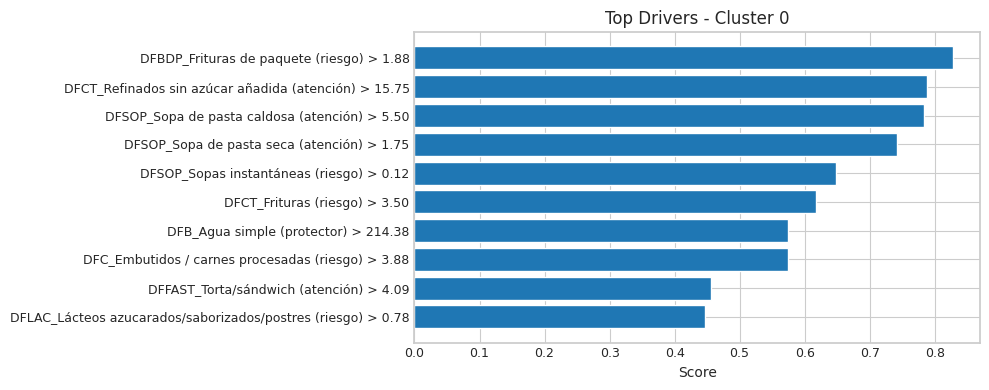

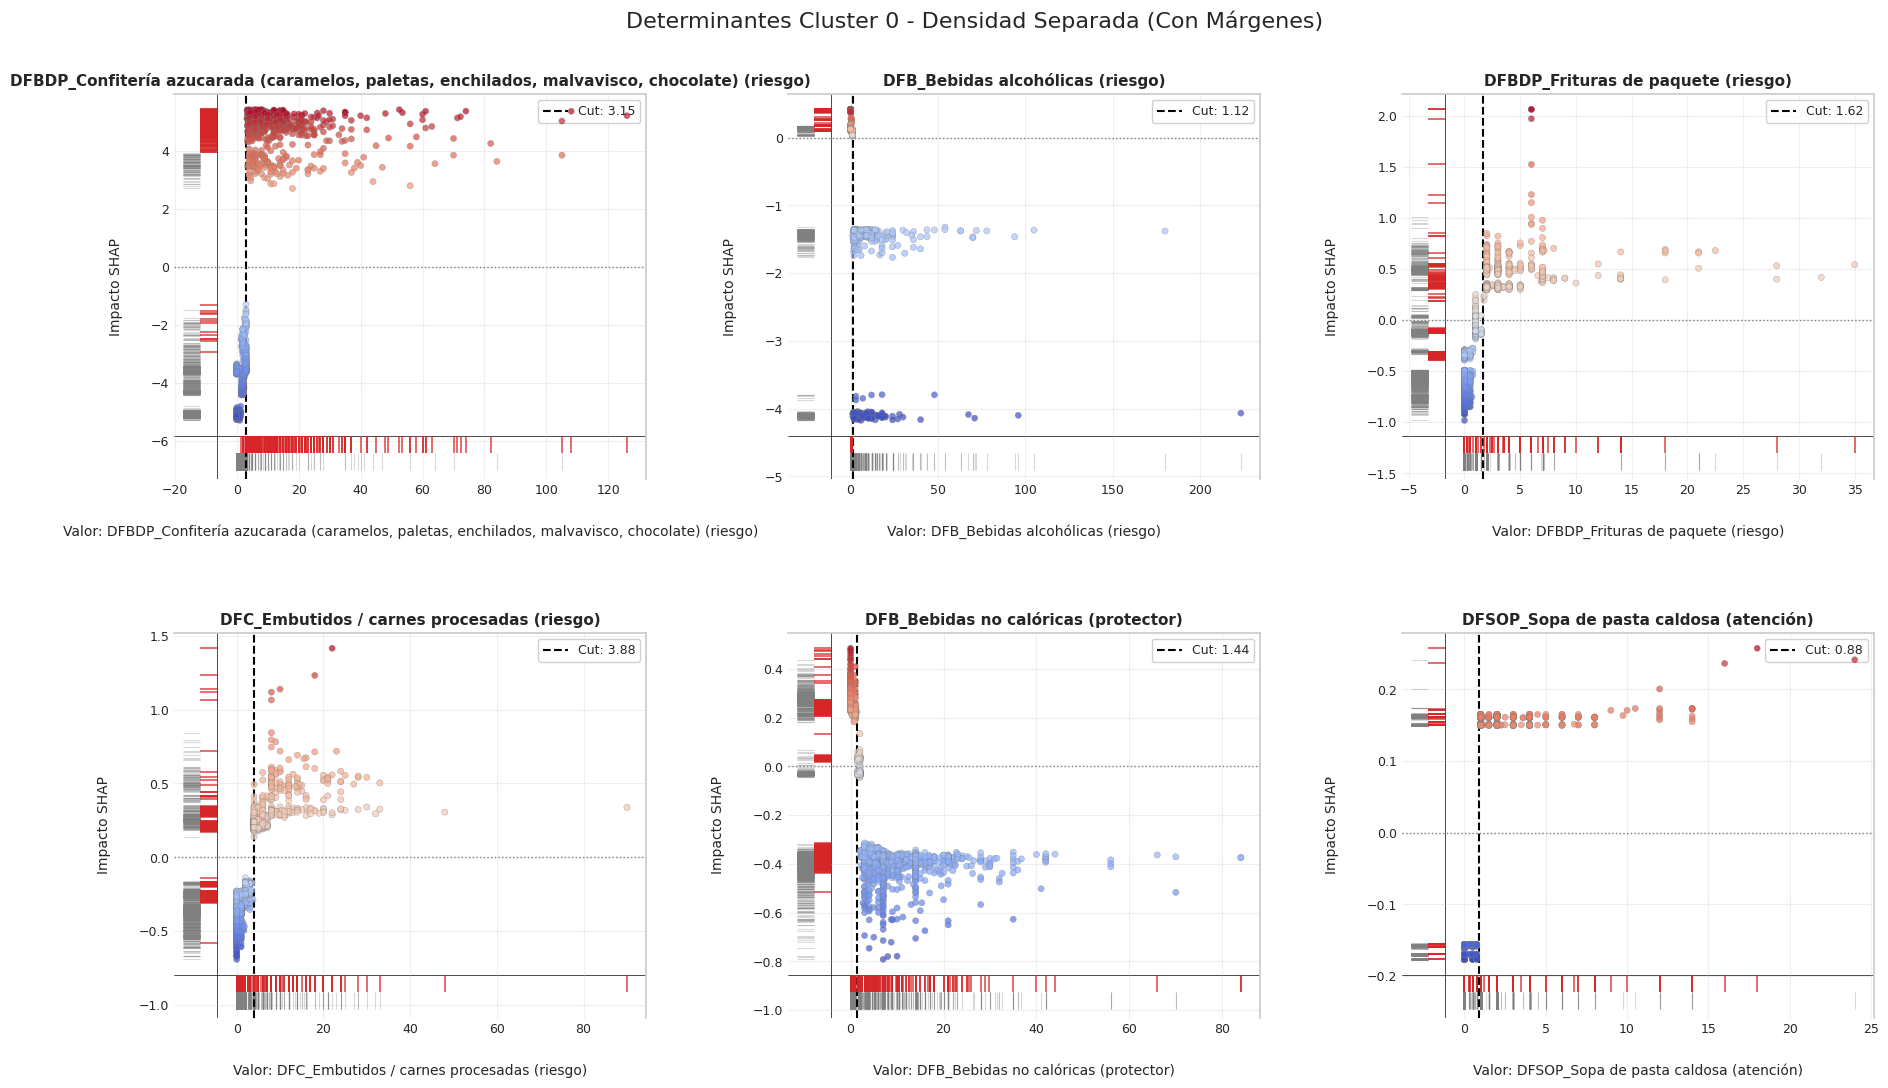


  CLUSTER 1
   🧹 Reglas: 12 (de 45 orig).
   📊 TP=285 FN=227 | TN=1540 FP=42
   📈 Sens=55.7% Spec=97.3% AUC=0.894
----------------------------------------------------------------------------------
Variable             Condicion     N(Clus)  P(C|X)  Epsilon   Score
----------------------------------------------------------------------------------
DFV_Crucíferas (pro.. > 16.50             9    0.45     2.14    0.94
DFBDP_Frituras de p.. <= 0.68           509    0.39    12.50    0.70
DFBDP_Confitería az.. <= 3.15           512    0.36    10.40    0.57
DFMISC_Mayonesa/cre.. > 13.50             7    0.32     0.80    0.43
DFB_Azúcar añadida .. > 3.25            302    0.33     5.93    0.41
DFFAST_Rápida UPF: .. > 0.12            117    0.17    -4.92   -0.49
DFC_Embutidos / car.. > 3.88             75    0.15    -5.18   -0.63
DFB_Bebidas azucara.. > 25.75            34    0.14    -3.76   -0.66


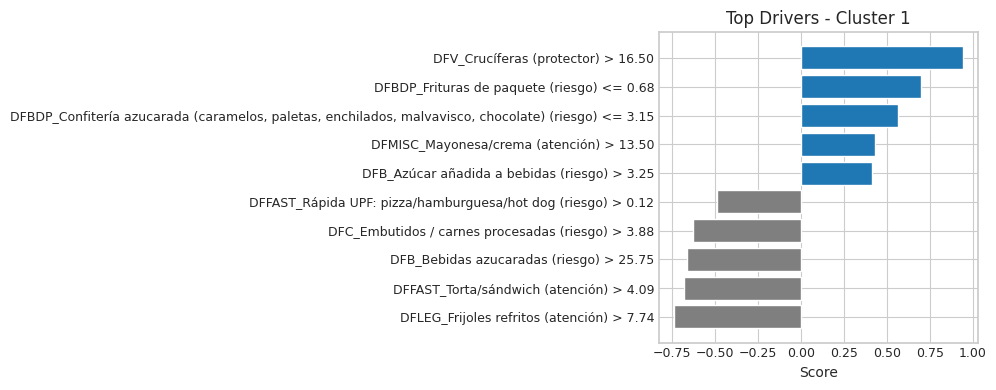

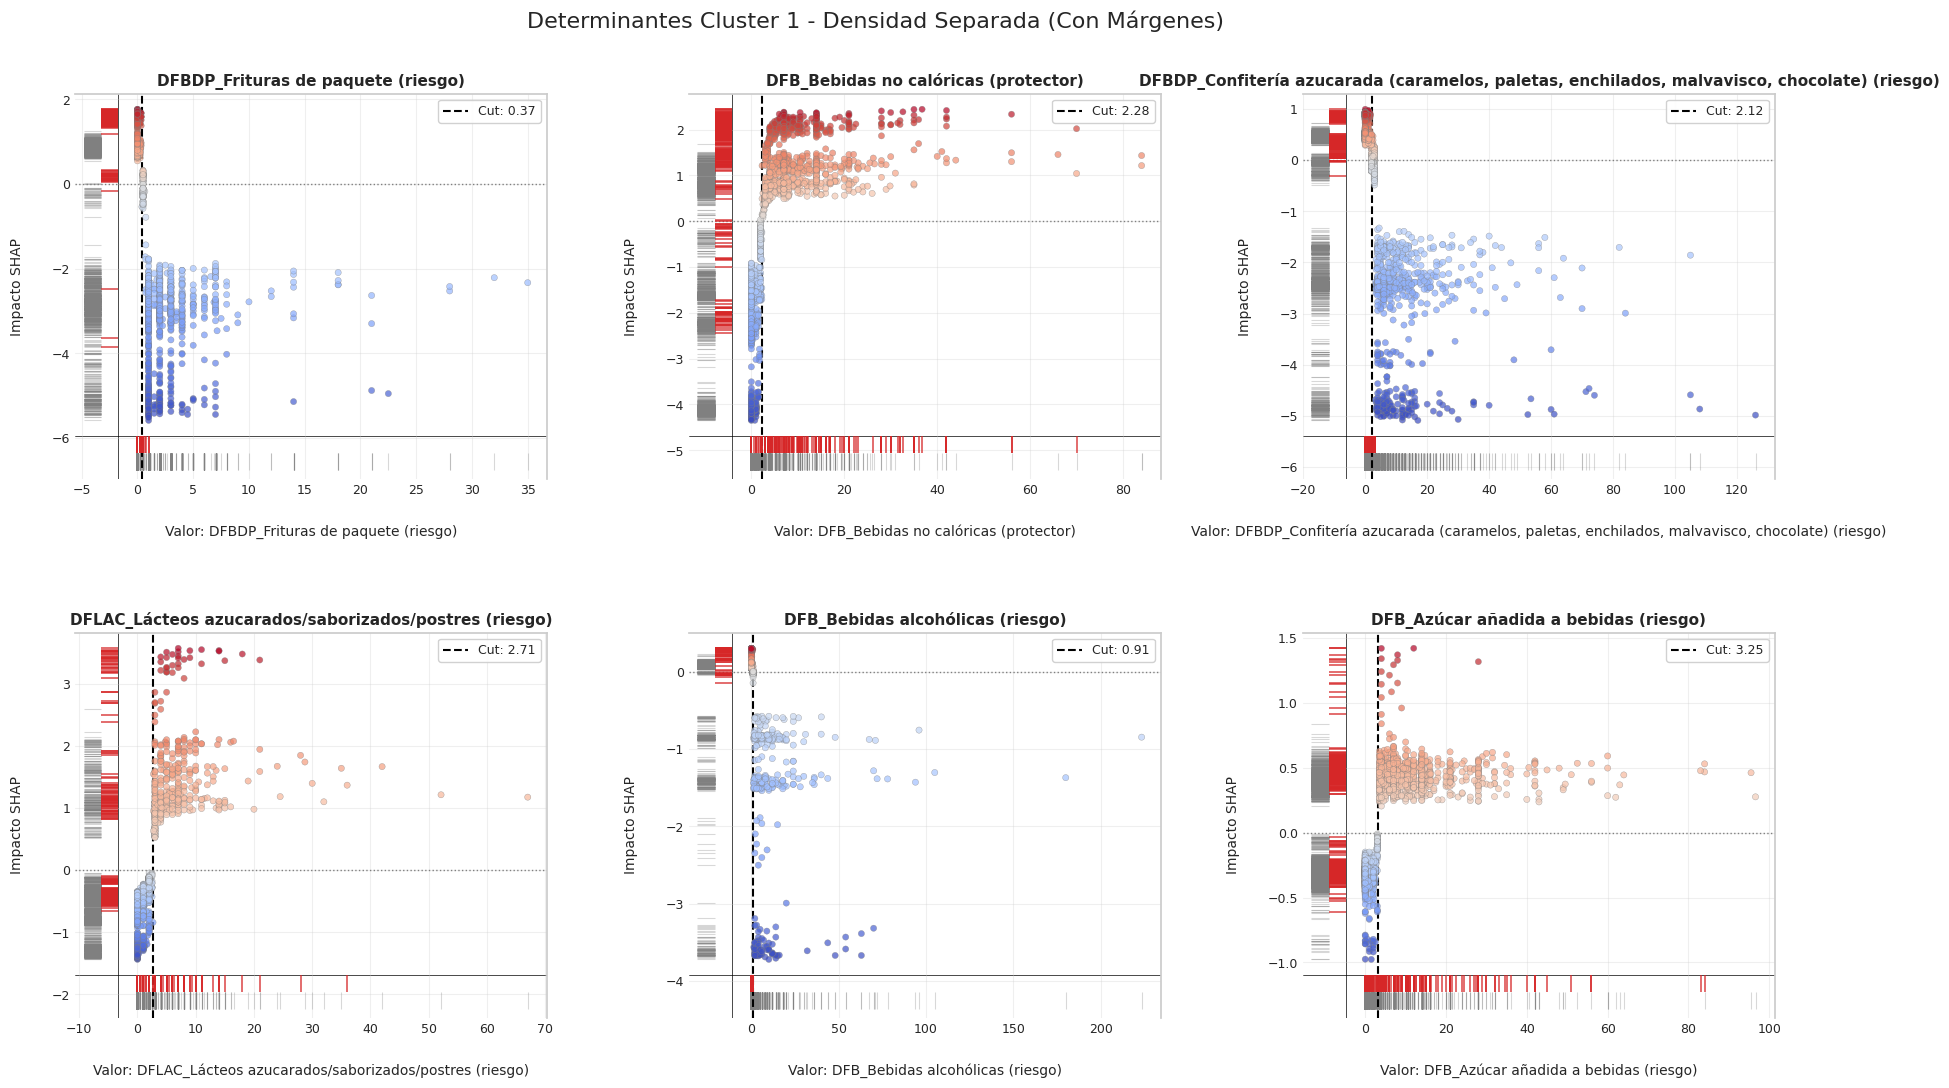


  CLUSTER 2
   🧹 Reglas: 15 (de 45 orig).
   📊 TP=4 FN=344 | TN=1746 FP=0
   📈 Sens=1.1% Spec=100.0% AUC=0.869
----------------------------------------------------------------------------------
Variable             Condicion     N(Clus)  P(C|X)  Epsilon   Score
----------------------------------------------------------------------------------
DFB_Agua simple (pr.. > 214.38            5    0.33     1.74    1.00
DFLEG_Frijoles refr.. > 18.24             7    0.30     1.78    0.85
DFBDP_Frituras de p.. <= 0.68           347    0.27     9.89    0.61
DFBDP_Confitería az.. <= 3.15           348    0.25     8.16    0.50
DFFAST_Torta/sándwi.. > 4.09             21    0.10    -2.43   -0.52
DFMISC_Mayonesa/cre.. > 1.75             50    0.10    -3.72   -0.54
DFFAST_Rápida UPF: .. > 0.12             73    0.10    -4.52   -0.54
DFBDP_Postres azuca.. > 1.00             87    0.10    -4.94   -0.55


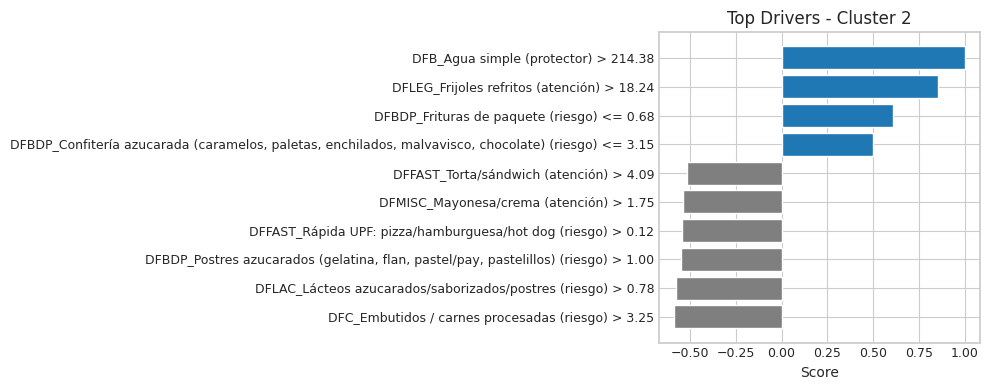

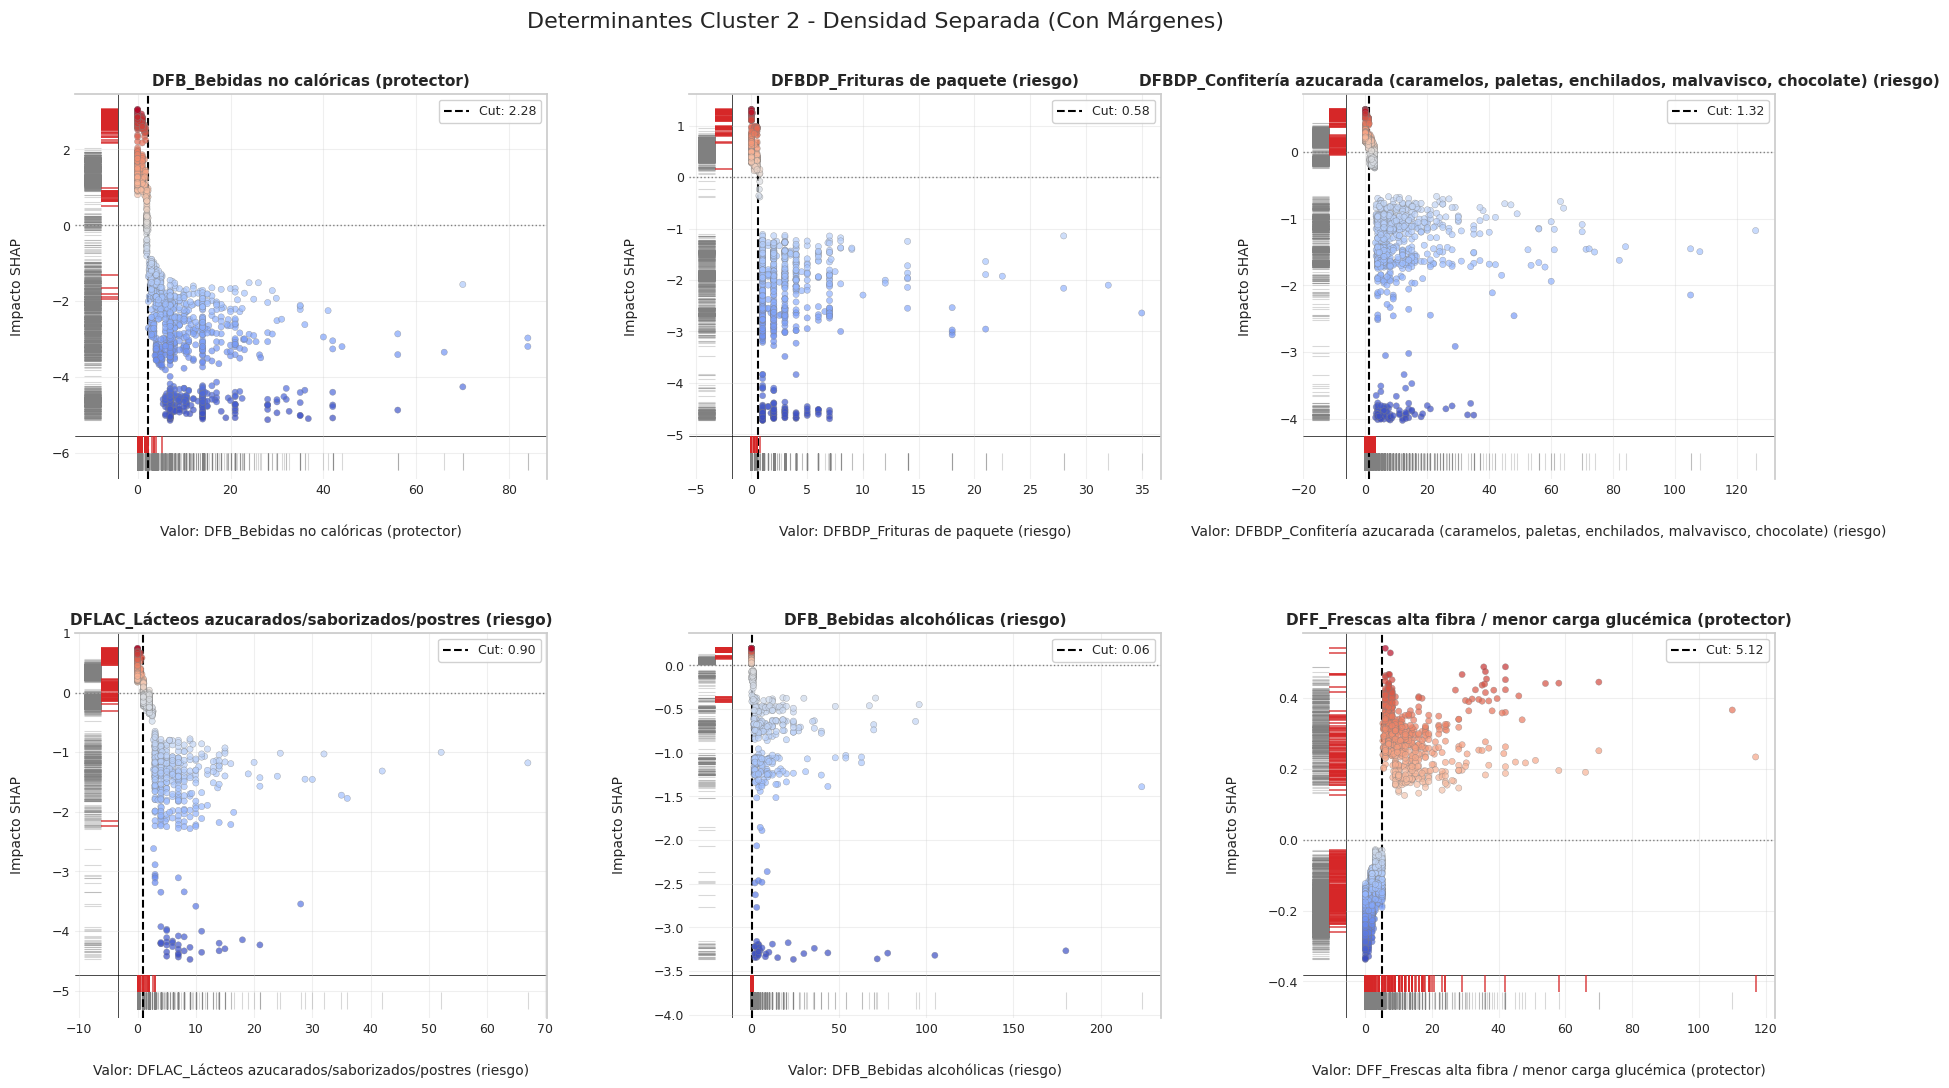


  CLUSTER 3
   🧹 Reglas: 10 (de 45 orig).
   📊 TP=327 FN=0 | TN=1721 FP=46
   📈 Sens=100.0% Spec=97.4% AUC=1.000
----------------------------------------------------------------------------------
Variable             Condicion     N(Clus)  P(C|X)  Epsilon   Score
----------------------------------------------------------------------------------
DFB_Bebidas alcohól.. > 1.12            327    1.00    42.04    7.48
DFLEG_Frijoles refr.. > 14.75            11    0.38     3.31    1.22
DFC_Huevo cocido (a.. > 9.50              9    0.33     2.54    1.04
DFBDP_Confitería az.. > 34.50            14    0.30     2.77    0.89
DFB_Bebidas azucara.. > 25.75            72    0.30     6.06    0.83
DFMISC_Mayonesa/cre.. > 13.50             6    0.27     1.51    0.79
DFC_Carne roja (rie.. > 3.38            129    0.26     6.40    0.64
DFV_Verduras almido.. > 10.00            11    0.24     1.63    0.61


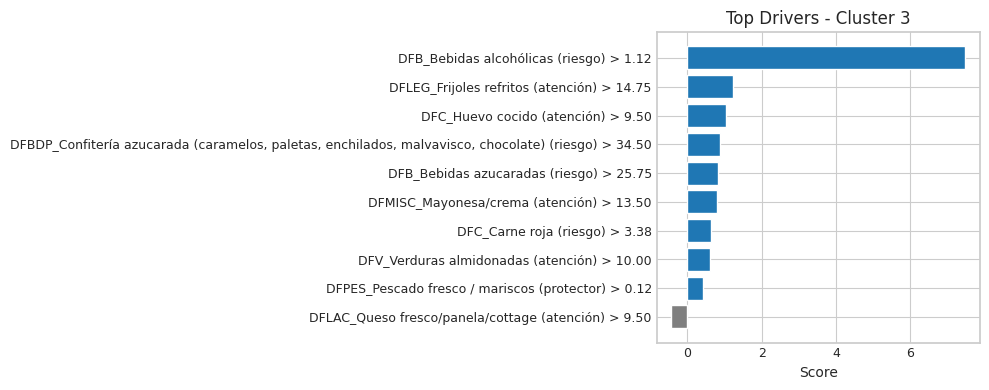

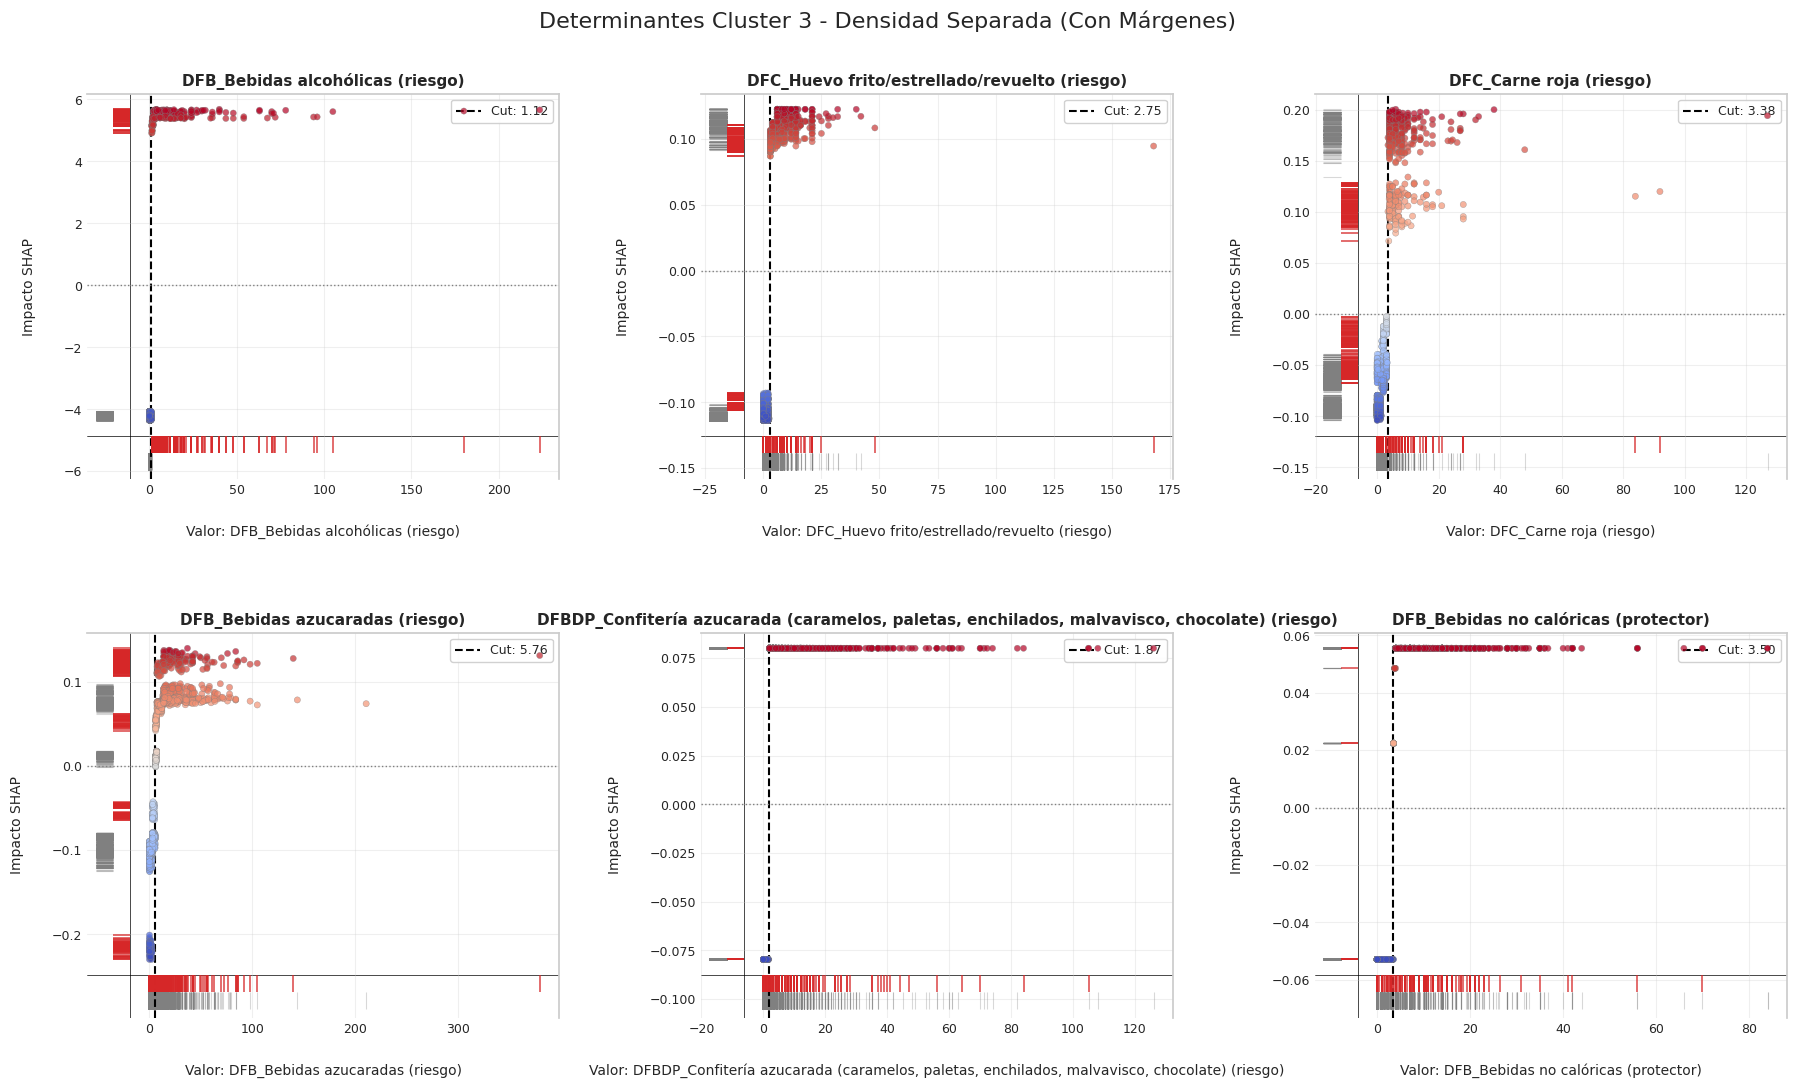


  CLUSTER 4
   🧹 Reglas: 14 (de 45 orig).
   📊 TP=255 FN=61 | TN=1714 FP=64
   📈 Sens=80.7% Spec=96.4% AUC=0.963
----------------------------------------------------------------------------------
Variable             Condicion     N(Clus)  P(C|X)  Epsilon   Score
----------------------------------------------------------------------------------
DFBDP_Frituras de p.. > 1.00            316    0.40    19.42    1.31
DFBDP_Confitería az.. <= 3.15           316    0.22     7.71    0.48
DFCT_Azucarados/dul.. > 13.50            14    0.22     1.45    0.48
DFV_Verduras almido.. > 10.00             9    0.20     0.92    0.41
DFLAC_Queso fresco/.. > 9.50             14    0.19     1.03    0.35
DFF_Frescas alta fi.. > 9.38             60    0.19     2.07    0.30
DFB_Bebidas alcohól.. <= 0.60           312    0.18     3.57    0.22
DFV_Verduras no alm.. > 16.58            69    0.12    -1.88   -0.23


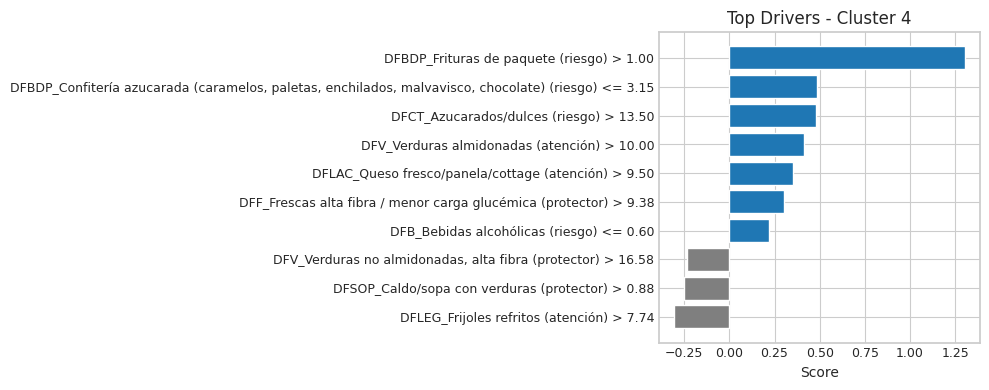

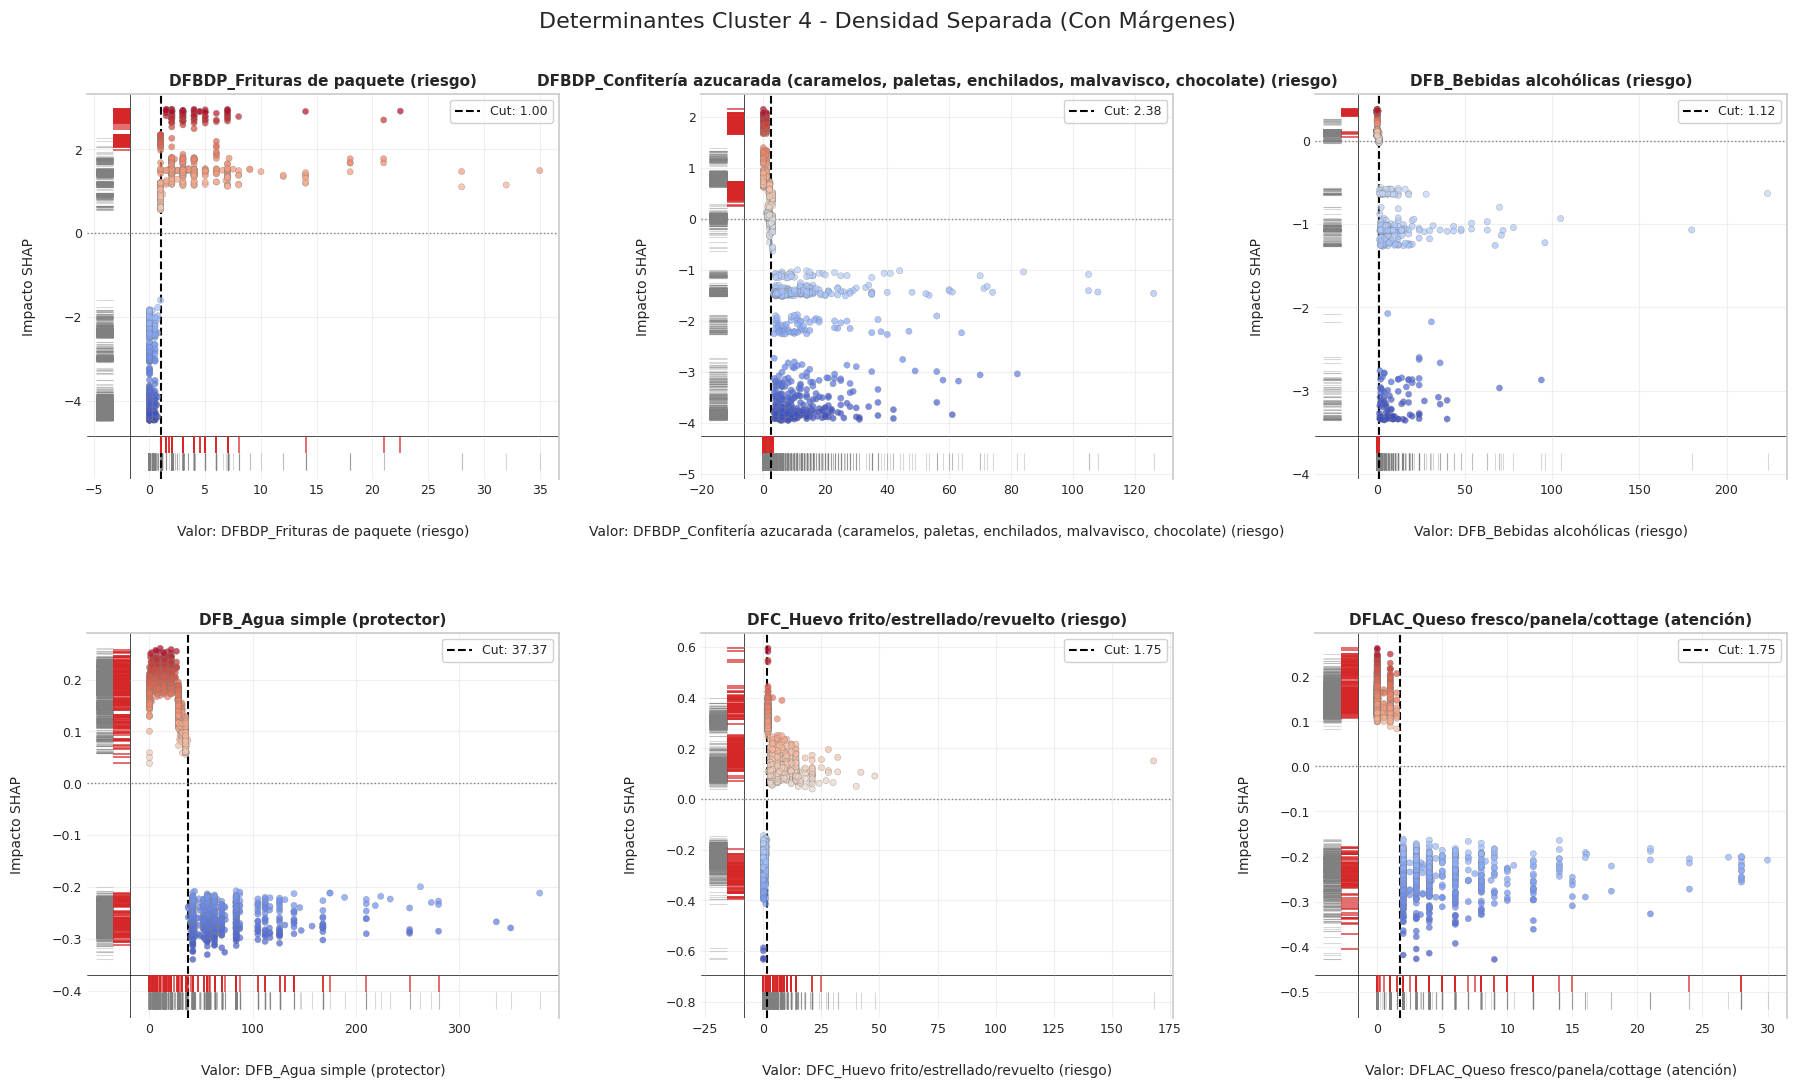


████████████████████████████████████████████████████████████
█ EVALUACIÓN GLOBAL
████████████████████████████████████████████████████████████

Global Accuracy: 0.7770
              precision    recall  f1-score   support

           0      0.998     0.736     0.847       591
           1      0.812     0.852     0.831       512
           2      0.971     0.382     0.548       348
           3      0.696     1.000     0.821       327
           4      0.576     0.937     0.713       316

    accuracy                          0.777      2094
   macro avg      0.810     0.781     0.752      2094
weighted avg      0.837     0.777     0.769      2094



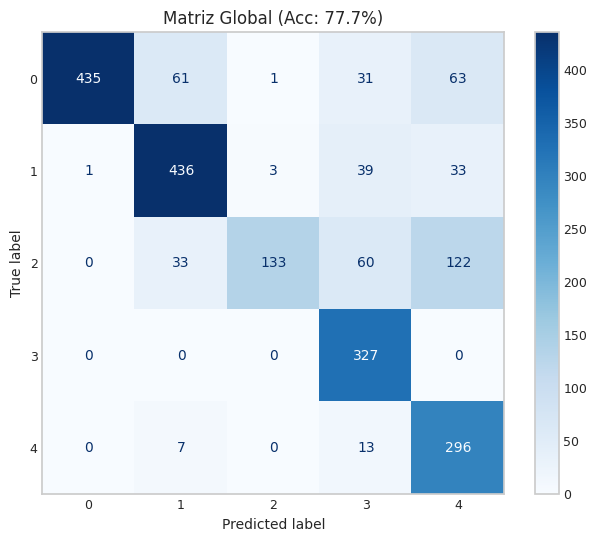


✅ Archivos Excel generados correctamente.


In [42]:
# =============================================================================
# 0. INSTALACIÓN DE DEPENDENCIAS (Solo si es necesario en Colab)
# =============================================================================
# !pip install shap xgboost

from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xgboost as xgb
import shap
import warnings
import seaborn as sns
import math
from scipy.special import expit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, classification_report)

# --- CONFIGURACIÓN VISUAL Y DE PANDAS ---
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style("whitegrid")
# Ajustamos los parámetros globales de la figura para dar más margen
plt.rcParams.update({
    'figure.max_open_warning': 0,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.autolayout': False # Desactivamos autolayout para controlar manualmente
})

# =============================================================================
# 1. PREPARACIÓN DE DATOS Y MODELO BASE (XGBOOST -> SHAP)
# =============================================================================
# Verificación de seguridad de datos
if 'X_df' in locals():
    X_analysis = X_df.copy().reset_index(drop=True)
elif 'X_raw' in locals():
    X_analysis = X_raw.copy().reset_index(drop=True)
elif 'df_master' in locals():
    X_analysis = df_master.select_dtypes(include=[np.number]).copy().reset_index(drop=True)

    y_true = np.concatenate([np.zeros(300), np.ones(100)]).astype(int)

if 'cluster_labels' in locals():
    y_true = np.array(cluster_labels)

print(f"🚀 1. Entrenando XGBoost (1000 trees)...")
model_xgb = xgb.XGBClassifier(n_estimators=1000, max_depth=10, learning_rate=0.1,
                              colsample_bynode=0.7, n_jobs=-1, random_state=42)
model_xgb.fit(X_analysis, y_true)

print("🧠 Calculando SHAP Values...")
explainer = shap.TreeExplainer(model_xgb)
shap_values_full = explainer.shap_values(X_analysis)
print("✅ SHAP Values Listos.")

# =============================================================================
# 2. CLASE BAYES CLASSIFIER
# =============================================================================
class BayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha: float = 1.0, min_cases: int = 5, epsilon: float = 1e-9):
        self.alpha = alpha
        self.min_cases = min_cases
        self.epsilon = epsilon

    def fit(self, X, y):
        X_df = pd.DataFrame(X).reset_index(drop=True)
        y_arr = np.array(y).astype(int)
        self.classes_ = np.array([0, 1])
        Xv = (X_df > 0).astype(int)

        mask = (y_arr == 1); Nc = int(mask.sum()); N = int(len(y_arr))
        prior = Nc / N if N else 0.0
        self.prior_ = prior
        p_safe = np.clip(prior, self.epsilon, 1.0 - self.epsilon)
        self.intercept_ = np.log(p_safe / (1.0 - p_safe))

        rows = []; weights = {}

        for col in Xv.columns:
            vals = Xv[col].values
            n_x = int(vals.sum())
            n_cx = int(vals[mask].sum())
            n_x_nc = n_x - n_cx

            p_c = (n_cx + self.alpha) / (Nc + 2*self.alpha)
            p_nc = (n_x_nc + self.alpha) / ((N - Nc) + 2*self.alpha)

            score = np.log(max(p_c, self.epsilon) / max(p_nc, self.epsilon))
            if n_cx < self.min_cases: score = 0.0

            p_cx_val = n_cx / n_x if n_x > 0 else 0
            denom = np.sqrt(n_x * self.prior_ * (1.0 - self.prior_)) if n_x > 0 else 0
            stat_epsilon = float((n_x * (p_cx_val - self.prior_) / denom) if denom > 0 else 0.0)

            col_str = str(col)
            var_name, cond = (col_str.split("|", 1) if "|" in col_str else (col_str, "Bool"))

            weights[col] = score
            rows.append({
                "Original_Feature": col, "Variable": var_name.strip(), "Condicion": cond.strip(),
                "N_Uni": N, "N_Clust": Nc, "N(CX)": n_cx, "N(X)": n_x,
                "P(C|X)": p_cx_val, "Epsilon": stat_epsilon, "Score": score
            })

        self.feature_table_ = pd.DataFrame(rows).sort_values("Score", ascending=False)
        self.weights_ = pd.Series(weights)
        return self

    def predict_proba(self, X):
        X_df = pd.DataFrame(X)
        common = X_df.columns.intersection(self.weights_.index)
        if len(common) == 0: return np.zeros((len(X), 2))
        log_odds = X_df[common].dot(self.weights_[common]) + self.intercept_
        p1 = expit(log_odds)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X): return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# =============================================================================
# 3. GENERADOR DE REGLAS (LÓGICA SHAP)
# =============================================================================
def generar_reglas_shap_inteligentes(X_raw, y_labels, shap_vals, top_n=30):
    print("🌳 1. Minando reglas candidatas (One-vs-Rest)...")
    unique_clusters = sorted(np.unique(y_labels))
    reglas = {}

    for c_id in unique_clusters:
        if isinstance(shap_vals, list): s_c = shap_vals[c_id]
        elif shap_vals.ndim == 3: s_c = shap_vals[:, :, c_id]
        else: s_c = shap_vals

        impact = np.mean(np.abs(s_c), axis=0)
        top_cols = X_raw.columns[np.argsort(impact)[::-1][:top_n]]
        y_bin = (y_labels == c_id).astype(int)

        for col in top_cols:
            x_col = X_raw[col].values
            s_col = s_c[:, X_raw.columns.get_loc(col)]

            tree = DecisionTreeClassifier(max_depth=1, random_state=42)
            tree.fit(x_col.reshape(-1, 1), y_bin)

            if len(tree.tree_.threshold) == 0: continue
            th = tree.tree_.threshold[0]
            if th == -2: continue

            mask_right = (x_col > th)
            if mask_right.sum() == 0: continue

            mean_shap_right = np.mean(s_col[mask_right])
            if mean_shap_right > 0: reglas[f"{col}|> {th:.2f}"] = (x_col > th).astype(int)
            else: reglas[f"{col}|<= {th:.2f}"] = (x_col <= th).astype(int)

    df_res = pd.DataFrame(reglas, index=X_raw.index)
    print(f"✅ Matriz Candidata: {df_res.shape[1]} reglas generadas.")
    return df_res

# =============================================================================
# 4. OPTIMIZACIÓN Y MÉTRICAS
# =============================================================================
def optimizar_cluster_bayes(X_rules, y_bin, k_range):
    clf_full = BayesClassifier(); clf_full.fit(X_rules, y_bin)
    if clf_full.feature_table_.empty: return None, [], {}, pd.DataFrame()

    ft = clf_full.feature_table_.copy()
    ft['AbsScore'] = ft['Score'].abs()
    ft = ft.sort_values('AbsScore', ascending=False).drop_duplicates('Variable')
    ranked_feats = ft['Original_Feature'].tolist()

    best_auc = -1; best_feats = ranked_feats[:k_range[0]]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    n_pos = y_bin.sum()
    if n_pos < 5: best_auc = 0.5; best_feats = ranked_feats[:5]
    else:
        for k in k_range:
            if k > len(ranked_feats): break
            feats = ranked_feats[:k]
            aucs = []
            try:
                for tr, ts in cv.split(X_rules, y_bin):
                    m = BayesClassifier()
                    m.fit(X_rules.iloc[tr][feats], y_bin[tr])
                    p = m.predict_proba(X_rules.iloc[ts][feats])[:, 1]
                    if len(np.unique(y_bin[ts])) > 1: aucs.append(roc_auc_score(y_bin[ts], p))
                    else: aucs.append(0.5)
                if np.mean(aucs) > best_auc: best_auc = np.mean(aucs); best_feats = feats
            except: continue

    final_model = BayesClassifier(); final_model.fit(X_rules[best_feats], y_bin)
    y_pred = final_model.predict(X_rules[best_feats])
    tn, fp, fn, tp = confusion_matrix(y_bin, y_pred).ravel()

    metrics = {
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Sens": tp/(tp+fn) if (tp+fn)>0 else 0, "Spec": tn/(tn+fp) if (tn+fp)>0 else 0,
        "AUC": best_auc, "N_Total_Reglas": len(ranked_feats), "N_Final_Reglas": len(best_feats)
    }
    return final_model, best_feats, metrics, clf_full.feature_table_

# =============================================================================
# 7. FUNCIÓN DEFINITIVA: RUGS DESPLAZADOS CON MARGEN
# =============================================================================
def plot_shap_dependence_stacked_rugs(X, y, shap_values, cluster_id, top_n=6):
    """
    Genera dependence plots con Rugs apilados en carriles separados,
    ajustando los márgenes para que no se encimen con el gráfico.
    """
    # Selección SHAP
    if isinstance(shap_values, list): s_c = shap_values[cluster_id]
    elif shap_values.ndim == 3: s_c = shap_values[:, :, cluster_id]
    else: s_c = shap_values

    # Máscaras
    mask_cluster = (y == cluster_id)
    mask_rest = (y != cluster_id)

    # Ranking
    impact = np.mean(np.abs(s_c), axis=0)
    top_indices = np.argsort(impact)[::-1][:top_n]
    top_cols = X.columns[top_indices]

    cols_grid = 3
    rows_grid = math.ceil(top_n / cols_grid)

    # AJUSTE DE TAMAÑO Y MÁRGENES DE LA FIGURA
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(20, 6 * rows_grid))
    # Ajustamos márgenes para dejar espacio a los rugs (bottom y left)
    fig.subplots_adjust(top=0.92, bottom=0.15, left=0.1, right=0.95, hspace=0.4, wspace=0.3)

    fig.suptitle(f"Determinantes Cluster {cluster_id} - Densidad Separada (Con Márgenes)", fontsize=16, y=0.99)
    axes = axes.flatten()

    for i, col in enumerate(top_cols):
        ax = axes[i]
        x_col = X[col].values
        shap_col = s_c[:, X.columns.get_loc(col)]

        # --- 1. SCATTER PLOT ---
        try:
            divnorm = mcolors.TwoSlopeNorm(vmin=shap_col.min(), vcenter=0., vmax=shap_col.max())
        except ValueError: divnorm = None

        im = ax.scatter(x_col, shap_col, c=shap_col, cmap="coolwarm", norm=divnorm,
                        alpha=0.7, s=20, edgecolor='grey', linewidth=0.3, zorder=10)

        # --- 2. STACKED RUGS CON MARGEN ---
        # Obtenemos límites actuales (del scatter)
        y_min_data, y_max_data = ax.get_ylim()
        x_min_data, x_max_data = ax.get_xlim()

        y_range = y_max_data - y_min_data
        x_range = x_max_data - x_min_data

        # Definimos la altura de los rugs y el espacio que ocupan FUERA del gráfico
        rug_height = y_range * 0.05
        rug_width = x_range * 0.04

        # Expandimos los límites del eje para hacer sitio a los rugs
        ax.set_ylim(y_min_data - 2.5*rug_height, y_max_data)
        ax.set_xlim(x_min_data - 2.5*rug_width, x_max_data)

        # --- RUGS EJE X (Abajo, fuera del área de datos) ---
        # Carril 1 (Gris - Resto): En el fondo
        ax.vlines(x_col[mask_rest], ymin=y_min_data - 2*rug_height, ymax=y_min_data - rug_height,
                  color="grey", alpha=0.3, linewidth=0.8, zorder=1)

        # Carril 2 (Rojo - Cluster): Encima del gris
        ax.vlines(x_col[mask_cluster], ymin=y_min_data - rug_height, ymax=y_min_data,
                  color="#d62728", alpha=0.8, linewidth=1.2, zorder=5)

        # --- RUGS EJE Y (Izquierda, fuera del área de datos) ---
        # Carril 1 (Gris - Resto): A la izquierda del todo
        ax.hlines(shap_col[mask_rest], xmin=x_min_data - 2*rug_width, xmax=x_min_data - rug_width,
                  color="grey", alpha=0.3, linewidth=0.8, zorder=1)

        # Carril 2 (Rojo - Cluster): A la derecha del gris
        ax.hlines(shap_col[mask_cluster], xmin=x_min_data - rug_width, xmax=x_min_data,
                  color="#d62728", alpha=0.8, linewidth=1.2, zorder=5)

        # --- 3. CORTE POR CAMBIO DE SIGNO ---
        y_sign = (shap_col > 0).astype(int)
        if len(np.unique(y_sign)) > 1:
            tree = DecisionTreeClassifier(max_depth=1, random_state=42)
            tree.fit(x_col.reshape(-1, 1), y_sign)

            if len(tree.tree_.threshold) > 0:
                th = tree.tree_.threshold[0]
                if th != -2:
                    mask_left = x_col <= th
                    if mask_left.sum() > 0:
                        max_left = x_col[mask_left].max()
                        min_right = x_col[x_col > th].min() if (x_col > th).sum() > 0 else th
                        if (min_right - max_left) > 1.0:
                             smart_th = min_right - (min_right * 0.01)
                             label_th = f"{smart_th:.2f}"
                        else:
                            smart_th = th
                            label_th = f"{smart_th:.2f}"

                    ax.axvline(smart_th, color="black", linestyle="--", linewidth=1.5, label=f"Cut: {label_th}")
                    ax.legend(loc='upper right', fontsize=9, frameon=True, framealpha=0.9)

        ax.axhline(0, color="gray", linestyle=":", linewidth=1)
        ax.set_title(f"{col}", fontsize=11, fontweight='bold')

        # Etiquetas de los ejes desplazadas para no pisar los rugs
        ax.set_ylabel("Impacto SHAP", labelpad=20)
        ax.set_xlabel(f"Valor: {col}", labelpad=20)

        ax.grid(True, linestyle='-', alpha=0.3)

        # Ocultar las espinas (bordes) donde están los rugs para que se vea más limpio
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)

        # Añadir una línea de eje manual donde empieza el área de datos real
        ax.axhline(y_min_data, color='black', linewidth=0.5, zorder=0)
        ax.axvline(x_min_data, color='black', linewidth=0.5, zorder=0)

    for j in range(i + 1, len(axes)): axes[j].axis('off')
    # No usamos tight_layout() porque ya ajustamos manualmente con subplots_adjust
    plt.show()

# =============================================================================
# 5. EJECUCIÓN MAESTRA
# =============================================================================
df_reglas = generar_reglas_shap_inteligentes(X_analysis, y_true, shap_values_full, top_n=30)
unique_clusters = sorted(np.unique(y_true))
modelos_finales = {}
dfs_full = {}
dfs_best = {}
lista_metricas = []

for c_id in unique_clusters:
    print(f"\n" + "="*80 + f"\n  CLUSTER {c_id}\n" + "="*80)
    y_bin = (y_true == c_id).astype(int)
    model, feats, mets, df_full_stats = optimizar_cluster_bayes(df_reglas, y_bin, range(10, 21))

    modelos_finales[c_id] = (model, feats)
    dfs_full[c_id] = df_full_stats
    dfs_best[c_id] = model.feature_table_

    mets_excel = mets.copy(); mets_excel['Cluster'] = c_id; lista_metricas.append(mets_excel)

    print(f"   🧹 Reglas: {mets['N_Final_Reglas']} (de {mets['N_Total_Reglas']} orig).")
    print(f"   📊 TP={mets['TP']} FN={mets['FN']} | TN={mets['TN']} FP={mets['FP']}")
    print(f"   📈 Sens={mets['Sens']:.1%} Spec={mets['Spec']:.1%} AUC={mets['AUC']:.3f}")

    print("-" * 82)
    print(f"{'Variable':<20} {'Condicion':<12} {'N(Clus)':>8} {'P(C|X)':>7} {'Epsilon':>8} {'Score':>7}")
    print("-" * 82)
    for _, r in model.feature_table_.head(8).iterrows():
        v_name = (r['Variable'][:19] + '..') if len(r['Variable']) > 19 else r['Variable']
        print(f"{v_name:<20} {r['Condicion']:<12} {int(r['N(CX)']):>8} {r['P(C|X)']:>7.2f} {r['Epsilon']:>8.2f} {r['Score']:>7.2f}")

    # --- DRIVERS BARCHART ---
    plt.figure(figsize=(10, 4))
    if not model.feature_table_.empty:
        top_plot = model.feature_table_.head(10).sort_values('Score', ascending=True)
        colors = ['#1f77b4' if x > 0 else '#7f7f7f' for x in top_plot['Score']]
        plt.barh([f"{r['Variable']} {r['Condicion']}" for _, r in top_plot.iterrows()], top_plot['Score'], color=colors)
        plt.title(f"Top Drivers - Cluster {c_id}")
        plt.xlabel("Score"); plt.tight_layout(); plt.show()

    # --- PANELES CON STACKED RUGS Y MARGEN ---
    plot_shap_dependence_stacked_rugs(X_analysis, y_true, shap_values_full, cluster_id=c_id, top_n=6)

# C. EVALUACIÓN GLOBAL
print("\n" + "█"*60 + "\n█ EVALUACIÓN GLOBAL\n" + "█"*60)
probs_matrix = np.zeros((len(df_reglas), len(unique_clusters)))
for idx, c_id in enumerate(unique_clusters):
    model, feats = modelos_finales[c_id]
    if len(feats) > 0: probs_matrix[:, idx] = model.predict_proba(df_reglas[feats])[:, 1]

y_pred_global = [unique_clusters[i] for i in np.argmax(probs_matrix, axis=1)]
acc_global = accuracy_score(y_true, y_pred_global)
print(f"\nGlobal Accuracy: {acc_global:.4f}")
print(classification_report(y_true, y_pred_global, digits=3))

cm = confusion_matrix(y_true, y_pred_global, labels=unique_clusters)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_clusters)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title(f"Matriz Global (Acc: {acc_global:.1%})"); plt.grid(False); plt.show()

# =============================================================================
# 6. EXCEL EXPORT
# =============================================================================
try:
    with pd.ExcelWriter("1_Todas_Reglas_Gemelas.xlsx") as writer:
        for c, df in dfs_full.items(): df.to_excel(writer, sheet_name=f"C{c}_Full", index=False)
    with pd.ExcelWriter("2_Reglas_Modelo_Optimizado.xlsx") as writer:
        for c, df in dfs_best.items(): df.to_excel(writer, sheet_name=f"C{c}_Best", index=False)
    with pd.ExcelWriter("3_Metricas_Performance.xlsx") as writer:
        pd.DataFrame(lista_metricas).to_excel(writer, sheet_name="Metricas", index=False)
        pd.DataFrame(classification_report(y_true, y_pred_global, output_dict=True)).T.to_excel(writer, sheet_name="Global")
        pd.DataFrame(cm, index=[f"True_{c}" for c in unique_clusters], columns=[f"Pred_{c}" for c in unique_clusters]).to_excel(writer, sheet_name="Confusion")
    print("\n✅ Archivos Excel generados correctamente.")
except Exception as e: print(f"⚠️ Error guardando Excel: {e}")

In [26]:
asdadasd

NameError: name 'asdadasd' is not defined

[I 2026-01-11 23:20:14,537] A new study created in memory with name: no-name-a1decd11-fe80-4878-b115-95f4634bf17c


✅ Datos listos: X=(2094, 73) | y clases=5 ([np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)])
🚀 Optuna: tuning RandomForest | trials=20 | CV=5


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-01-11 23:20:31,956] Trial 0 finished with value: 0.9969503467197465 and parameters: {'n_estimators': 325, 'max_depth': 17, 'min_samples_split': 22, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.9969503467197465.
[I 2026-01-11 23:21:11,621] Trial 1 finished with value: 0.9969196243067483 and parameters: {'n_estimators': 1154, 'max_depth': 30, 'min_samples_split': 27, 'min_samples_leaf': 13, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.9969503467197465.
[I 2026-01-11 23:21:27,999] Trial 2 finished with value: 0.9984960677076915 and parameters: {'n_estimators': 351, 'max_depth': 27, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True}. Best is trial 2 with value: 0.9984960677076915.
[I 2026-01-11 23:21:46,716] Trial 3 finished with value: 0.9972534374570999 and parameters: {'n_estimators': 822, 'max_depth': 27, 'min_samples_split': 26, 'min_samples_leaf': 7, 'max_f

[I 2026-01-11 23:28:23,601] A new study created in memory with name: no-name-bcca4035-72f4-4410-a2dd-86eb92e62461
[I 2026-01-11 23:28:23,664] Trial 0 finished with value: 0.958029209161 and parameters: {'alpha': 4.845545582708953, 'min_cases': 15, 'top_k': 2}. Best is trial 0 with value: 0.958029209161.


✅ SHAP listo. shape = (2094, 73, 5)

✅ df_reglas global: (2094, 50) (unión de reglas por cluster desde TOP_SHAP=10)

  CLUSTER 0 (NB desde TOP SHAP)


[I 2026-01-11 23:28:23,731] Trial 1 finished with value: 0.9608326123512076 and parameters: {'alpha': 0.00658219964189432, 'min_cases': 29, 'top_k': 7}. Best is trial 1 with value: 0.9608326123512076.
[I 2026-01-11 23:28:23,818] Trial 2 finished with value: 0.958029209161 and parameters: {'alpha': 0.025189557271574174, 'min_cases': 3, 'top_k': 2}. Best is trial 1 with value: 0.9608326123512076.


   ⚙️  TUNING: Alpha=0.0066, Min=29, TopK=7
   📊 DETALLE: TP=591 FN=0 | TN=1003 FP=500
   📈 METRICAS: Sens=100.00% Spec=66.73% AUC=0.961
   🧩 Candidatas=10 | Final=7 | SCORE_MIN=0.05
------------------------------------------------------------------------------------------------------------------------
Original_Feature                    Variable             Condicion     N_Uni N_Clust   N(CX)    N(X)   P(C|X)  Epsilon    Score
------------------------------------------------------------------------------------------------------------------------
C0::DFBDP_Confitería azucarada (ca  C0::DFBDP_Confiterí  > 3.15         2094     591     578     686     0.84    32.61     2.61
C0::DFBDP_Frituras de paquete (rie  C0::DFBDP_Frituras   > 1.88         2094     591     220     464     0.47     9.18     0.83
C0::DFSOP_Sopas instantáneas (ries  C0::DFSOP_Sopas ins  > 0.12         2094     591     124     289     0.43     5.55     0.65
C0::DFCT_Frituras (riesgo)|> 3.50   C0::DFCT_Frituras (  > 3.50

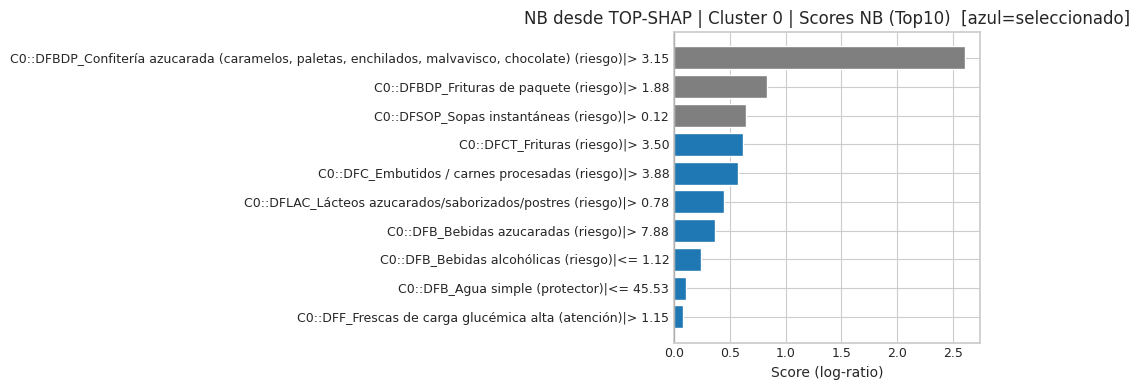

   🔎 Dependence A: TOP-SHAP (RF)


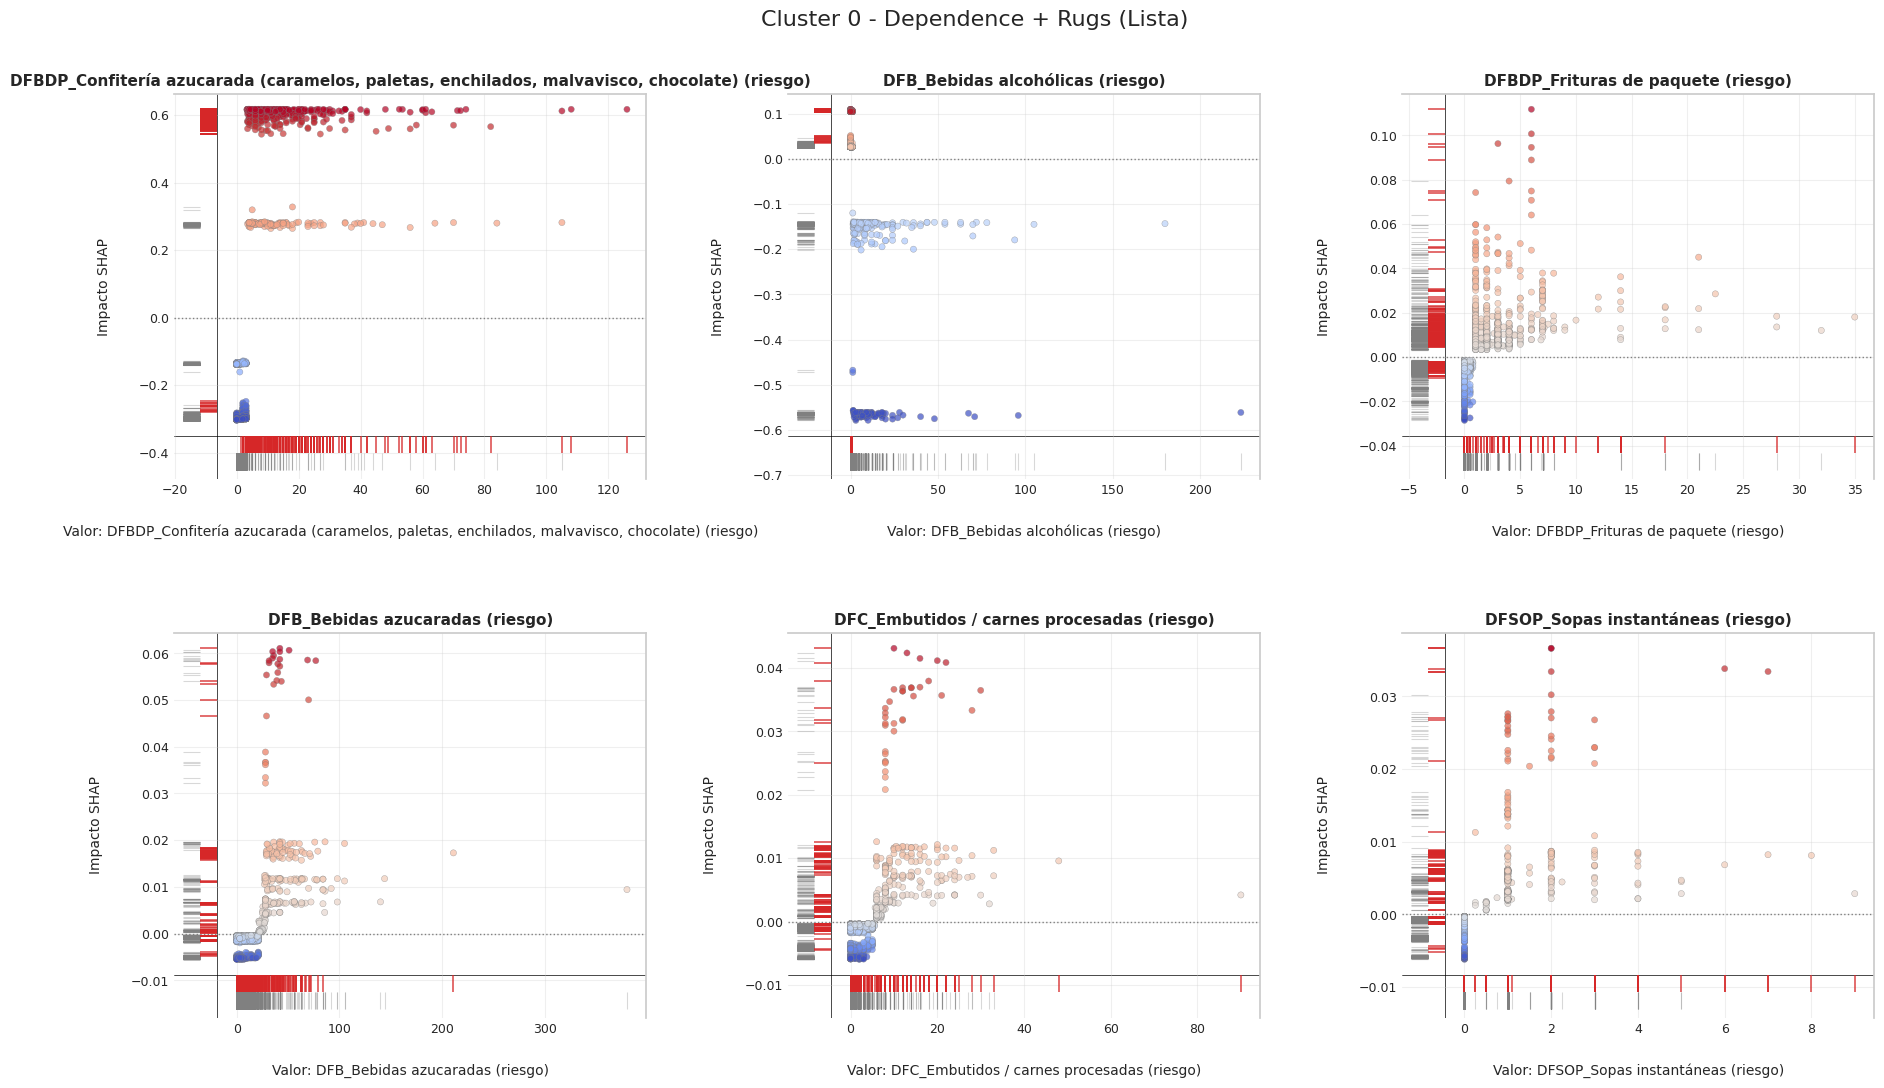

   🔎 Dependence B: NB-selected (mapeado a features originales)


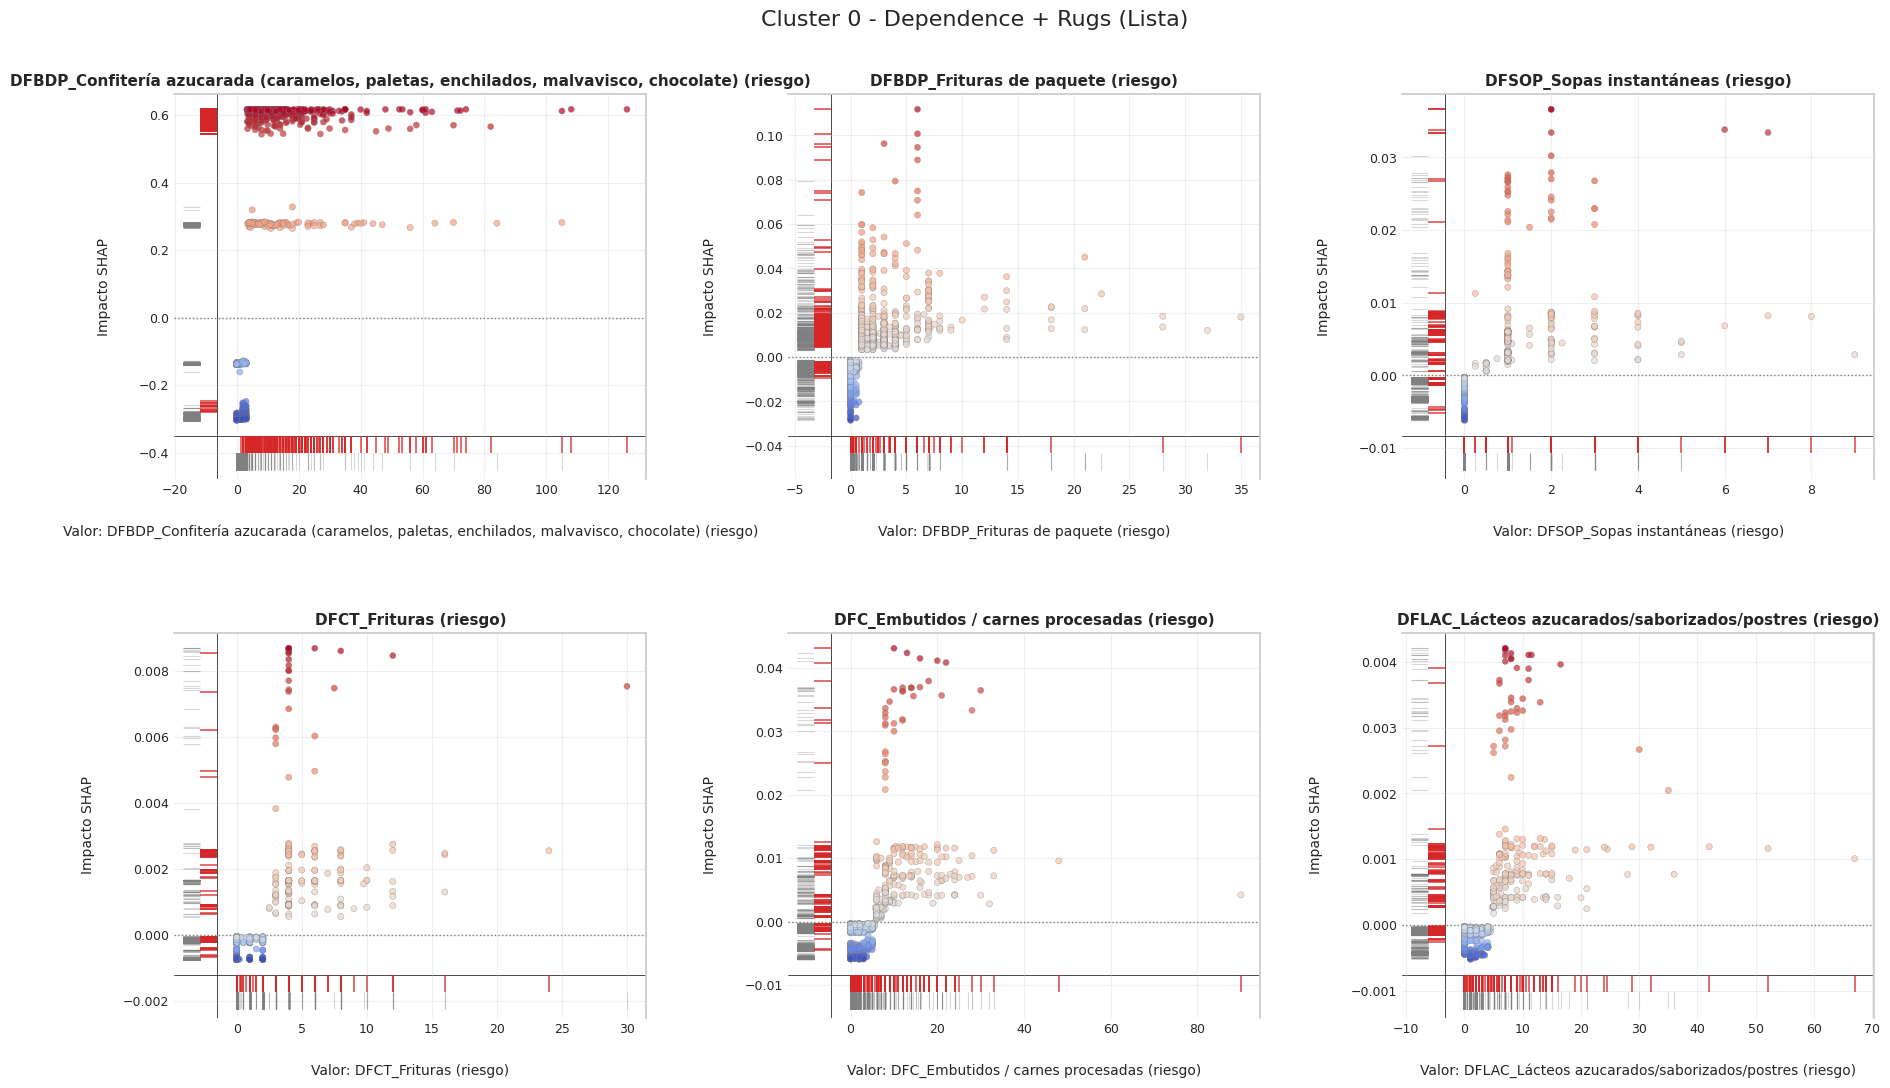

[I 2026-01-11 23:28:28,812] A new study created in memory with name: no-name-c5ef8205-4bc5-448b-b8f4-1858be6f0f65
[I 2026-01-11 23:28:28,903] Trial 0 finished with value: 0.9282467470247766 and parameters: {'alpha': 0.021245888613775594, 'min_cases': 7, 'top_k': 7}. Best is trial 0 with value: 0.9282467470247766.
[I 2026-01-11 23:28:28,967] Trial 1 finished with value: 0.7305070158444172 and parameters: {'alpha': 0.03368216316126805, 'min_cases': 1, 'top_k': 1}. Best is trial 0 with value: 0.9282467470247766.



  CLUSTER 1 (NB desde TOP SHAP)


[I 2026-01-11 23:28:29,058] Trial 2 finished with value: 0.931500262723444 and parameters: {'alpha': 0.020088150895278836, 'min_cases': 22, 'top_k': 8}. Best is trial 2 with value: 0.931500262723444.


   ⚙️  TUNING: Alpha=0.0201, Min=22, TopK=8
   📊 DETALLE: TP=505 FN=7 | TN=588 FP=994
   📈 METRICAS: Sens=98.63% Spec=37.17% AUC=0.932
   🧩 Candidatas=10 | Final=8 | SCORE_MIN=0.05
------------------------------------------------------------------------------------------------------------------------
Original_Feature                    Variable             Condicion     N_Uni N_Clust   N(CX)    N(X)   P(C|X)  Epsilon    Score
------------------------------------------------------------------------------------------------------------------------
C1::DFB_Bebidas no calóricas (prot  C1::DFB_Bebidas no   > 2.88         2094     512     448    1103     0.41    12.49     0.75
C1::DFBDP_Frituras de paquete (rie  C1::DFBDP_Frituras   <= 0.68        2094     512     509    1292     0.39    12.50     0.70
C1::DFBDP_Confitería azucarada (ca  C1::DFBDP_Confiterí  <= 3.15        2094     512     512    1408     0.36    10.40     0.57
C1::DFB_Azúcar añadida a bebidas (  C1::DFB_Azúcar añad  > 3.25  

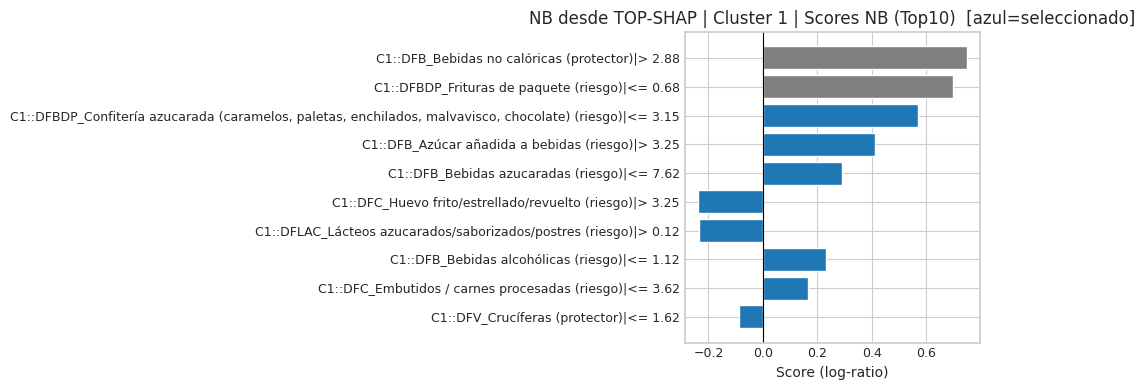

   🔎 Dependence A: TOP-SHAP (RF)


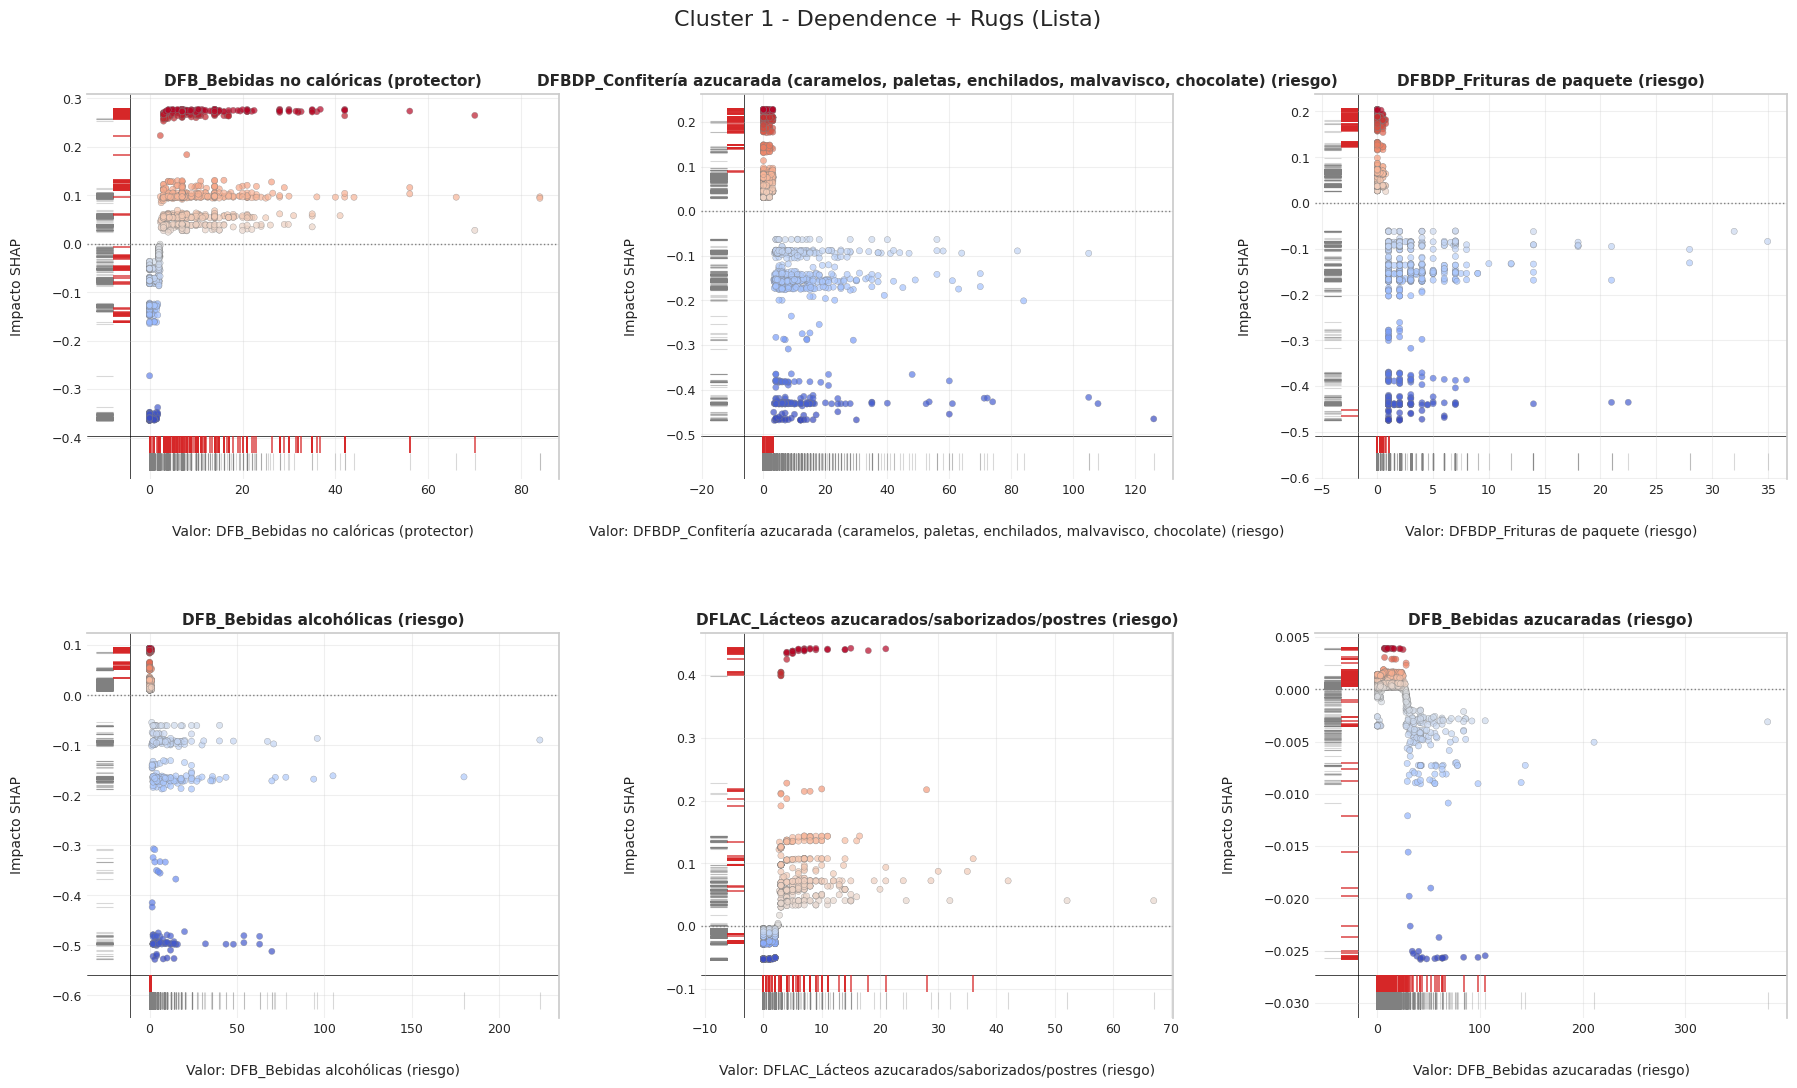

   🔎 Dependence B: NB-selected (mapeado a features originales)


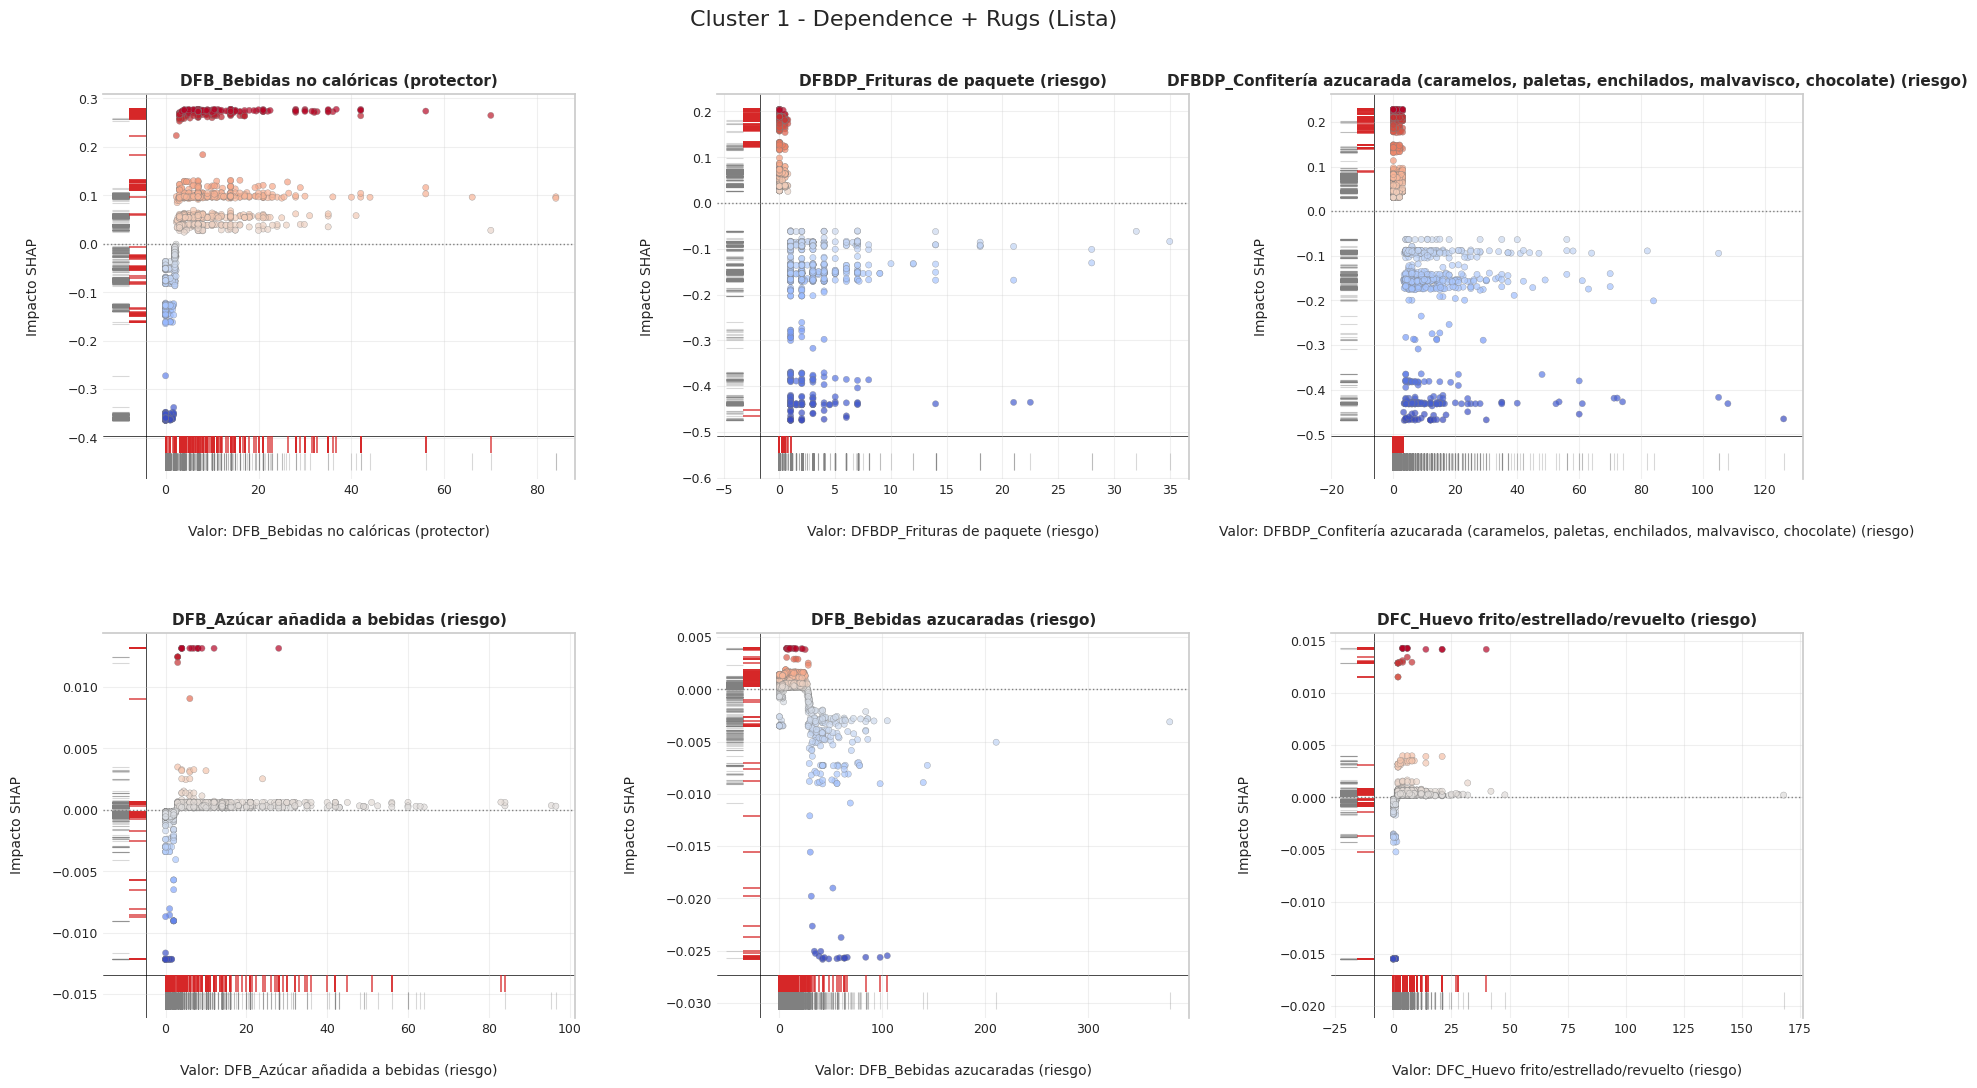

[I 2026-01-11 23:28:35,944] A new study created in memory with name: no-name-3398ba0b-0c21-4c0d-87ae-5000930a5777
[I 2026-01-11 23:28:36,032] Trial 0 finished with value: 0.9255930164267028 and parameters: {'alpha': 0.02710671804034493, 'min_cases': 29, 'top_k': 2}. Best is trial 0 with value: 0.9255930164267028.
[I 2026-01-11 23:28:36,102] Trial 1 finished with value: 0.9449390687382465 and parameters: {'alpha': 0.0023910872272048175, 'min_cases': 1, 'top_k': 3}. Best is trial 1 with value: 0.9449390687382465.



  CLUSTER 2 (NB desde TOP SHAP)


[I 2026-01-11 23:28:36,181] Trial 2 finished with value: 0.8109903480515165 and parameters: {'alpha': 0.07652503706684519, 'min_cases': 9, 'top_k': 1}. Best is trial 1 with value: 0.9449390687382465.


   ⚙️  TUNING: Alpha=0.0024, Min=1, TopK=3
   📊 DETALLE: TP=343 FN=5 | TN=1639 FP=107
   📈 METRICAS: Sens=98.56% Spec=93.87% AUC=0.945
   🧩 Candidatas=10 | Final=3 | SCORE_MIN=0.05
------------------------------------------------------------------------------------------------------------------------
Original_Feature                    Variable             Condicion     N_Uni N_Clust   N(CX)    N(X)   P(C|X)  Epsilon    Score
------------------------------------------------------------------------------------------------------------------------
C2::DFB_Bebidas no calóricas (prot  C2::DFB_Bebidas no   <= 2.28        2094     348     343     978     0.35    15.50     1.00
C2::DFBDP_Frituras de paquete (rie  C2::DFBDP_Frituras   <= 0.87        2094     348     348    1298     0.27     9.86     0.61
C2::DFBDP_Confitería azucarada (ca  C2::DFBDP_Confiterí  <= 3.15        2094     348     348    1408     0.25     8.16     0.50


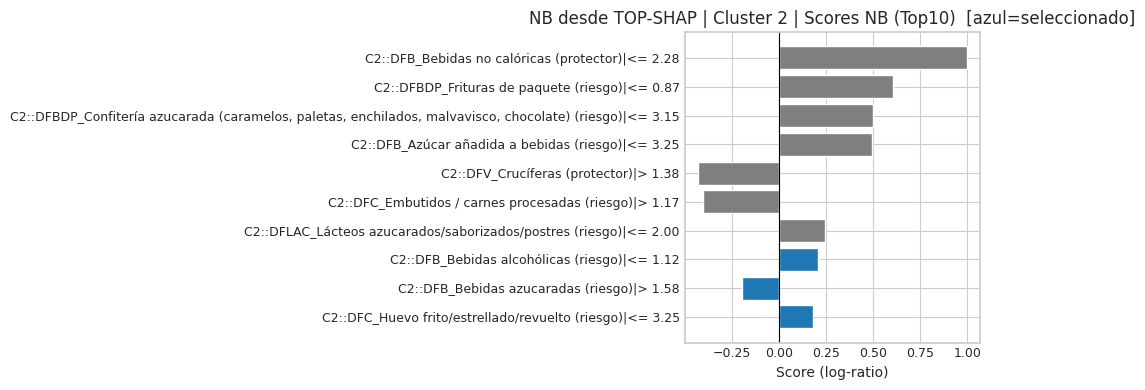

   🔎 Dependence A: TOP-SHAP (RF)


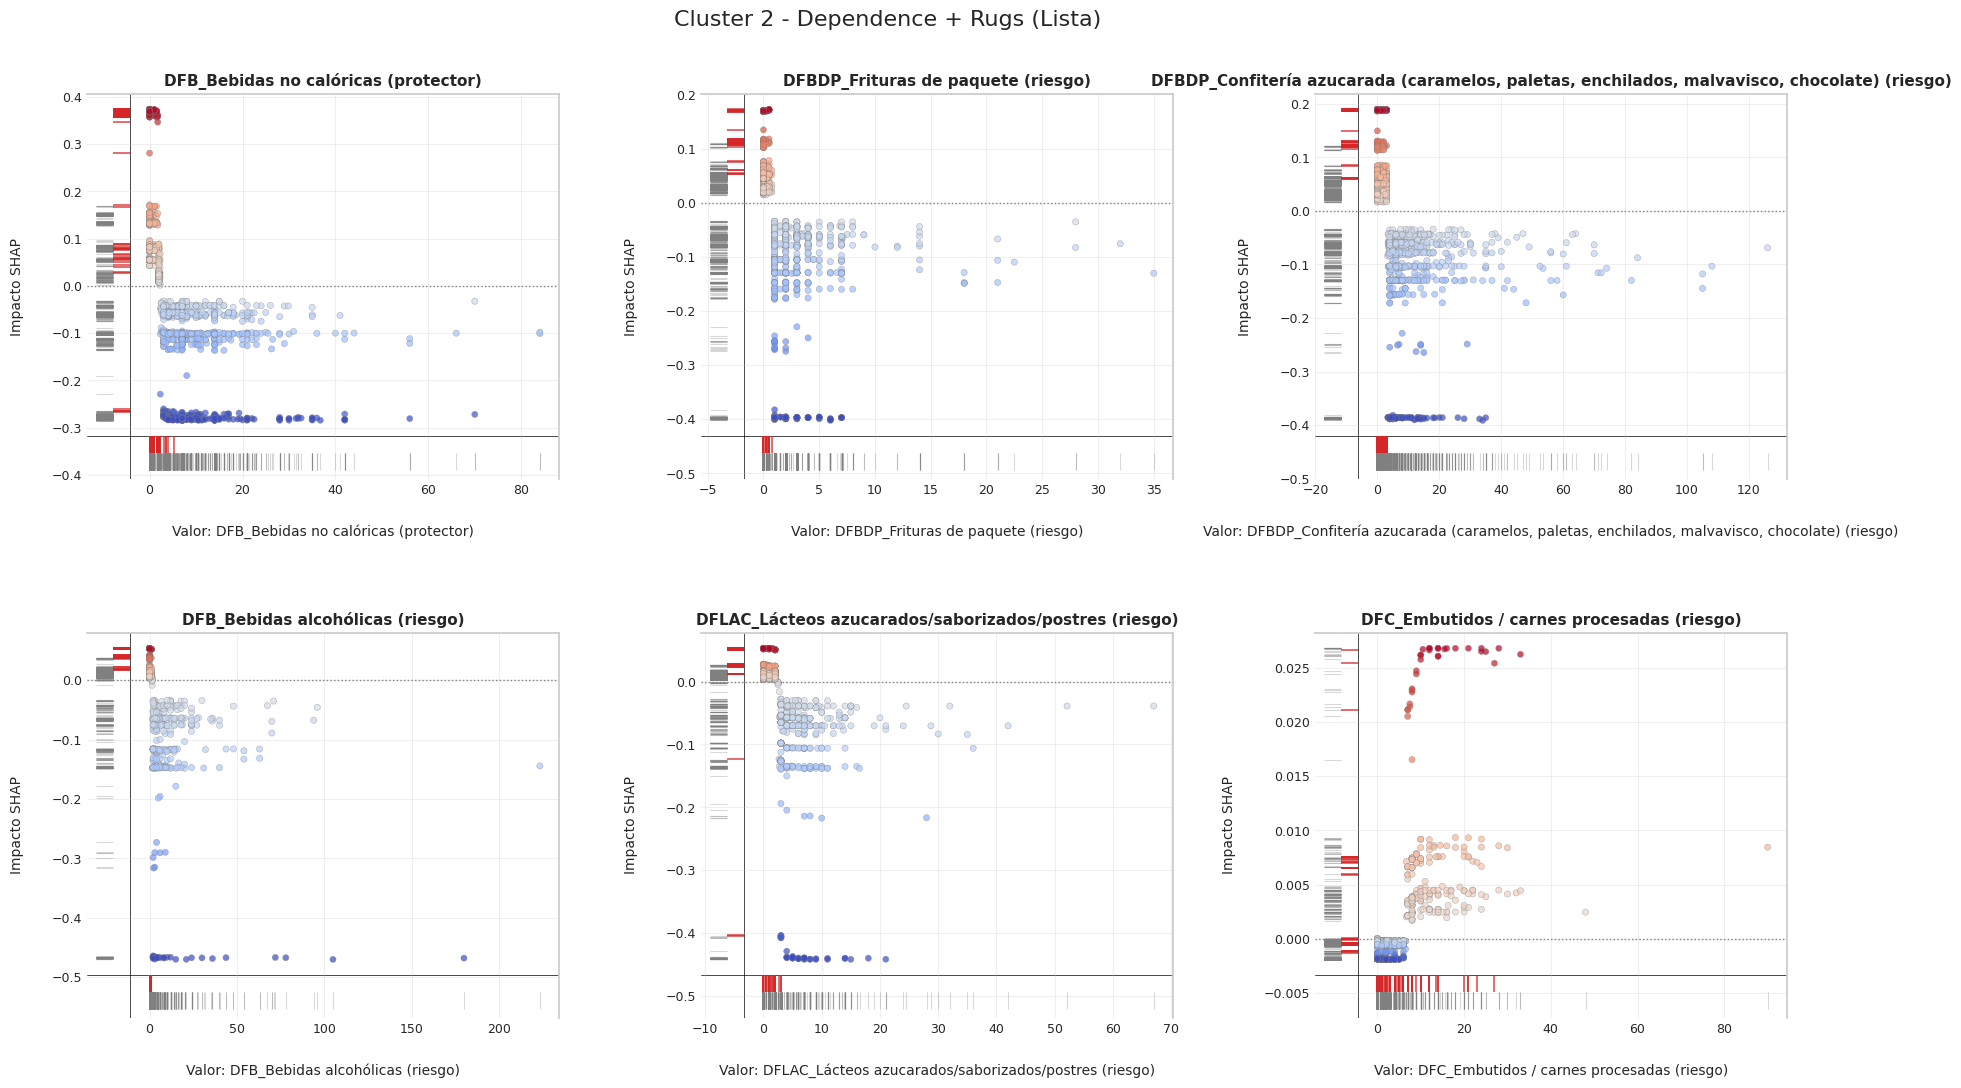

   🔎 Dependence B: NB-selected (mapeado a features originales)


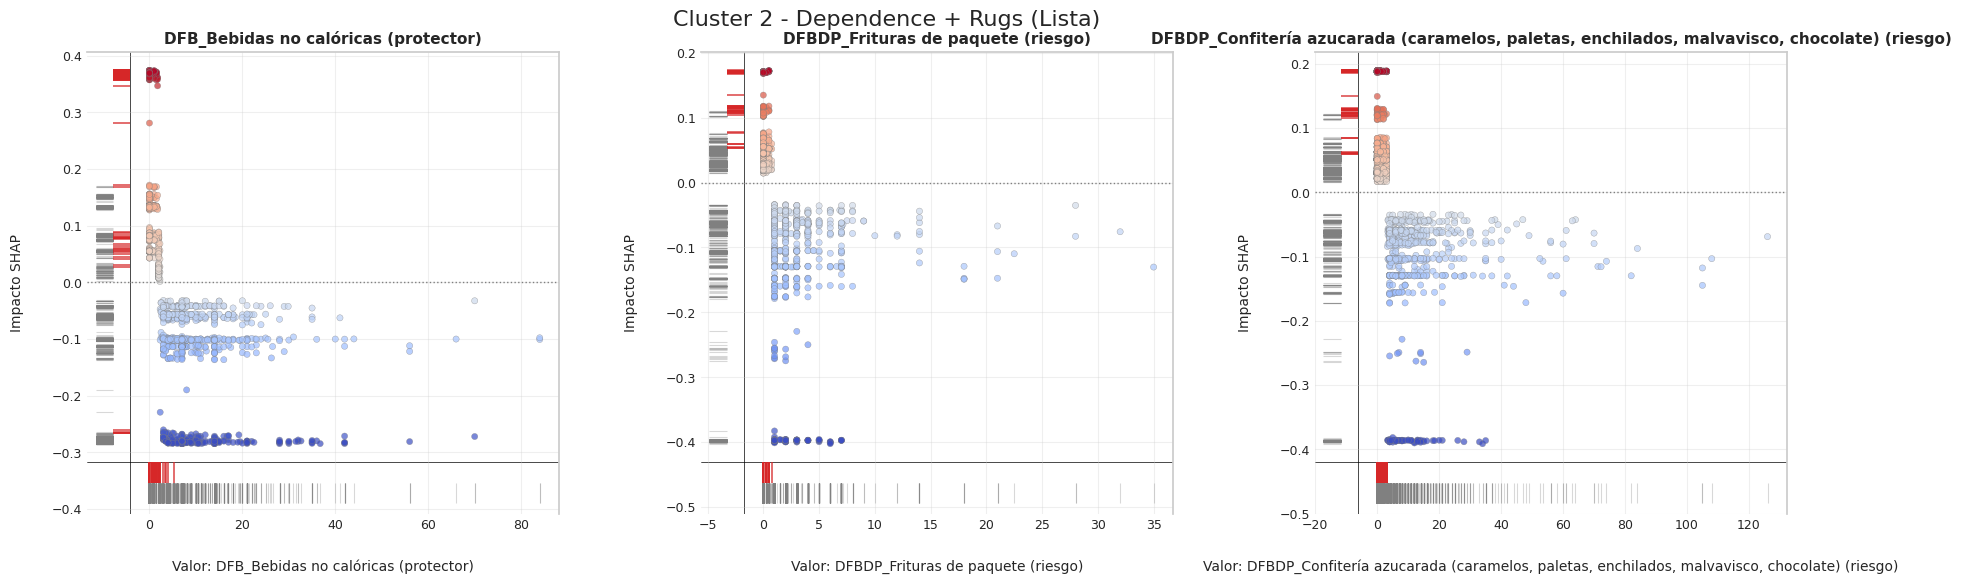

[I 2026-01-11 23:28:39,435] A new study created in memory with name: no-name-6e695324-1fa0-4194-89a4-3fae2743dc30
[I 2026-01-11 23:28:39,523] Trial 0 finished with value: 1.0 and parameters: {'alpha': 8.368754499618511, 'min_cases': 28, 'top_k': 10}. Best is trial 0 with value: 1.0.
[I 2026-01-11 23:28:39,597] Trial 1 finished with value: 1.0 and parameters: {'alpha': 2.720688922860375, 'min_cases': 24, 'top_k': 6}. Best is trial 0 with value: 1.0.



  CLUSTER 3 (NB desde TOP SHAP)


[I 2026-01-11 23:28:39,680] Trial 2 finished with value: 1.0 and parameters: {'alpha': 0.6070643754456767, 'min_cases': 13, 'top_k': 7}. Best is trial 0 with value: 1.0.


   ⚙️  TUNING: Alpha=8.3688, Min=28, TopK=10
   📊 DETALLE: TP=327 FN=0 | TN=1767 FP=0
   📈 METRICAS: Sens=100.00% Spec=100.00% AUC=1.000
   🧩 Candidatas=10 | Final=8 | SCORE_MIN=0.05
------------------------------------------------------------------------------------------------------------------------
Original_Feature                    Variable             Condicion     N_Uni N_Clust   N(CX)    N(X)   P(C|X)  Epsilon    Score
------------------------------------------------------------------------------------------------------------------------
C3::DFB_Bebidas alcohólicas (riesg  C3::DFB_Bebidas alc  > 1.12         2094     327     327     327     1.00    42.04     5.34
C3::DFBDP_Frituras de paquete (rie  C3::DFBDP_Frituras   > 1.35         2094     327     106     481     0.22     3.88     0.44
C3::DFFAST_Torta/sándwich (atenció  C3::DFFAST_Torta/sá  > 2.75         2094     327      81     409     0.20     2.33     0.32
C3::DFB_Bebidas no calóricas (prot  C3::DFB_Bebidas no   > 5.90

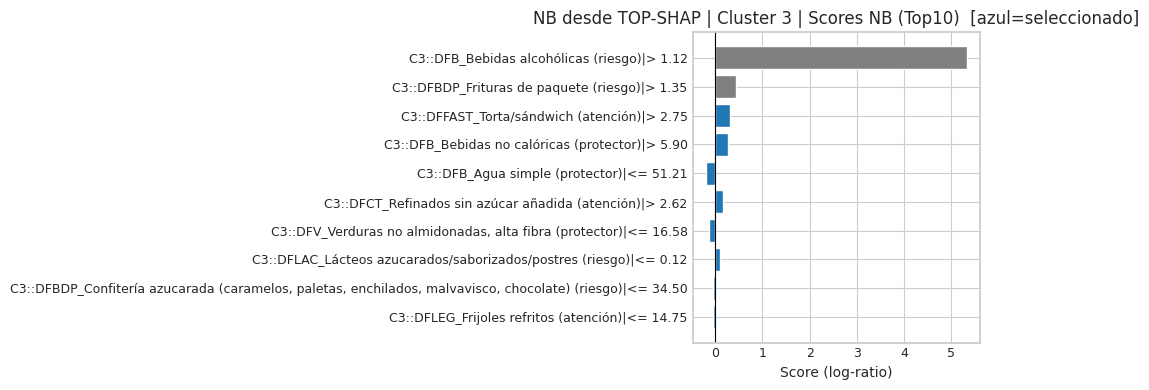

   🔎 Dependence A: TOP-SHAP (RF)


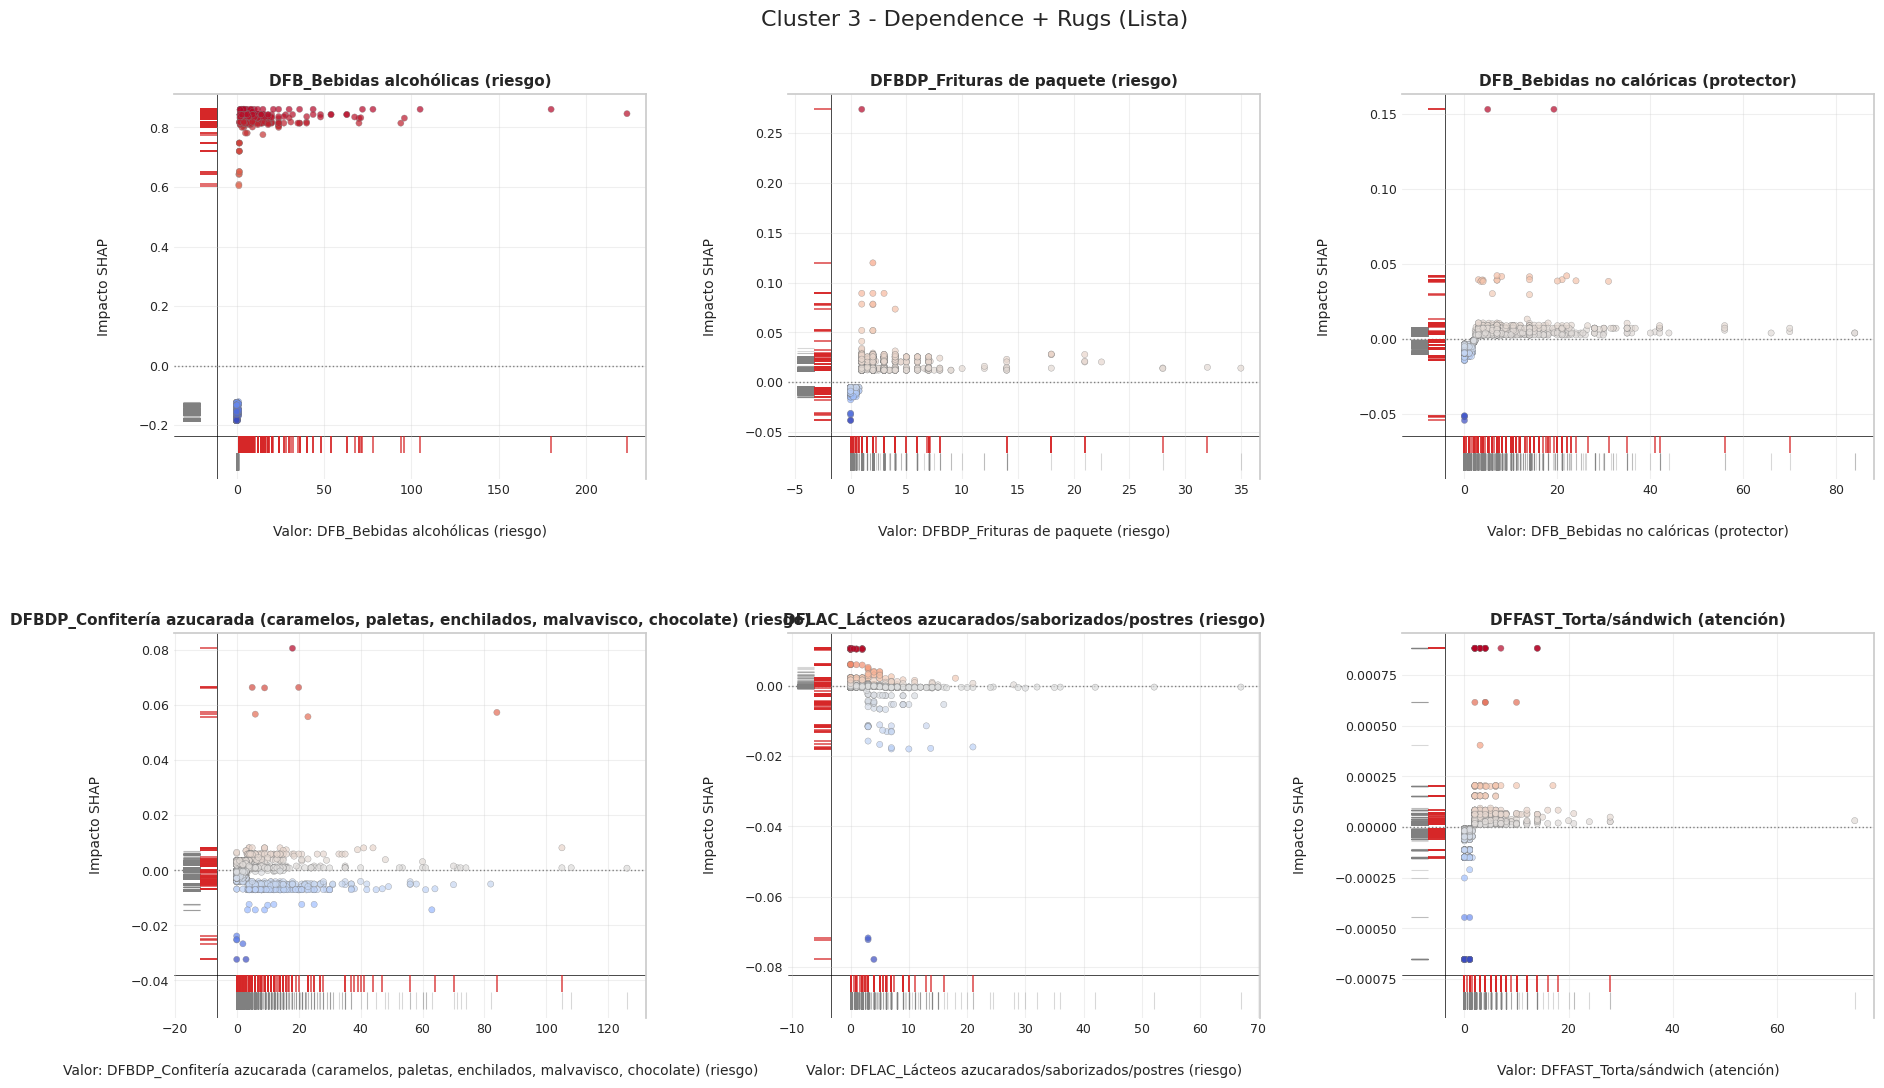

   🔎 Dependence B: NB-selected (mapeado a features originales)


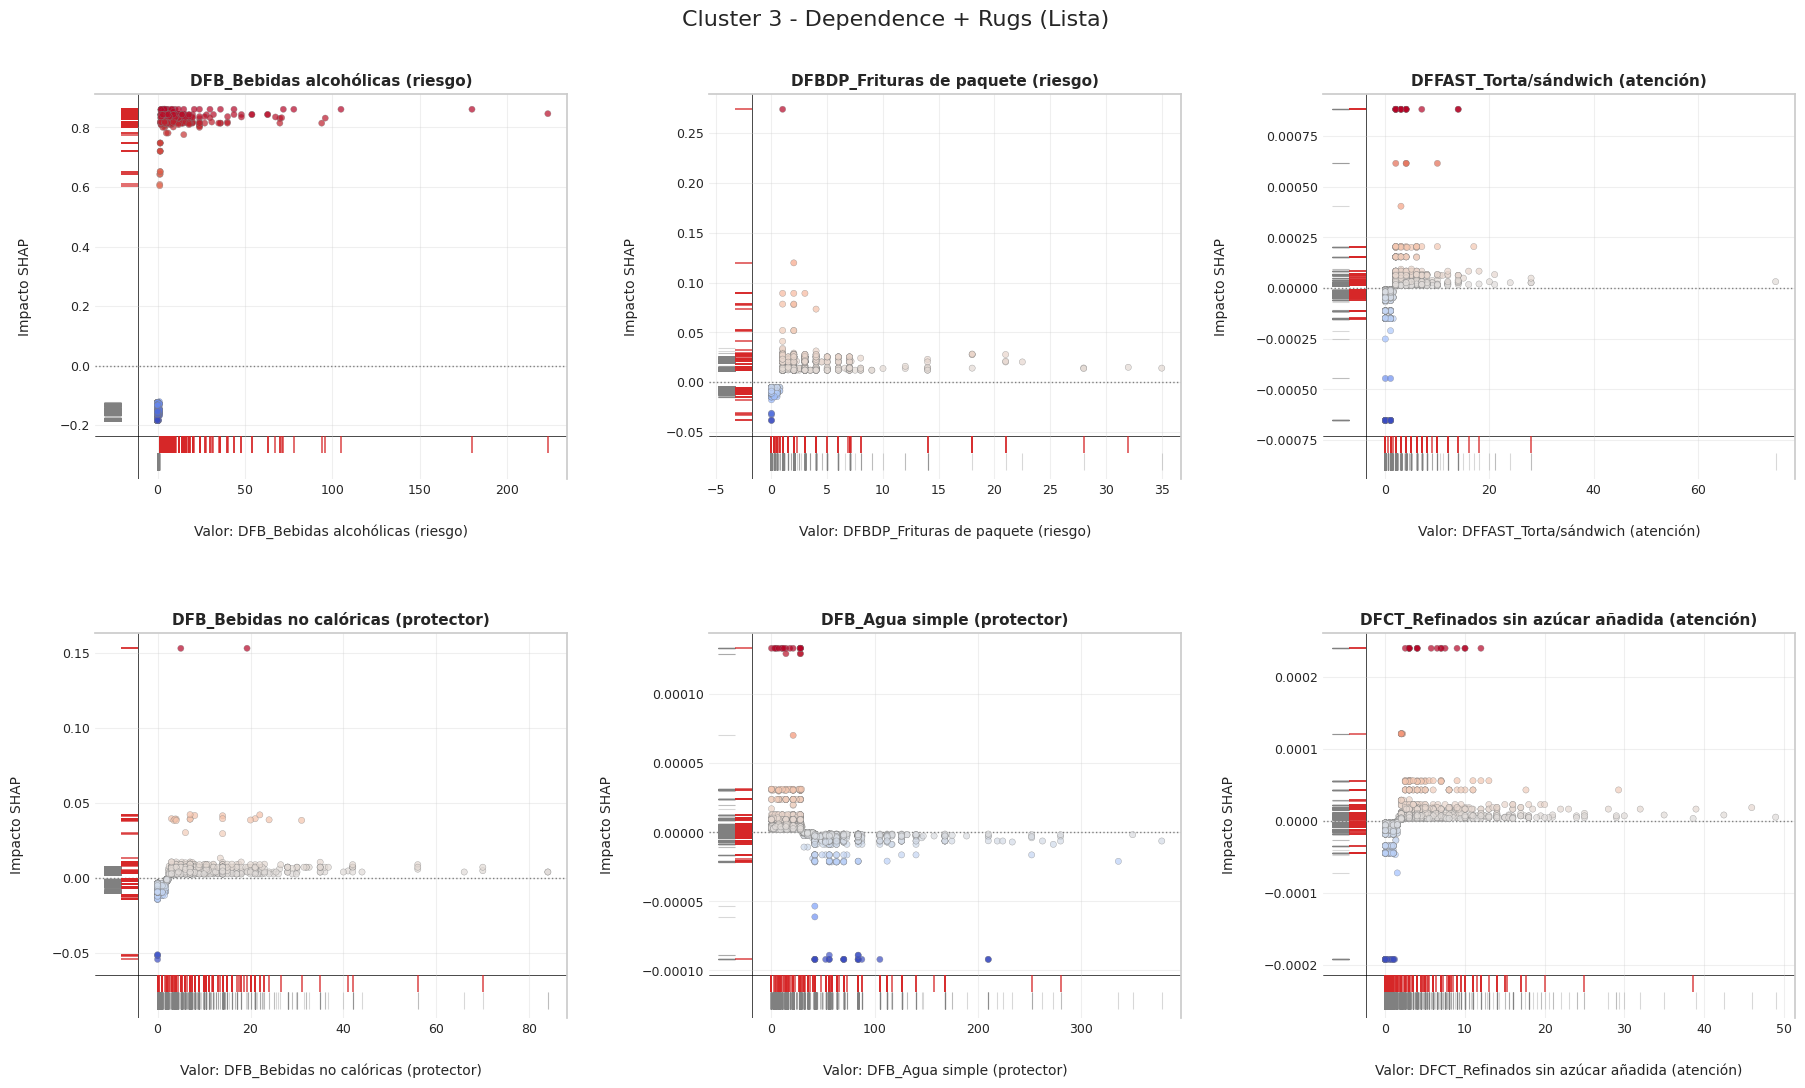

[I 2026-01-11 23:28:44,710] A new study created in memory with name: no-name-d76c209c-d349-490e-aa22-d258a44d3937
[I 2026-01-11 23:28:44,815] Trial 0 finished with value: 0.9930970906588094 and parameters: {'alpha': 0.03432197950516673, 'min_cases': 11, 'top_k': 7}. Best is trial 0 with value: 0.9930970906588094.
[I 2026-01-11 23:28:44,904] Trial 1 finished with value: 0.9930970906588094 and parameters: {'alpha': 0.056621404938803785, 'min_cases': 8, 'top_k': 8}. Best is trial 0 with value: 0.9930970906588094.



  CLUSTER 4 (NB desde TOP SHAP)


[I 2026-01-11 23:28:45,005] Trial 2 finished with value: 0.9930970906588094 and parameters: {'alpha': 0.4363804883896194, 'min_cases': 17, 'top_k': 9}. Best is trial 0 with value: 0.9930970906588094.


   ⚙️  TUNING: Alpha=0.0343, Min=11, TopK=7
   📊 DETALLE: TP=313 FN=3 | TN=1736 FP=42
   📈 METRICAS: Sens=99.05% Spec=97.64% AUC=0.993
   🧩 Candidatas=10 | Final=6 | SCORE_MIN=0.05
------------------------------------------------------------------------------------------------------------------------
Original_Feature                    Variable             Condicion     N_Uni N_Clust   N(CX)    N(X)   P(C|X)  Epsilon    Score
------------------------------------------------------------------------------------------------------------------------
C4::DFBDP_Frituras de paquete (rie  C4::DFBDP_Frituras   > 1.00         2094     316     316     795     0.40    19.42     1.31
C4::DFBDP_Confitería azucarada (ca  C4::DFBDP_Confiterí  <= 3.15        2094     316     316    1408     0.22     7.71     0.49
C4::DFB_Bebidas alcohólicas (riesg  C4::DFB_Bebidas alc  <= 0.60        2094     316     312    1717     0.18     3.57     0.22
C4::DFB_Bebidas azucaradas (riesgo  C4::DFB_Bebidas azu  <= 28.38

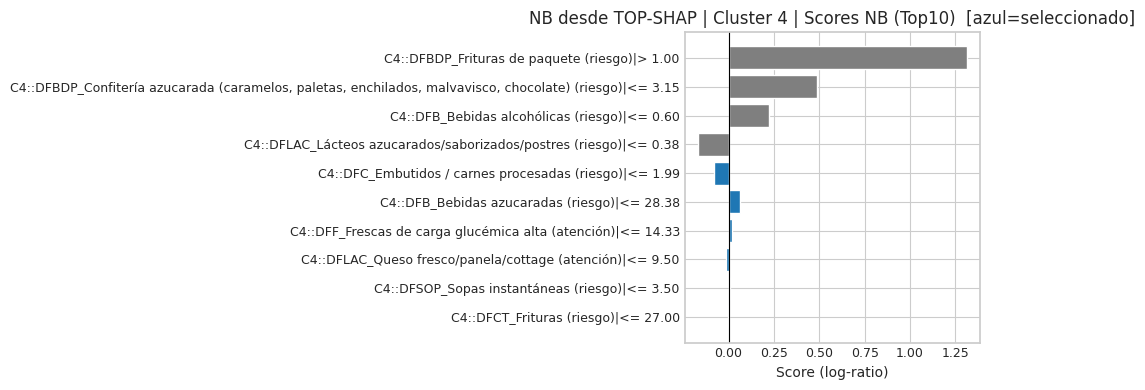

   🔎 Dependence A: TOP-SHAP (RF)


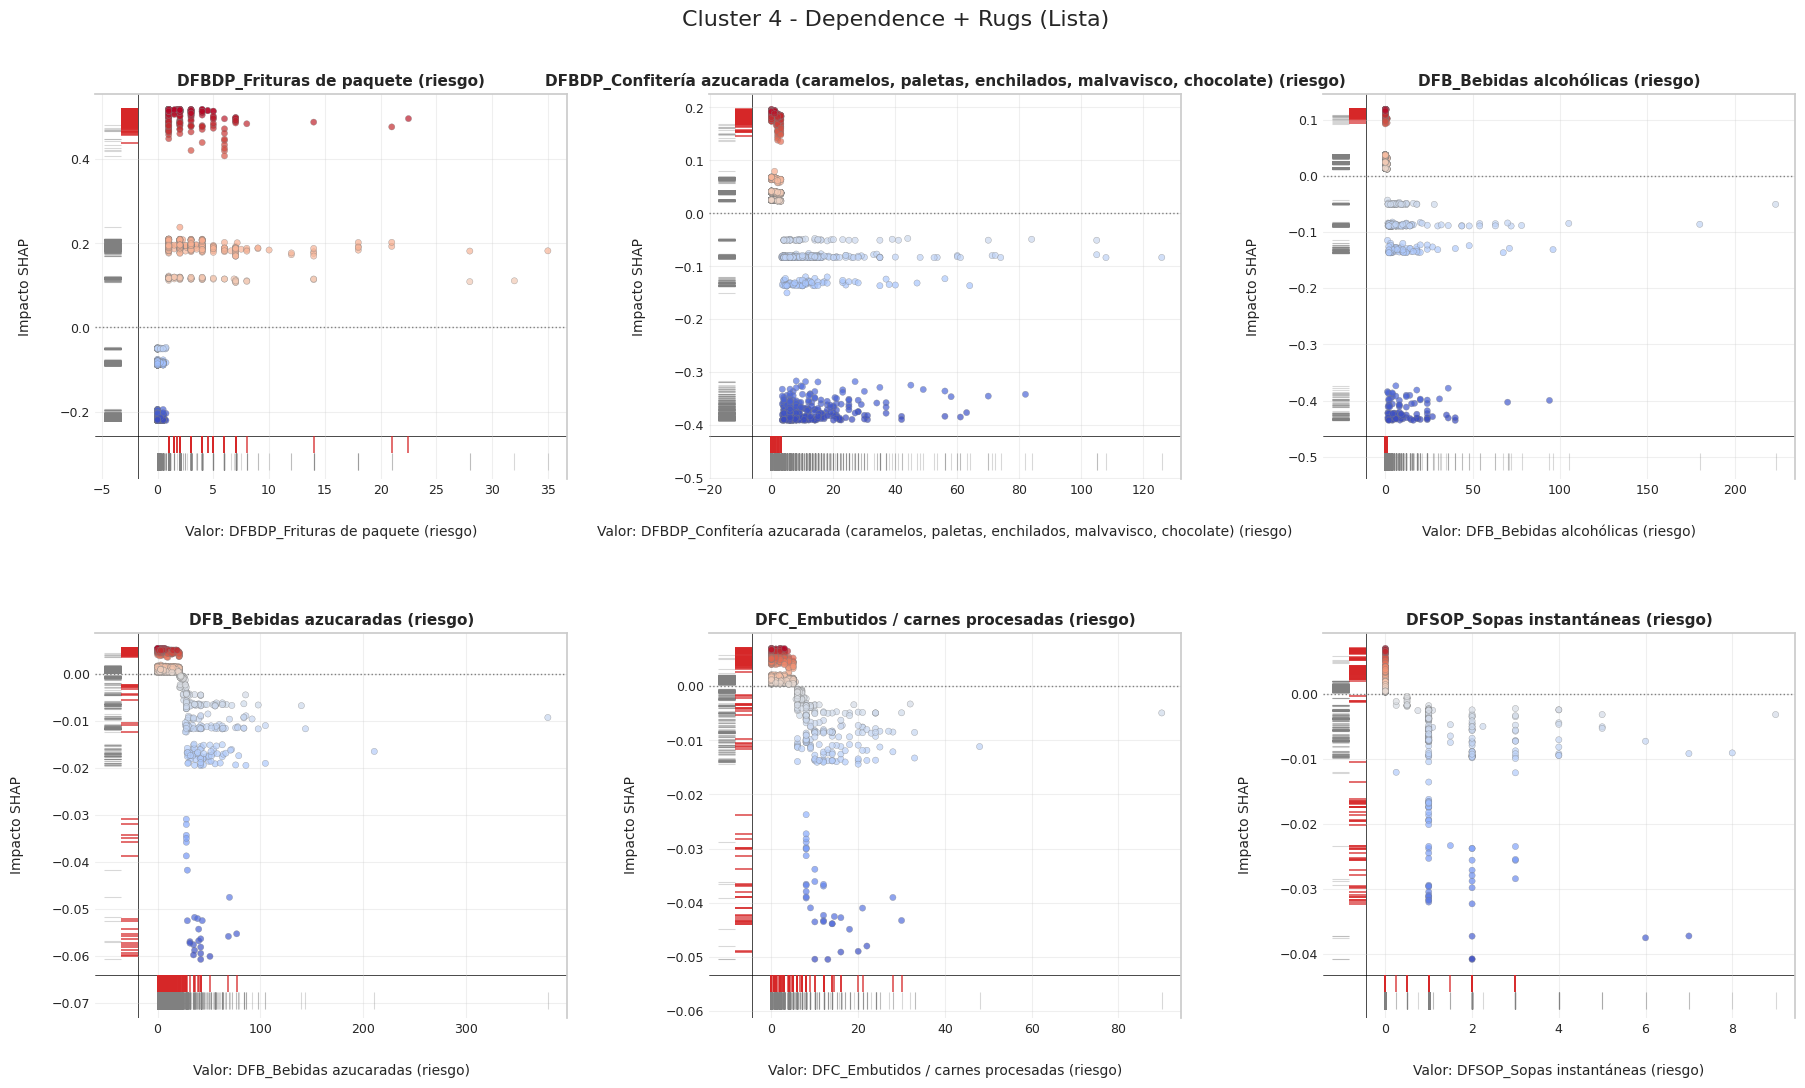

   🔎 Dependence B: NB-selected (mapeado a features originales)


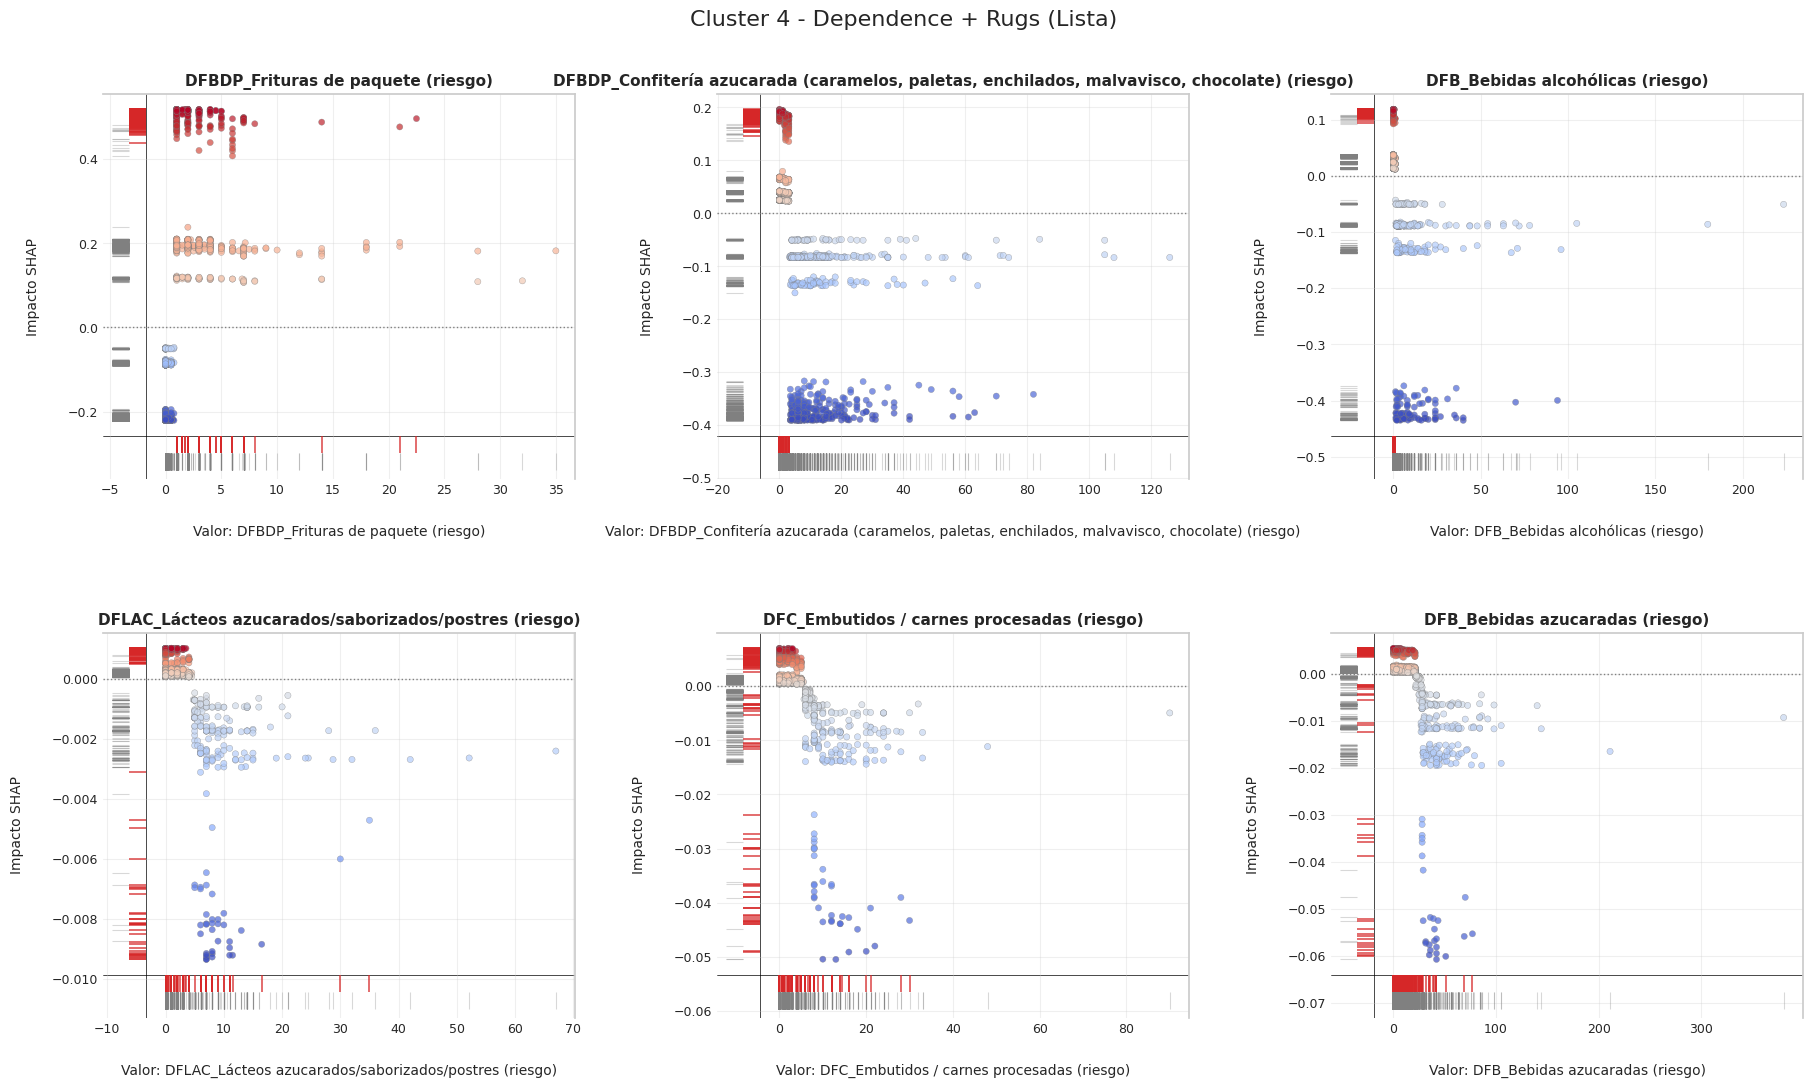


████████████████████████████████████████████████████████████
█ EVALUACIÓN GLOBAL
████████████████████████████████████████████████████████████

Global Accuracy: 78.61%
              precision    recall  f1-score   support

           0      0.824     1.000     0.904       591
           1      0.621     0.918     0.741       512
           2      0.830     0.491     0.617       348
           3      1.000     0.982     0.991       327
           4      1.000     0.294     0.455       316

    accuracy                          0.786      2094
   macro avg      0.855     0.737     0.741      2094
weighted avg      0.829     0.786     0.762      2094



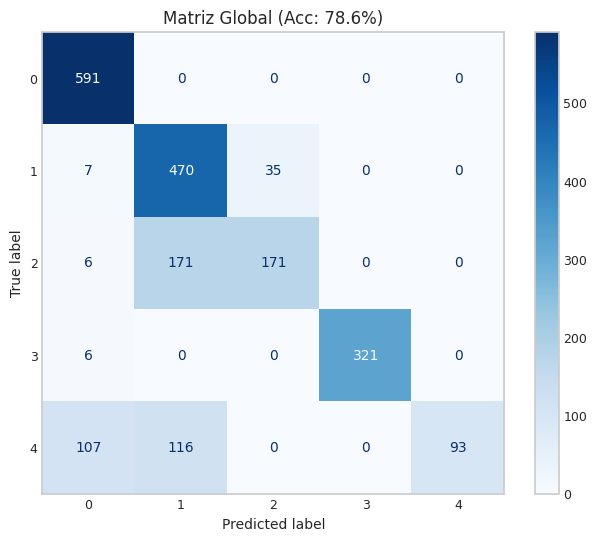


💾 Guardando Excels...
✅ Archivos Excel generados correctamente:
   - 1_Todas_Reglas_Gemelas.xlsx
   - 2_Reglas_Modelo_Optimizado.xlsx
   - 3_Metricas_Performance.xlsx


In [44]:
# =============================================================================
# PROYECTO COMPLETO (1 BLOQUE) - RANDOM FOREST -> SHAP (N,F,K)
# + TABLA/EXCEL CON TODAS LAS COLUMNAS:
#   Original_Feature, Variable, Condicion, N_Uni, N_Clust, N(CX), N(X), P(C|X), Epsilon, Score
# =============================================================================

from __future__ import annotations

import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import shap
import optuna

from scipy.special import expit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, classification_report
)
from sklearn.ensemble import RandomForestClassifier

# -----------------------
# Config general
# -----------------------
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_style("whitegrid")

plt.rcParams.update({
    "figure.max_open_warning": 0,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.autolayout": False
})

SEED = 42
np.random.seed(SEED)

# -----------------------
# Parámetros del proyecto
# -----------------------
TOP_SHAP = 10     # Máximo features por cluster desde SHAP para generar reglas
KEEP_MAX = 10     # Máximo reglas finales por cluster que NB puede quedarse
SCORE_MIN = 0.05  # Umbral: descartar reglas con abs(score) < SCORE_MIN (y también score=0)

# =============================================================================
# 0) CARGA ROBUSTA DE DATOS
# =============================================================================
if "X_df" in locals():
    X_analysis = X_df.copy().reset_index(drop=True)
elif "X_raw" in locals():
    X_analysis = X_raw.copy().reset_index(drop=True)
elif "df_master" in locals():
    X_analysis = df_master.select_dtypes(include=[np.number]).copy().reset_index(drop=True)
else:
    raise ValueError("⚠️ ERROR: No se encontraron datos. Carga 'X_df' o 'X_raw' antes de ejecutar.")

if "cluster_labels" in locals():
    y_true = np.array(cluster_labels)
else:
    raise ValueError("⚠️ ERROR: No se encontraron etiquetas. Carga 'cluster_labels' antes de ejecutar.")

# Limpieza básica
X_analysis = X_analysis.replace([np.inf, -np.inf], np.nan).fillna(0)
y_true = np.array(y_true).astype(int)

unique_clusters = sorted(np.unique(y_true))
n_classes = len(unique_clusters)

print(f"✅ Datos listos: X={X_analysis.shape} | y clases={n_classes} ({unique_clusters})")

# =============================================================================
# 1) OPTUNA TUNING PARA RANDOM FOREST
# =============================================================================
def tune_rf_optuna(X: pd.DataFrame, y: np.ndarray, n_trials: int = 20, n_splits: int = 5):
    """
    Tunea RandomForest con Optuna usando CV estratificada.
    Optimiza AUC macro OVR (multi-class) o AUC binaria.
    """
    X_np = X.to_numpy()
    y_np = np.asarray(y, dtype=int)
    classes = np.unique(y_np)
    n_classes_local = len(classes)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    def objective(trial: optuna.Trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
            "max_depth": trial.suggest_int("max_depth", 4, 30),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
            "n_jobs": -1,
            "random_state": SEED
        }

        aucs = []
        for tr, ts in cv.split(X_np, y_np):
            model = RandomForestClassifier(**params)
            model.fit(X_np[tr], y_np[tr])

            proba = model.predict_proba(X_np[ts])
            y_ts = y_np[ts]

            if len(np.unique(y_ts)) < 2:
                auc = 0.5
            else:
                if n_classes_local > 2:
                    auc = roc_auc_score(y_ts, proba, multi_class="ovr", average="macro")
                else:
                    auc = roc_auc_score(y_ts, proba[:, 1])

            aucs.append(auc)

        return float(np.mean(aucs))

    study = optuna.create_study(direction="maximize")
    print(f"🚀 Optuna: tuning RandomForest | trials={n_trials} | CV={n_splits}")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = study.best_params.copy()
    best_params.update({"n_jobs": -1, "random_state": SEED})

    print("✅ Best AUC(CV):", study.best_value)
    print("✅ Best params:", best_params)
    return best_params, study

best_rf_params, rf_study = tune_rf_optuna(X_analysis, y_true, n_trials=20, n_splits=5)

print("\n🚀 Entrenando RandomForest FINAL con mejores hiperparámetros...")
model_rf = RandomForestClassifier(**best_rf_params)
model_rf.fit(X_analysis, y_true)
print("✅ RandomForest final entrenado.")

# =============================================================================
# 1B) SHAP PARA RANDOM FOREST (TreeExplainer) -> NORMALIZAR (N,F,K)
# =============================================================================
print("\n🧠 Calculando SHAP Values (RandomForest)...")
explainer = shap.TreeExplainer(model_rf)

shap_out = explainer.shap_values(X_analysis)

if isinstance(shap_out, list):
    shap_values_full = np.stack(shap_out, axis=2)  # (N,F,K)
else:
    shap_values_full = np.asarray(shap_out, dtype=float)
    if shap_values_full.ndim == 3 and shap_values_full.shape[0] == n_classes and shap_values_full.shape[1] == X_analysis.shape[0]:
        shap_values_full = np.transpose(shap_values_full, (1, 2, 0))  # (N,F,K)
    elif shap_values_full.ndim == 2:
        # binario (N,F) -> (N,F,2)
        shap_values_full = np.stack([-shap_values_full, shap_values_full], axis=2)

if shap_values_full.ndim != 3:
    raise ValueError(f"SHAP no quedó 3D. shape={shap_values_full.shape}")

print("✅ SHAP listo. shape =", shap_values_full.shape)

# =============================================================================
# 2) CLASE BAYES CLASSIFIER (TABLA COMPLETA + ROBUSTA A DUPLICADOS)
# =============================================================================
class BayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha: float = 1.0, min_cases: int = 5, epsilon: float = 1e-9):
        self.alpha = alpha
        self.min_cases = min_cases
        self.epsilon = epsilon

    def fit(self, X, y):
        X_df = pd.DataFrame(X).reset_index(drop=True)
        y_arr = np.array(y).astype(int)
        self.classes_ = np.array([0, 1])

        # colapsar duplicadas por seguridad
        if not X_df.columns.is_unique:
            X_df = X_df.groupby(X_df.columns, axis=1).max()

        Xv = (X_df > 0).astype(int)
        mask = (y_arr == 1)

        Nc = int(mask.sum())
        N = int(len(y_arr))

        prior = Nc / N if N else 0.0
        self.prior_ = prior
        p_safe = np.clip(prior, self.epsilon, 1.0 - self.epsilon)
        self.intercept_ = np.log(p_safe / (1.0 - p_safe))

        rows = []
        weights = {}

        for col in Xv.columns:
            vals = Xv[col].values
            n_x = int(vals.sum())
            n_cx = int(vals[mask].sum())
            n_x_nc = n_x - n_cx

            denom1 = (Nc + 2 * self.alpha)
            denom0 = ((N - Nc) + 2 * self.alpha)

            p_c = (n_cx + self.alpha) / denom1 if denom1 > 0 else 0.0
            p_nc = (n_x_nc + self.alpha) / denom0 if denom0 > 0 else 0.0

            score = np.log(max(p_c, self.epsilon) / max(p_nc, self.epsilon))
            if n_cx < self.min_cases:
                score = 0.0

            p_cx_val = n_cx / n_x if n_x > 0 else 0.0

            denom = np.sqrt(n_x * self.prior_ * (1.0 - self.prior_)) if n_x > 0 else 0.0
            stat_epsilon = float((n_x * (p_cx_val - self.prior_) / denom) if denom > 0 else 0.0)

            col_str = str(col)
            if "|" in col_str:
                var_name, cond = col_str.split("|", 1)
            else:
                var_name, cond = col_str, "Bool"

            weights[col] = score
            rows.append({
                "Original_Feature": col,
                "Variable": var_name.strip(),
                "Condicion": cond.strip(),
                "N_Uni": N,
                "N_Clust": Nc,
                "N(CX)": n_cx,
                "N(X)": n_x,
                "P(C|X)": p_cx_val,
                "Epsilon": stat_epsilon,
                "Score": score
            })

        # ✅ tabla COMPLETA con exactamente tus columnas
        self.feature_table_ = pd.DataFrame(rows)[[
            "Original_Feature", "Variable", "Condicion", "N_Uni", "N_Clust",
            "N(CX)", "N(X)", "P(C|X)", "Epsilon", "Score"
        ]].sort_values("Score", ascending=False)

        self.weights_ = pd.Series(weights)
        return self

    def predict_proba(self, X):
        X_df = pd.DataFrame(X)
        if not X_df.columns.is_unique:
            X_df = X_df.groupby(X_df.columns, axis=1).max()

        common = X_df.columns.intersection(self.weights_.index)
        if len(common) == 0:
            return np.zeros((len(X_df), 2))

        w = self.weights_.reindex(common).fillna(0.0)
        Xs = X_df.reindex(columns=common).fillna(0)

        log_odds = Xs.dot(w) + self.intercept_
        p1 = expit(log_odds)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# =============================================================================
# 3) TOP SHAP POR CLUSTER -> REGLAS SOLO DE ESAS FEATURES (Ck::...)
# =============================================================================
def top_shap_features_por_cluster(X: pd.DataFrame,
                                 shap_vals_3d: np.ndarray,
                                 unique_clusters_sorted: list[int],
                                 top_shap: int = 10) -> dict[int, list[str]]:
    shap_vals_3d = np.asarray(shap_vals_3d, dtype=float)
    if shap_vals_3d.ndim != 3:
        raise ValueError(f"Se esperaba SHAP 3D (N,F,K). Recibido: {shap_vals_3d.shape}")

    N, F, K = shap_vals_3d.shape
    if X.shape[0] != N or X.shape[1] != F:
        raise ValueError("X y SHAP no alinean en shape.")

    out = {}
    for c_id in unique_clusters_sorted:
        kpos = unique_clusters_sorted.index(c_id)
        s_c = shap_vals_3d[:, :, kpos]  # (N,F)
        impact = np.mean(np.abs(s_c), axis=0)  # (F,)
        m = min(top_shap, F)
        top_idx = np.argsort(impact)[::-1][:m]
        out[c_id] = X.columns.to_numpy()[top_idx].tolist()
    return out


def generar_reglas_desde_features_shap(X_raw: pd.DataFrame,
                                      y_labels: np.ndarray,
                                      shap_vals_3d: np.ndarray,
                                      cluster_id: int,
                                      unique_clusters_sorted: list[int],
                                      features: list[str]) -> pd.DataFrame:
    shap_vals_3d = np.asarray(shap_vals_3d, dtype=float)
    if shap_vals_3d.ndim != 3:
        raise ValueError(f"Se esperaba SHAP 3D (N,F,K). Recibido: {shap_vals_3d.shape}")

    if cluster_id not in unique_clusters_sorted:
        raise ValueError(f"cluster_id={cluster_id} no está en {unique_clusters_sorted}")
    kpos = unique_clusters_sorted.index(cluster_id)
    s_c = shap_vals_3d[:, :, kpos]  # (N,F)

    y_bin = (np.asarray(y_labels).astype(int) == int(cluster_id)).astype(int)
    prefix = f"C{cluster_id}::"

    reglas = {}
    for col in features:
        if col not in X_raw.columns:
            continue

        x_col = X_raw[col].to_numpy(dtype=float)
        col_idx = X_raw.columns.get_loc(col)

        tree = DecisionTreeClassifier(max_depth=1, random_state=SEED)
        tree.fit(x_col.reshape(-1, 1), y_bin)

        if len(tree.tree_.threshold) == 0:
            continue
        th = tree.tree_.threshold[0]
        if th == -2:
            continue

        mask_right = (x_col > th)
        if mask_right.sum() == 0:
            continue

        mean_shap_right = float(np.mean(s_c[mask_right, col_idx]))

        if mean_shap_right > 0:
            name = f"{prefix}{col}|> {th:.2f}"
            reglas[name] = (x_col > th).astype(int)
        else:
            name = f"{prefix}{col}|<= {th:.2f}"
            reglas[name] = (x_col <= th).astype(int)

    df_rules = pd.DataFrame(reglas, index=X_raw.index)
    return df_rules


def build_reglas_global_por_cluster(X_raw: pd.DataFrame,
                                   y: np.ndarray,
                                   shap_vals_3d: np.ndarray,
                                   unique_clusters_sorted: list[int],
                                   top_shap: int = 10):
    top_feats = top_shap_features_por_cluster(
        X=X_raw,
        shap_vals_3d=shap_vals_3d,
        unique_clusters_sorted=unique_clusters_sorted,
        top_shap=top_shap
    )

    dfs = []
    reglas_cols_por_cluster = {}

    for c_id in unique_clusters_sorted:
        df_c = generar_reglas_desde_features_shap(
            X_raw=X_raw,
            y_labels=y,
            shap_vals_3d=shap_vals_3d,
            cluster_id=c_id,
            unique_clusters_sorted=unique_clusters_sorted,
            features=top_feats[c_id]
        )
        reglas_cols_por_cluster[c_id] = df_c.columns.tolist()
        dfs.append(df_c)

    df_reglas_global = pd.concat(dfs, axis=1).fillna(0).astype(int)
    return df_reglas_global, reglas_cols_por_cluster, top_feats

# =============================================================================
# 4) OPTUNA PARA NB (SOLO TOP-SHAP RULES) + FILTRO SCORE (NO 0, NO BAJOS)
# =============================================================================
def _seleccionar_reglas_por_score(clf: BayesClassifier,
                                 score_min: float,
                                 keep_max: int) -> list[str]:
    ft = clf.feature_table_.copy()
    if ft.empty:
        return []

    ft["AbsScore"] = ft["Score"].abs()
    ft = ft[(ft["Score"] != 0.0) & (ft["AbsScore"] >= float(score_min))]
    ft = ft.sort_values("AbsScore", ascending=False)

    feats = ft["Original_Feature"].tolist()
    return feats[:min(int(keep_max), len(feats))]


def optimizar_nb_con_optuna_topshap(X_rules: pd.DataFrame,
                                   y_bin: np.ndarray,
                                   candidate_rules: list[str],
                                   n_trials: int = 3,
                                   n_splits: int = 5,
                                   score_min: float = 0.05,
                                   keep_max: int = 10):
    y_bin = np.array(y_bin).astype(int)
    cand = [c for c in candidate_rules if c in X_rules.columns]

    if len(cand) == 0:
        empty_model = BayesClassifier()
        empty_model.fit(pd.DataFrame(np.zeros((len(X_rules), 1))), np.zeros(len(X_rules), dtype=int))
        return empty_model, [], {
            "TP": 0, "TN": 0, "FP": 0, "FN": 0,
            "Sens": 0, "Spec": 0, "AUC": 0.5,
            "N_Total_Reglas": 0, "N_Final_Reglas": 0,
            "Params": {}
        }, pd.DataFrame()

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    def objective(trial: optuna.Trial):
        alpha = trial.suggest_float("alpha", 1e-3, 10.0, log=True)
        min_cases = trial.suggest_int("min_cases", 1, 30)
        top_k = trial.suggest_int("top_k", 1, min(int(keep_max), len(cand)))

        aucs = []
        for tr, ts in cv.split(X_rules[cand], y_bin):
            Xtr = X_rules.iloc[tr][cand]
            Xts = X_rules.iloc[ts][cand]

            m0 = BayesClassifier(alpha=alpha, min_cases=min_cases).fit(Xtr, y_bin[tr])
            feats_sc = _seleccionar_reglas_por_score(m0, score_min=score_min, keep_max=top_k)

            if len(feats_sc) == 0:
                aucs.append(0.5)
                continue

            m = BayesClassifier(alpha=alpha, min_cases=min_cases).fit(Xtr[feats_sc], y_bin[tr])
            p = m.predict_proba(Xts[feats_sc])[:, 1]

            if len(np.unique(y_bin[ts])) > 1:
                aucs.append(roc_auc_score(y_bin[ts], p))
            else:
                aucs.append(0.5)

        return float(np.mean(aucs))

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best = study.best_params
    alpha_best = float(best["alpha"])
    min_cases_best = int(best["min_cases"])
    top_k_best = int(best["top_k"])

    m0 = BayesClassifier(alpha=alpha_best, min_cases=min_cases_best).fit(X_rules[cand], y_bin)
    feats = _seleccionar_reglas_por_score(m0, score_min=score_min, keep_max=top_k_best)

    if len(feats) == 0:
        empty_model = BayesClassifier(alpha=alpha_best, min_cases=min_cases_best)
        empty_model.fit(pd.DataFrame(np.zeros((len(X_rules), 1))), np.zeros(len(X_rules), dtype=int))
        return empty_model, [], {
            "TP": 0, "TN": 0, "FP": 0, "FN": 0,
            "Sens": 0, "Spec": 0, "AUC": float(study.best_value),
            "N_Total_Reglas": len(cand), "N_Final_Reglas": 0,
            "Params": {"alpha": alpha_best, "min_cases": min_cases_best, "top_k": top_k_best}
        }, m0.feature_table_

    final_model = BayesClassifier(alpha=alpha_best, min_cases=min_cases_best).fit(X_rules[feats], y_bin)

    y_pred = final_model.predict(X_rules[feats])
    cm = confusion_matrix(y_bin, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0

    metrics = {
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
        "Sens": sens, "Spec": spec,
        "AUC": float(study.best_value),
        "N_Total_Reglas": len(cand),
        "N_Final_Reglas": len(feats),
        "Params": {"alpha": alpha_best, "min_cases": min_cases_best, "top_k": top_k_best}
    }

    return final_model, feats, metrics, m0.feature_table_

# =============================================================================
# 5) PLOTS: SCORES + DEPENDENCE (STACKED RUGS)
# =============================================================================
def plot_scores_comparacion(cluster_id: int,
                            ft_full: pd.DataFrame,
                            feats_selected: list[str],
                            title_prefix: str = ""):
    if ft_full is None or ft_full.empty:
        print(f"[Cluster {cluster_id}] feature_table vacía, no hay scores para plot.")
        return

    df = ft_full.copy()
    df["AbsScore"] = df["Score"].abs()
    df = df.sort_values("AbsScore", ascending=False)

    top10 = df.head(10).copy()
    top10["Selected"] = top10["Original_Feature"].isin(set(feats_selected))

    plt.figure(figsize=(10, 4))
    colors = ["#1f77b4" if s else "#7f7f7f" for s in top10["Selected"].tolist()]
    plt.barh(top10["Original_Feature"][::-1], top10["Score"][::-1], color=colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(f"{title_prefix}Cluster {cluster_id} | Scores NB (Top10)  [azul=seleccionado]")
    plt.xlabel("Score (log-ratio)")
    plt.tight_layout()
    plt.show()


def plot_shap_dependence_stacked_rugs_lista(X: pd.DataFrame, y: np.ndarray, shap_vals_3d: np.ndarray,
                                           cluster_id: int, unique_clusters_sorted: list[int],
                                           cols: list[str]):
    shap_vals_3d = np.asarray(shap_vals_3d, dtype=float)
    if shap_vals_3d.ndim != 3:
        raise ValueError(f"Se esperaba SHAP 3D (N,F,K). Recibido: {shap_vals_3d.shape}")

    if cluster_id not in unique_clusters_sorted:
        raise ValueError(f"cluster_id={cluster_id} no existe en {unique_clusters_sorted}")
    kpos = unique_clusters_sorted.index(cluster_id)
    s_c = shap_vals_3d[:, :, kpos]  # (N,F)

    cols = [c for c in cols if c in X.columns]
    if len(cols) == 0:
        print(f"[Cluster {cluster_id}] No hay columnas válidas para dependence plot.")
        return

    mask_cluster = (y == cluster_id)
    mask_rest = (y != cluster_id)

    cols_grid = 3
    rows_grid = math.ceil(len(cols) / cols_grid)

    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(20, 6 * rows_grid))
    fig.subplots_adjust(top=0.92, bottom=0.15, left=0.1, right=0.95, hspace=0.4, wspace=0.3)
    fig.suptitle(f"Cluster {cluster_id} - Dependence + Rugs (Lista)", fontsize=16, y=0.99)

    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols):
        ax = axes[i]
        x_col = X[col].to_numpy(dtype=float)
        shap_col = s_c[:, X.columns.get_loc(col)]

        try:
            divnorm = mcolors.TwoSlopeNorm(vmin=float(np.min(shap_col)), vcenter=0.0, vmax=float(np.max(shap_col)))
        except Exception:
            divnorm = None

        ax.scatter(
            x_col, shap_col,
            c=shap_col, cmap="coolwarm", norm=divnorm,
            alpha=0.7, s=20, edgecolor="grey", linewidth=0.3, zorder=10
        )

        y_min_data, y_max_data = ax.get_ylim()
        x_min_data, x_max_data = ax.get_xlim()

        y_range = y_max_data - y_min_data
        x_range = x_max_data - x_min_data

        rug_height = y_range * 0.05
        rug_width = x_range * 0.04

        ax.set_ylim(y_min_data - 2.5 * rug_height, y_max_data)
        ax.set_xlim(x_min_data - 2.5 * rug_width, x_max_data)

        ax.vlines(
            x_col[mask_rest],
            ymin=y_min_data - 2 * rug_height, ymax=y_min_data - rug_height,
            color="grey", alpha=0.3, linewidth=0.8, zorder=1
        )
        ax.vlines(
            x_col[mask_cluster],
            ymin=y_min_data - rug_height, ymax=y_min_data,
            color="#d62728", alpha=0.8, linewidth=1.2, zorder=5
        )

        ax.hlines(
            shap_col[mask_rest],
            xmin=x_min_data - 2 * rug_width, xmax=x_min_data - rug_width,
            color="grey", alpha=0.3, linewidth=0.8, zorder=1
        )
        ax.hlines(
            shap_col[mask_cluster],
            xmin=x_min_data - rug_width, xmax=x_min_data,
            color="#d62728", alpha=0.8, linewidth=1.2, zorder=5
        )

        ax.axhline(0, color="gray", linestyle=":", linewidth=1)
        ax.set_title(f"{col}", fontsize=11, fontweight="bold")
        ax.set_ylabel("Impacto SHAP", labelpad=20)
        ax.set_xlabel(f"Valor: {col}", labelpad=20)
        ax.grid(True, linestyle="-", alpha=0.3)

        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.axhline(y_min_data, color="black", linewidth=0.5, zorder=0)
        ax.axvline(x_min_data, color="black", linewidth=0.5, zorder=0)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.show()


def reglas_a_features_originales(reglas: list[str]) -> list[str]:
    feats = []
    for r in reglas:
        s = str(r)
        if "::" in s:
            s = s.split("::", 1)[1]
        if "|" in s:
            feats.append(s.split("|", 1)[0].strip())
        else:
            feats.append(s.strip())

    out, seen = [], set()
    for f in feats:
        if f not in seen:
            out.append(f)
            seen.add(f)
    return out

# =============================================================================
# 6) EJECUCIÓN: TOP SHAP -> REGLAS -> NB+OPTUNA + COMPARACIONES
# =============================================================================
df_reglas, reglas_cols_por_cluster, top_feats_por_cluster = build_reglas_global_por_cluster(
    X_raw=X_analysis,
    y=y_true,
    shap_vals_3d=shap_values_full,
    unique_clusters_sorted=unique_clusters,
    top_shap=TOP_SHAP
)

print(f"\n✅ df_reglas global: {df_reglas.shape} (unión de reglas por cluster desde TOP_SHAP={TOP_SHAP})")

modelos_finales = {}
dfs_full = {}   # NB feature_table (candidatas TOP-SHAP)
dfs_best = {}   # NB feature_table final (fit con reglas filtradas)
lista_metricas = []

# columnas EXACTAS que quieres imprimir/guardar
COLS_TABLE = ["Original_Feature", "Variable", "Condicion", "N_Uni", "N_Clust",
              "N(CX)", "N(X)", "P(C|X)", "Epsilon", "Score"]

for c_id in unique_clusters:
    print("\n" + "=" * 60 + f"\n  CLUSTER {c_id} (NB desde TOP SHAP)\n" + "=" * 60)

    y_bin = (y_true == c_id).astype(int)
    candidate_rules = reglas_cols_por_cluster.get(c_id, [])

    model, feats, mets, df_full_stats = optimizar_nb_con_optuna_topshap(
        X_rules=df_reglas,
        y_bin=y_bin,
        candidate_rules=candidate_rules,
        n_trials=3,
        n_splits=5,
        score_min=SCORE_MIN,
        keep_max=KEEP_MAX
    )

    modelos_finales[c_id] = (model, feats)

    # df_full_stats ya viene con las columnas completas por el fit de BayesClassifier
    dfs_full[c_id] = df_full_stats[COLS_TABLE].copy() if isinstance(df_full_stats, pd.DataFrame) and not df_full_stats.empty else pd.DataFrame(columns=COLS_TABLE)
    dfs_best[c_id] = model.feature_table_[COLS_TABLE].copy() if hasattr(model, "feature_table_") and isinstance(model.feature_table_, pd.DataFrame) and not model.feature_table_.empty else pd.DataFrame(columns=COLS_TABLE)

    p = mets.get("Params", {})
    print(f"   ⚙️  TUNING: Alpha={p.get('alpha',0):.4f}, Min={p.get('min_cases',0)}, TopK={p.get('top_k',0)}")
    print(f"   📊 DETALLE: TP={mets['TP']} FN={mets['FN']} | TN={mets['TN']} FP={mets['FP']}")
    print(f"   📈 METRICAS: Sens={mets['Sens']:.2%} Spec={mets['Spec']:.2%} AUC={mets['AUC']:.3f}")
    print(f"   🧩 Candidatas={mets['N_Total_Reglas']} | Final={mets['N_Final_Reglas']} | SCORE_MIN={SCORE_MIN}")

    # ---- IMPRIMIR TABLA COMPLETA (TOP 10) CON TODAS LAS COLUMNAS
    if not dfs_best[c_id].empty:
        df_show = dfs_best[c_id].head(10).copy()

        print("-" * 120)
        print(f"{'Original_Feature':<35} {'Variable':<20} {'Condicion':<12} {'N_Uni':>6} {'N_Clust':>7} {'N(CX)':>7} {'N(X)':>7} {'P(C|X)':>8} {'Epsilon':>8} {'Score':>8}")
        print("-" * 120)

        for _, r in df_show.iterrows():
            of = str(r["Original_Feature"])[:34]
            var = str(r["Variable"])[:19]
            cond = str(r["Condicion"])[:11]
            print(f"{of:<35} {var:<20} {cond:<12} {int(r['N_Uni']):>6} {int(r['N_Clust']):>7} {int(r['N(CX)']):>7} {int(r['N(X)']):>7} {float(r['P(C|X)']):>8.2f} {float(r['Epsilon']):>8.2f} {float(r['Score']):>8.2f}")
    else:
        print("   ⚠️ No se encontraron reglas significativas (después de filtros).")

    # ---- 1) Comparación de Scores (Top10)
    if isinstance(df_full_stats, pd.DataFrame) and not df_full_stats.empty:
        plot_scores_comparacion(
            cluster_id=c_id,
            ft_full=df_full_stats,
            feats_selected=feats,
            title_prefix="NB desde TOP-SHAP | "
        )

    # ---- 2) Dependence plots: (A) TOP-SHAP vs (B) NB-selected
    print("   🔎 Dependence A: TOP-SHAP (RF)")
    plot_shap_dependence_stacked_rugs_lista(
        X=X_analysis, y=y_true, shap_vals_3d=shap_values_full,
        cluster_id=c_id, unique_clusters_sorted=unique_clusters,
        cols=top_feats_por_cluster.get(c_id, [])[:6]
    )

    print("   🔎 Dependence B: NB-selected (mapeado a features originales)")
    nb_feats_originales = reglas_a_features_originales(feats)[:6]
    plot_shap_dependence_stacked_rugs_lista(
        X=X_analysis, y=y_true, shap_vals_3d=shap_values_full,
        cluster_id=c_id, unique_clusters_sorted=unique_clusters,
        cols=nb_feats_originales
    )

    mets_excel = {k: v for k, v in mets.items() if k != "Params"}
    mets_excel["Cluster"] = c_id
    lista_metricas.append(mets_excel)

# =============================================================================
# 7) EVALUACIÓN GLOBAL (voting por prob max)
# =============================================================================
print("\n" + "█" * 60 + "\n█ EVALUACIÓN GLOBAL\n" + "█" * 60)

probs_matrix = np.zeros((len(df_reglas), len(unique_clusters)))

for idx, c_id in enumerate(unique_clusters):
    model, feats = modelos_finales[c_id]
    if len(feats) > 0 and all(f in df_reglas.columns for f in feats):
        probs_matrix[:, idx] = model.predict_proba(df_reglas[feats])[:, 1]
    else:
        probs_matrix[:, idx] = 0.0

y_pred_global = [unique_clusters[i] for i in np.argmax(probs_matrix, axis=1)]
acc_global = accuracy_score(y_true, y_pred_global)

print(f"\nGlobal Accuracy: {acc_global:.2%}")
print(classification_report(y_true, y_pred_global, digits=3))

cm = confusion_matrix(y_true, y_pred_global, labels=unique_clusters)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_clusters)
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title(f"Matriz Global (Acc: {acc_global:.1%})")
plt.grid(False)
plt.show()

# =============================================================================
# 8) EXPORTACIÓN A EXCEL (3 ARCHIVOS) - CON TABLAS COMPLETAS
# =============================================================================
print("\n💾 Guardando Excels...")
try:
    with pd.ExcelWriter("1_Todas_Reglas_Gemelas.xlsx") as writer:
        for c, df in dfs_full.items():
            if isinstance(df, pd.DataFrame) and not df.empty:
                df[COLS_TABLE].to_excel(writer, sheet_name=f"C{c}_Full", index=False)
            else:
                pd.DataFrame(columns=COLS_TABLE).to_excel(writer, sheet_name=f"C{c}_Full", index=False)

    with pd.ExcelWriter("2_Reglas_Modelo_Optimizado.xlsx") as writer:
        for c, df in dfs_best.items():
            if isinstance(df, pd.DataFrame) and not df.empty:
                df[COLS_TABLE].to_excel(writer, sheet_name=f"C{c}_Best", index=False)
            else:
                pd.DataFrame(columns=COLS_TABLE).to_excel(writer, sheet_name=f"C{c}_Best", index=False)

    df_metrics = pd.DataFrame(lista_metricas)
    df_cm = pd.DataFrame(
        cm,
        index=[f"T_{c}" for c in unique_clusters],
        columns=[f"P_{c}" for c in unique_clusters]
    )

    with pd.ExcelWriter("3_Metricas_Performance.xlsx") as writer:
        df_metrics.to_excel(writer, sheet_name="Metricas", index=False)
        pd.DataFrame(classification_report(y_true, y_pred_global, output_dict=True)).T.to_excel(writer, sheet_name="Global")
        df_cm.to_excel(writer, sheet_name="Matriz", index=True)

    print("✅ Archivos Excel generados correctamente:")
    print("   - 1_Todas_Reglas_Gemelas.xlsx")
    print("   - 2_Reglas_Modelo_Optimizado.xlsx")
    print("   - 3_Metricas_Performance.xlsx")
except Exception as e:
    print(f"❌ Error guardando: {e}")


In [ ]:
from __future__ import annotations
from typing import Dict, Iterable, Union, List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
from scipy.special import expit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, classification_report)

# =============================================================================
# 1. CLASE BAYES CLASSIFIER (CON EPSILON)
# =============================================================================
def _group_sizes(columns: Iterable[str], sep: str = "|") -> Dict[str, int]:
    gs: Dict[str, int] = {}
    for c in columns:
        cs = str(c)
        group = cs.split(sep, 1)[0] if sep in cs else cs
        gs[group] = gs.get(group, 0) + 1
    return gs

class BayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha: float = 1.0, min_cases: int = 5, sep: str = "|",
                 threshold: float = 0.5, use_prior: bool = True, epsilon: float = 1e-9):
        self.alpha = alpha
        self.min_cases = min_cases
        self.sep = sep
        self.threshold = threshold
        self.use_prior = use_prior
        self.epsilon = epsilon  # Para estabilidad numérica en logs

    def fit(self, X: Union[pd.DataFrame, np.ndarray], y: Union[np.ndarray, pd.Series, list]):
        X_df = self._to_df(X)
        y_arr = np.asarray(y).astype(int)

        if len(np.unique(y_arr)) < 2:
            self.classes_ = np.array([0, 1])
            self.feature_table_ = pd.DataFrame()
            self.weights_ = pd.Series(dtype=float)
            self.intercept_ = 0.0
            return self

        if len(y_arr) != len(X_df): raise ValueError("Mismatch rows X/y")

        self.classes_ = np.array([0, 1], dtype=int)
        Xv = (X_df.fillna(0) > 0).astype(int)

        gs = _group_sizes(Xv.columns, sep=self.sep)
        mask = (y_arr == 1)
        Nc = int(mask.sum())
        N = int(len(y_arr))
        Nnc = N - Nc
        prior = (Nc / N) if N else 0.0
        self.prior_ = float(prior)

        # Intercepto con epsilon para evitar log(0)
        p_odds = np.clip(prior, self.epsilon, 1.0 - self.epsilon)
        self.intercept_ = float(np.log(p_odds / (1.0 - p_odds))) if self.use_prior else 0.0

        rows = []
        weights = {}

        for col in Xv.columns:
            col_s = str(col)
            # Extraer nombre base para reporte
            if self.sep in col_s: group, category = col_s.split(self.sep, 1)
            else: group, category = col_s, ""

            vals = Xv[col].to_numpy(dtype=int)
            Nx = int(vals.sum())
            nCx = int((vals[mask] == 1).sum())
            n_x_nc = Nx - nCx
            Kx = int(gs.get(group, 1))

            # Probabilidades suavizadas (Laplace)
            p_c = (nCx + self.alpha) / (Nc + self.alpha * Kx) if (Nc + self.alpha * Kx) > 0 else 0.0
            p_nc = (n_x_nc + self.alpha) / (int(N - Nc) + self.alpha * Kx) if (int(N - Nc) + self.alpha * Kx) > 0 else 0.0

            # Score Log-Odds con Epsilon de estabilidad
            val_pc = max(p_c, self.epsilon)
            val_pnc = max(p_nc, self.epsilon)
            score = float(np.log(val_pc / val_pnc))

            if nCx < int(self.min_cases): score = 0.0

            # --- CÁLCULO DEL EPSILON ESTADÍSTICO (IMPACTO/Z-SCORE) ---
            p_c_given_x = (nCx / Nx) if Nx > 0 else 0.0
            denom = np.sqrt(Nx * self.prior_ * (1.0 - self.prior_))
            stat_epsilon = float((Nx * (p_c_given_x - self.prior_) / denom) if denom > 0 else 0.0)

            weights[col_s] = score

            rows.append({
                "Original_Feature": col_s,
                "Variable_Base": group,
                "Condicion": category,
                "N_Uni": N, "N_Clust": Nc, "N(CX)": nCx, "N(X)": Nx,
                "P(C|X)": p_c_given_x,
                "Epsilon": stat_epsilon, # <--- ¡AGREGADO!
                "Score": score
            })

        df_tab = pd.DataFrame(rows).sort_values("Score", ascending=False).reset_index(drop=True)
        cols_final = ["Original_Feature", "Variable_Base", "Condicion", "N_Uni", "N_Clust", "N(CX)", "N(X)", "P(C|X)", "Epsilon", "Score"]
        self.feature_table_ = df_tab[cols_final]
        self.weights_ = pd.Series(weights, dtype=float)
        return self

    def predict_proba(self, X):
        X_df = self._to_df(X)
        if not hasattr(self, 'weights_') or self.weights_.empty: return np.zeros((len(X), 2))

        common = X_df.columns.intersection(self.weights_.index)
        if len(common) == 0: return np.zeros((len(X), 2))

        log_odds = X_df[common].fillna(0).dot(self.weights_[common]).astype(float).to_numpy() + float(self.intercept_)
        p1 = expit(log_odds)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= float(self.threshold)).astype(int)

    @staticmethod
    def _to_df(X): return X if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])

# =============================================================================
# 2. GENERADOR DE REGLAS (Candidatos Globales)
# =============================================================================
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

def generar_matriz_reglas_clusterizado(X_raw, y_labels):
    print("🌳 1. Minando reglas candidatas (One-vs-Rest)...")
    reglas_dict = {}
    numeric_cols = X_raw.select_dtypes(include=[np.number]).columns
    unique_clusters = sorted(np.unique(y_labels))

    for col in numeric_cols:
        x_feat = X_raw[[col]].values
        for c_id in unique_clusters:
            y_binary = (y_labels == c_id).astype(int)
            tree = DecisionTreeClassifier(max_depth=1, random_state=42)
            tree.fit(x_feat, y_binary)

            thresholds = tree.tree_.threshold[tree.tree_.threshold != -2]
            if len(thresholds) > 0:
                th = thresholds[0]
                name_gt = f"{col}|> {th:.2f}"
                if name_gt not in reglas_dict: reglas_dict[name_gt] = (X_raw[col] > th).astype(int)
                name_le = f"{col}|<= {th:.2f}"
                if name_le not in reglas_dict: reglas_dict[name_le] = (X_raw[col] <= th).astype(int)

    df_rules = pd.DataFrame(reglas_dict, index=X_raw.index)
    print(f"✅ Matriz Candidata: {df_rules.shape[1]} reglas generadas.")
    return df_rules

# =============================================================================
# 3. OPTIMIZADOR CON FILTRO DE UNICIDAD & METRICAS COMPLETAS
# =============================================================================
def seleccionar_mejores_reglas_unicas(X, y_binary, k_options):
    clf_base = BayesClassifier(alpha=1.0, min_cases=5, sep="|", epsilon=1e-9)
    clf_base.fit(X, y_binary)

    if clf_base.feature_table_.empty: return clf_base, [], 0.0, {}

    # Filtrar: 1 Regla por Variable (la de mejor Score Absoluto)
    ft = clf_base.feature_table_.copy()
    ft['AbsScore'] = ft['Score'].abs()
    ft = ft.sort_values('AbsScore', ascending=False)
    ft_unique = ft.drop_duplicates(subset=['Variable_Base'], keep='first')

    ranked_features = ft_unique['Original_Feature'].tolist()

    print(f"   🧹 Reglas únicas filtradas: {len(ranked_features)} (de {len(ft)} originales).")

    n_pos = y_binary.sum()
    n_folds = 5 if n_pos >= 5 else (2 if n_pos >= 2 else 0)

    print(f"   🔎 Optimizando K ({k_options[0]}-{k_options[-1]})...")

    best_auc = -1
    best_k = len(ranked_features)
    best_features = ranked_features

    if n_folds > 1:
        cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
        for k in k_options:
            if k > len(ranked_features): break
            subset_feats = ranked_features[:k]
            X_subset = X[subset_feats]
            try:
                aucs = []
                for train_idx, test_idx in cv.split(X_subset, y_binary):
                    clf_fold = BayesClassifier(alpha=1.0, min_cases=5, sep="|")
                    clf_fold.fit(X_subset.iloc[train_idx], y_binary[train_idx])
                    y_proba = clf_fold.predict_proba(X_subset.iloc[test_idx])[:, 1]
                    if len(np.unique(y_binary[test_idx])) > 1: aucs.append(roc_auc_score(y_binary[test_idx], y_proba))
                    else: aucs.append(0.5)
                mean_auc = np.mean(aucs) if aucs else 0.0
                if mean_auc > best_auc:
                    best_auc = mean_auc; best_k = k; best_features = subset_feats
            except: continue
    else:
        best_auc = 1.0

    final_model = BayesClassifier(alpha=1.0, min_cases=5, sep="|", epsilon=1e-9)
    final_model.fit(X[best_features], y_binary)

    # Calibrar Threshold
    probs = final_model.predict_proba(X[best_features])[:, 1]
    fpr, tpr, thresholds = roc_curve(y_binary, probs)
    optimal_th = thresholds[np.argmax(tpr - fpr)]
    final_model.threshold = optimal_th

    y_pred = final_model.predict(X[best_features])
    tn, fp, fn, tp = confusion_matrix(y_binary, y_pred).ravel()

    metrics = {
        "AUC_CV": best_auc, "Threshold": optimal_th,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Sens": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "Spec": tn / (tn + fp) if (tn + fp) > 0 else 0
    }
    return final_model, best_features, metrics

def imprimir_tabla_resumen(clf, title, metrics):
    print(f"\n📌 {title}")
    print(f"   📊 DETALLE: TP={metrics['TP']}  FN={metrics['FN']}  (Positivos) | TN={metrics['TN']}  FP={metrics['FP']} (Negativos)")
    print(f"   📈 METRICAS: Sens={metrics['Sens']:.2%}  Spec={metrics['Spec']:.2%}  AUC(cv)={metrics['AUC_CV']:.3f}")

    if clf.feature_table_.empty: return

    df_show = clf.feature_table_.sort_values('Score', ascending=False)
    # --- AÑADIDO EPSILON A LA CABECERA ---
    header = f"{'Variable':<20} {'Condicion':<12} {'N(Clus)':>6} {'P(C|X)':>6} {'Epsilon':>7} {'Score':>6}"
    print("-" * len(header))
    for _, r in df_show.iterrows():
        print(f"{str(r['Variable_Base'])[:19]:<20} {str(r['Condicion'])[:11]:<12} "
              f"{int(r['N(CX)']):>6} {r['P(C|X)']:>6.2f} {r['Epsilon']:>7.2f} {r['Score']:>6.2f}")

def generar_analisis_fino(target_val, color_hex, df_rules, y_vector, param_grid):
    c_name = f"Cluster {target_val}"
    print(f"\n{'='*60}\n  CLUSTER {target_val}\n{'='*60}")
    y_binary = (y_vector == target_val).astype(int)

    best_model, best_feats, mets = seleccionar_mejores_reglas_unicas(df_rules, y_binary, k_options=param_grid)
    imprimir_tabla_resumen(best_model, "TOP REGLAS (UNICAS)", mets)

    if not best_model.feature_table_.empty:
        plt.figure(figsize=(8, 5))
        ft = best_model.feature_table_
        top_plot = ft.iloc[ft['Score'].abs().argsort()[::-1]]
        labels = [f"{r['Variable_Base']} {r['Condicion']}" for _, r in top_plot.iterrows()]
        colors = [color_hex if s > 0 else '#999' for s in top_plot['Score']]
        plt.barh(labels, top_plot['Score'], color=colors); plt.axvline(0, c='k'); plt.gca().invert_yaxis()
        plt.title(f"Drivers Cluster {target_val} (Inc. Epsilon)"); plt.tight_layout(); plt.show()

    return best_model.feature_table_, best_model, best_feats, mets

def calcular_todas_las_reglas_brutas(target_val, df_rules, y_vector):
    y_binary = (y_vector == target_val).astype(int)
    clf_full = BayesClassifier(alpha=1.0, min_cases=1, sep="|", epsilon=1e-9)
    clf_full.fit(df_rules, y_binary)
    return clf_full.feature_table_

# =============================================================================
# 4. EJECUCIÓN MAESTRA
# =============================================================================
if 'X_analysis' in locals() and 'y_true' in locals():
    y_true_arr = np.asarray(y_true)
    X_analysis = X_analysis.reset_index(drop=True)

    # 1. Reglas Candidatas
    df_matriz = generar_matriz_reglas_clusterizado(X_analysis, y_true_arr)

    unique_clusters = sorted(np.unique(y_true_arr))
    cmap = plt.get_cmap("tab10")

    res_opt = {}
    res_full = {}
    list_metrics = []
    modelos_por_cluster = {}

    # --- ENTRENAMIENTO ---
    for idx, c_val in enumerate(unique_clusters):
        color = cmap(idx % 10)

        # A) Optimización (Con filtro de variable única)
        df_o, model_o, feats_o, mets_o = generar_analisis_fino(c_val, color, df_matriz, y_true_arr, param_grid=range(10, 21))

        res_opt[c_val] = df_o
        modelos_por_cluster[c_val] = (model_o, feats_o)
        mets_o['Cluster'] = c_val
        list_metrics.append(mets_o)

        # B) Tabla completa (raw)
        res_full[c_val] = calcular_todas_las_reglas_brutas(c_val, df_matriz, y_true_arr)

    # --- EXCEL 1: TODAS LAS REGLAS (RAW) ---
    try:
        with pd.ExcelWriter("1_Todas_Reglas_Gemelas.xlsx") as writer:
            for c, df in res_full.items():
                df_sorted = df.reindex(df['Score'].abs().sort_values(ascending=False).index)
                df_sorted.to_excel(writer, sheet_name=f"C{c}_Full", index=False)
        print("\n✅ Archivo 1: '1_Todas_Reglas_Gemelas.xlsx'")
    except Exception as e: print(e)

    # --- EXCEL 2: MODELO OPTIMIZADO ---
    try:
        with pd.ExcelWriter("2_Reglas_Modelo_Optimizado.xlsx") as writer:
            for c, df in res_opt.items():
                df.to_excel(writer, sheet_name=f"C{c}_Best", index=False)
        print("✅ Archivo 2: '2_Reglas_Modelo_Optimizado.xlsx'")
    except Exception as e: print(e)

    # --- EVALUACIÓN GLOBAL ---
    print("\n\n" + "█"*60)
    print("  EVALUACIÓN GLOBAL")
    print("█"*60)

    probs_globales = pd.DataFrame(index=df_matriz.index, columns=unique_clusters)

    for c_val, (model, feats) in modelos_por_cluster.items():
        if len(feats) > 0:
            probs = model.predict_proba(df_matriz[feats])[:, 1]
            probs_globales[c_val] = probs
        else:
            probs_globales[c_val] = 0.0

    y_pred_global = probs_globales.idxmax(axis=1).values.astype(int)
    cm = confusion_matrix(y_true_arr, y_pred_global, labels=unique_clusters)
    acc = accuracy_score(y_true_arr, y_pred_global)

    print(f"\n📊 Accuracy Global: {acc:.2%}")
    print(classification_report(y_true_arr, y_pred_global, digits=3))

    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_clusters)
    disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
    plt.title(f"Matriz Global (Acc: {acc:.1%})")
    plt.show()

    # --- EXCEL 3: METRICAS ---
    try:
        df_mets_clusters = pd.DataFrame(list_metrics)
        report_dict = classification_report(y_true_arr, y_pred_global, digits=3, output_dict=True)
        df_mets_global = pd.DataFrame(report_dict).transpose()
        df_cm = pd.DataFrame(cm, index=[f"True_{c}" for c in unique_clusters], columns=[f"Pred_{c}" for c in unique_clusters])

        with pd.ExcelWriter("3_Metricas_Performance.xlsx") as writer:
            df_mets_clusters.to_excel(writer, sheet_name="Metricas_Por_Cluster", index=False)
            df_mets_global.to_excel(writer, sheet_name="Reporte_Global")
            df_cm.to_excel(writer, sheet_name="Matriz_Confusion")
        print("✅ Archivo 3: '3_Metricas_Performance.xlsx'")
    except Exception as e: print(e)

else:
    print("⚠️ Carga 'X_analysis' y 'y_true' primero.")


    #bin con poca represtnación ... revisar lo de

#HASTA AQUI

In [ ]:
# =============================================================================
# 0. INSTALACIÓN DE DEPENDENCIAS (Solo en Colab)
# =============================================================================

from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import warnings
import seaborn as sns
from scipy.special import expit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, classification_report)

# --- CONFIGURACIÓN VISUAL Y DE PANDAS ---
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style("whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})

# =============================================================================
# 1. PREPARACIÓN DE DATOS Y MODELO BASE (XGBOOST -> SHAP)
# =============================================================================
# Verificación de datos cargados
if 'X_df' in locals():
    X_analysis = X_df.copy().reset_index(drop=True)
elif 'X_raw' in locals():
    X_analysis = X_raw.copy().reset_index(drop=True)
elif 'df_master' in locals():
    X_analysis = df_master.select_dtypes(include=[np.number]).copy().reset_index(drop=True)
else:
    raise ValueError("⚠️ ERROR CRÍTICO: No se encontraron datos. Carga 'X_df' o 'X_raw' antes de ejecutar.")

if 'cluster_labels' in locals():
    y_true = np.array(cluster_labels)
else:
    raise ValueError("⚠️ ERROR CRÍTICO: No se encontraron etiquetas. Carga 'cluster_labels' antes de ejecutar.")

print(f"🚀 1. Entrenando XGBoost (1000 trees) para obtener inteligencia SHAP...")
model_xgb = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.01, n_jobs=-1, random_state=42)
model_xgb.fit(X_analysis, y_true)

print("🧠 Calculando SHAP Values...")
explainer = shap.TreeExplainer(model_xgb)
shap_values_full = explainer.shap_values(X_analysis)
print("✅ SHAP Values Listos.")

# =============================================================================
# 2. CLASE BAYES CLASSIFIER (MODIFICADA PARA REPORTE + EPSILON)
# =============================================================================
class BayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha: float = 1.0, min_cases: int = 5, epsilon: float = 1e-9):
        self.alpha = alpha
        self.min_cases = min_cases
        self.epsilon = epsilon

    def fit(self, X, y):
        X_df = pd.DataFrame(X).reset_index(drop=True)
        y_arr = np.array(y).astype(int)
        self.classes_ = np.array([0, 1])
        Xv = (X_df > 0).astype(int)

        mask = (y_arr == 1)
        Nc = int(mask.sum())
        N = int(len(y_arr))

        # Prior Probability
        prior = Nc / N if N else 0.0
        self.prior_ = prior
        p_safe = np.clip(prior, self.epsilon, 1.0 - self.epsilon)
        self.intercept_ = np.log(p_safe / (1.0 - p_safe))

        rows = []
        weights = {}

        for col in Xv.columns:
            vals = Xv[col].values
            n_x = int(vals.sum())
            n_cx = int(vals[mask].sum())
            n_x_nc = n_x - n_cx

            # Laplace Smoothing para Score Bayesiano
            p_c = (n_cx + self.alpha) / (Nc + 2*self.alpha)
            p_nc = (n_x_nc + self.alpha) / ((N - Nc) + 2*self.alpha)

            score = np.log(max(p_c, self.epsilon) / max(p_nc, self.epsilon))

            if n_cx < self.min_cases:
                score = 0.0

            # Probabilidad condicional real
            p_cx_val = n_cx / n_x if n_x > 0 else 0

            # --- CÁLCULO DE EPSILON (Z-Score / Lift Estadístico) ---
            # Mide cuánto se desvía la regla del promedio global
            denom = np.sqrt(n_x * self.prior_ * (1.0 - self.prior_)) if n_x > 0 else 0
            stat_epsilon = float((n_x * (p_cx_val - self.prior_) / denom) if denom > 0 else 0.0)

            # Preparar Strings para Tabla
            col_str = str(col)
            if "|" in col_str:
                var_name, cond = col_str.split("|", 1)
            else:
                var_name, cond = col_str, "Bool"

            weights[col] = score
            rows.append({
                "Original_Feature": col,
                "Variable": var_name.strip(),
                "Condicion": cond.strip(),
                "N_Uni": N,
                "N_Clust": Nc,
                "N(CX)": n_cx,
                "N(X)": n_x,
                "P(C|X)": p_cx_val,
                "Epsilon": stat_epsilon,
                "Score": score
            })

        self.feature_table_ = pd.DataFrame(rows).sort_values("Score", ascending=False)
        self.weights_ = pd.Series(weights)
        return self

    def predict_proba(self, X):
        X_df = pd.DataFrame(X)
        common = X_df.columns.intersection(self.weights_.index)
        if len(common) == 0: return np.zeros((len(X), 2))

        log_odds = X_df[common].dot(self.weights_[common]) + self.intercept_
        p1 = expit(log_odds)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# =============================================================================
# 3. GENERADOR DE REGLAS (LÓGICA SHAP DEPENDENCE)
# =============================================================================
def generar_reglas_shap_inteligentes(X_raw, y_labels, shap_vals, top_n=30):
    # Mensaje inicial requerido
    print("🌳 1. Minando reglas candidatas (One-vs-Rest)...")

    unique_clusters = sorted(np.unique(y_labels))
    reglas = {}

    for c_id in unique_clusters:
        # Manejo flexible de dimensiones SHAP
        if isinstance(shap_vals, list): s_c = shap_vals[c_id]
        elif shap_vals.ndim == 3: s_c = shap_vals[:, :, c_id]
        else: s_c = shap_vals

        # Top drivers por impacto absoluto
        impact = np.mean(np.abs(s_c), axis=0)
        top_cols = X_raw.columns[np.argsort(impact)[::-1][:top_n]]
        y_bin = (y_labels == c_id).astype(int)

        for col in top_cols:
            x_col = X_raw[col].values
            col_idx = X_raw.columns.get_loc(col)
            s_col = s_c[:, col_idx]

            # 1. Encontrar Frontera Óptima con Árbol Profundidad 1
            tree = DecisionTreeClassifier(max_depth=1, random_state=42)
            tree.fit(x_col.reshape(-1, 1), y_bin)

            if len(tree.tree_.threshold) == 0: continue
            th = tree.tree_.threshold[0]
            if th == -2: continue # Árbol vacío

            # 2. Determinar Dirección mirando el signo de SHAP
            # Si valores altos de X tienen SHAP positivo -> Regla >
            mask_right = (x_col > th)
            if mask_right.sum() == 0: continue

            mean_shap_right = np.mean(s_col[mask_right])

            if mean_shap_right > 0:
                name = f"{col}|> {th:.2f}"
                reglas[name] = (x_col > th).astype(int)
            else:
                # Si valores bajos tienen riesgo (o altos protegen), la regla de riesgo es <=
                name = f"{col}|<= {th:.2f}"
                reglas[name] = (x_col <= th).astype(int)

    df_res = pd.DataFrame(reglas, index=X_raw.index)
    print(f"✅ Matriz Candidata: {df_res.shape[1]} reglas generadas.")
    return df_res

# =============================================================================
# 4. OPTIMIZACIÓN Y FORMATO DE REPORTE
# =============================================================================
def optimizar_cluster_bayes(X_rules, y_bin, k_range):
    # 1. Ranking inicial con todas las reglas
    clf_full = BayesClassifier()
    clf_full.fit(X_rules, y_bin)

    if clf_full.feature_table_.empty:
        return None, [], {}, pd.DataFrame()

    # 2. Filtrar reglas redundantes (quedarse con la mejor por Variable Base)
    ft = clf_full.feature_table_.copy()
    # ft['Variable'] ya fue creada en fit()
    ft['AbsScore'] = ft['Score'].abs()
    ft = ft.sort_values('AbsScore', ascending=False).drop_duplicates('Variable')
    ranked_feats = ft['Original_Feature'].tolist()

    # 3. Optimización con CV
    best_auc = -1
    best_feats = ranked_feats[:k_range[0]]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Si hay muy pocos positivos, reducir folds
    n_pos = y_bin.sum()
    if n_pos < 5:
        best_auc = 0.5 # Fallback
        best_feats = ranked_feats[:5]
    else:
        for k in k_range:
            if k > len(ranked_feats): break
            feats = ranked_feats[:k]
            aucs = []
            try:
                for tr, ts in cv.split(X_rules, y_bin):
                    m = BayesClassifier()
                    m.fit(X_rules.iloc[tr][feats], y_bin[tr])
                    p = m.predict_proba(X_rules.iloc[ts][feats])[:, 1]
                    if len(np.unique(y_bin[ts])) > 1:
                        aucs.append(roc_auc_score(y_bin[ts], p))
                    else:
                        aucs.append(0.5)

                mean_auc = np.mean(aucs)
                if mean_auc > best_auc:
                    best_auc = mean_auc
                    best_feats = feats
            except: continue

    # 4. Modelo Final
    final_model = BayesClassifier()
    final_model.fit(X_rules[best_feats], y_bin)

    y_pred = final_model.predict(X_rules[best_feats])
    tn, fp, fn, tp = confusion_matrix(y_bin, y_pred).ravel()

    # Métricas requeridas
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    metrics = {
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Sens": sens, "Spec": spec, "AUC": best_auc,
        "N_Total_Reglas": len(ranked_feats), # Reglas únicas disponibles
        "N_Final_Reglas": len(best_feats)
    }

    return final_model, best_feats, metrics, clf_full.feature_table_

# =============================================================================
# 5. EJECUCIÓN MAESTRA
# =============================================================================

# A. Generar Reglas desde SHAP
df_reglas = generar_reglas_shap_inteligentes(X_analysis, y_true, shap_values_full, top_n=30)

unique_clusters = sorted(np.unique(y_true))
modelos_finales = {}
dfs_full = {}
dfs_best = {}
lista_metricas = []

# B. Bucle por Cluster
for c_id in unique_clusters:
    # Formato Header
    print(f"\n" + "="*60)
    print(f"  CLUSTER {c_id}")
    print("="*60)

    y_bin = (y_true == c_id).astype(int)

    # Optimizar
    model, feats, mets, df_full_stats = optimizar_cluster_bayes(df_reglas, y_bin, range(10, 21))

    # Guardar resultados
    modelos_finales[c_id] = (model, feats)
    dfs_full[c_id] = df_full_stats
    dfs_best[c_id] = model.feature_table_

    # Guardar métricas para Excel
    mets_excel = mets.copy()
    mets_excel['Cluster'] = c_id
    lista_metricas.append(mets_excel)

    # --- IMPRESIÓN EXACTA REQUERIDA ---
    print(f"   🧹 Reglas únicas filtradas: {mets['N_Final_Reglas']} (de {mets['N_Total_Reglas']} candidatas).")
    print(f"   🔎 Optimizando K (10-20)...")
    print(f"\n📌 TOP REGLAS (UNICAS)")
    print(f"   📊 DETALLE: TP={mets['TP']}  FN={mets['FN']}  (Positivos) | TN={mets['TN']}  FP={mets['FP']} (Negativos)")
    print(f"   📈 METRICAS: Sens={mets['Sens']:.2%}  Spec={mets['Spec']:.2%}  AUC(cv)={mets['AUC']:.3f}")

    print("-" * 82)
    # Formato exacto de tabla: Variable | Condicion | N(Clus) | P(C|X) | Epsilon | Score
    # Ajuste de anchos para alineación perfecta
    print(f"{'Variable':<20} {'Condicion':<12} {'N(Clus)':>8} {'P(C|X)':>7} {'Epsilon':>8} {'Score':>7}")
    print("-" * 82)

    df_show = model.feature_table_.head(10)
    for _, r in df_show.iterrows():
        # Truncar nombres largos para que no rompan la tabla
        v_name = (r['Variable'][:19] + '..') if len(r['Variable']) > 19 else r['Variable']
        cond = r['Condicion']

        print(f"{v_name:<20} {cond:<12} {int(r['N(CX)']):>8} {r['P(C|X)']:>7.2f} {r['Epsilon']:>8.2f} {r['Score']:>7.2f}")

    # --- GRAFICO DRIVERS POR CLUSTER ---
    plt.figure(figsize=(8, 5))
    top_plot = model.feature_table_.head(10).sort_values('Score', ascending=True)

    # Colores: Azul si score positivo, Gris si negativo (aunque usualmente filtramos positivos)
    colors = ['#1f77b4' if x > 0 else '#7f7f7f' for x in top_plot['Score']]

    labels = [f"{row['Variable']} {row['Condicion']}" for _, row in top_plot.iterrows()]
    plt.barh(labels, top_plot['Score'], color=colors)
    plt.axvline(0, color='k', linestyle='--', linewidth=0.8)
    plt.title(f"Drivers Cluster {c_id} (Inc. Epsilon)")
    plt.xlabel("Bayes Score (Log-Odds)")
    plt.tight_layout()
    plt.show()

# C. EVALUACIÓN GLOBAL
print("\n" + "█"*60)
print("█ EVALUACIÓN GLOBAL")
print("█"*60)

probs_matrix = np.zeros((len(df_reglas), len(unique_clusters)))

# Calcular probabilidad de cada usuario para cada cluster (Voting)
for idx, c_id in enumerate(unique_clusters):
    model, feats = modelos_finales[c_id]
    if len(feats) > 0:
        # Ponderación simple por score
        probs_matrix[:, idx] = model.predict_proba(df_reglas[feats])[:, 1]

# Asignar al cluster con mayor probabilidad
y_pred_global = [unique_clusters[i] for i in np.argmax(probs_matrix, axis=1)]
acc_global = accuracy_score(y_true, y_pred_global)

print(f"\nGlobal Accuracy: {acc_global:.4f}")
print(classification_report(y_true, y_pred_global, digits=3))

# --- MATRIZ DE CONFUSIÓN GLOBAL ---
cm = confusion_matrix(y_true, y_pred_global, labels=unique_clusters)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_clusters)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title(f"Matriz Global (Acc: {acc_global:.1%})")
plt.grid(False)
plt.show()

# =============================================================================
# 6. EXPORTACIÓN A EXCEL (3 ARCHIVOS)
# =============================================================================
print("\n💾 Generando archivos Excel...")

# Archivo 1: Todas las Reglas
with pd.ExcelWriter("1_Todas_Reglas_Gemelas.xlsx") as writer:
    for c_id, df in dfs_full.items():
        df.to_excel(writer, sheet_name=f"C{c_id}_Full", index=False)
print("✅ 1_Todas_Reglas_Gemelas.xlsx creado.")

# Archivo 2: Modelo Optimizado
with pd.ExcelWriter("2_Reglas_Modelo_Optimizado.xlsx") as writer:
    for c_id, df in dfs_best.items():
        df.to_excel(writer, sheet_name=f"C{c_id}_Best", index=False)
print("✅ 2_Reglas_Modelo_Optimizado.xlsx creado.")

# Archivo 3: Métricas
df_metrics = pd.DataFrame(lista_metricas)
df_global_report = pd.DataFrame(classification_report(y_true, y_pred_global, output_dict=True)).T
df_cm = pd.DataFrame(cm, index=[f"True_{c}" for c in unique_clusters], columns=[f"Pred_{c}" for c in unique_clusters])

with pd.ExcelWriter("3_Metricas_Performance.xlsx") as writer:
    df_metrics.to_excel(writer, sheet_name="Metricas_Por_Cluster", index=False)
    df_global_report.to_excel(writer, sheet_name="Reporte_Global")
    df_cm.to_excel(writer, sheet_name="Matriz_Confusion")
print("✅ 3_Metricas_Performance.xlsx creado.")

In [ ]:
asdasd

In [ ]:
# =============================================================================
# XGBOOST (OPTUNA SIN EARLY STOPPING) -> SHAP (3D N,F,K)
# -> REGLAS -> BAYES+OPTUNA
# + GRAFICAS: SHAP DEPENDENCE PLOTS CON "STACKED RUGS" (COMO TU 2DO CÓDIGO)
# =============================================================================
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import math
import warnings
import seaborn as sns

import xgboost as xgb
import shap
import optuna

from scipy.special import expit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, classification_report
)

# -----------------------
# Config general
# -----------------------
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_style("whitegrid")

plt.rcParams.update({
    "figure.max_open_warning": 0,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.autolayout": False
})

SEED = 42
np.random.seed(SEED)

# =============================================================================
# 0) CARGA ROBUSTA DE DATOS
# =============================================================================
if "X_df" in locals():
    X_analysis = X_df.copy().reset_index(drop=True)
elif "X_raw" in locals():
    X_analysis = X_raw.copy().reset_index(drop=True)
elif "df_master" in locals():
    X_analysis = df_master.select_dtypes(include=[np.number]).copy().reset_index(drop=True)
else:
    raise ValueError("⚠️ ERROR: No se encontraron datos. Carga 'X_df' o 'X_raw' antes de ejecutar.")

if "cluster_labels" in locals():
    y_true = np.array(cluster_labels)
else:
    raise ValueError("⚠️ ERROR: No se encontraron etiquetas. Carga 'cluster_labels' antes de ejecutar.")

# Limpieza básica
X_analysis = X_analysis.replace([np.inf, -np.inf], np.nan).fillna(0)
y_true = np.array(y_true).astype(int)

unique_clusters = sorted(np.unique(y_true))
n_classes = len(unique_clusters)

print(f"✅ Datos listos: X={X_analysis.shape} | y clases={n_classes} ({unique_clusters})")

# =============================================================================
# 1) OPTUNA TUNING PARA XGBOOST (SIN EARLY STOPPING)
# =============================================================================
def tune_xgboost_optuna(X: pd.DataFrame, y: np.ndarray, n_trials: int = 30, n_splits: int = 3):
    """
    Tunea XGBoost sin early stopping con Optuna usando CV estratificada.
    Optimiza AUC macro OVR (multi-class) o AUC binaria.
    """
    X_np = X.to_numpy()
    y_np = np.asarray(y, dtype=int)

    classes = np.unique(y_np)
    n_classes_local = len(classes)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    def objective(trial: optuna.Trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 2500, 3000),
            "max_depth": trial.suggest_int("max_depth", 10, 15),
            "tree_method": "hist",
            "n_jobs": -1,
            "random_state": SEED,
            "learning_rate": 0.01
        }


        if n_classes_local > 2:
            params["objective"] = "multi:softprob"
            params["eval_metric"] = "mlogloss"
            params["num_class"] = n_classes_local
        else:
            params["objective"] = "binary:logistic"
            params["eval_metric"] = "logloss"

        aucs = []
        for tr, ts in cv.split(X_np, y_np):
            model = xgb.XGBClassifier(**params)
            model.fit(X_np[tr], y_np[tr])

            proba = model.predict_proba(X_np[ts])
            y_ts = y_np[ts]

            if len(np.unique(y_ts)) < 2:
                auc = 0.5
            else:
                if n_classes_local > 2:
                    auc = roc_auc_score(y_ts, proba, multi_class="ovr", average="macro")
                else:
                    auc = roc_auc_score(y_ts, proba[:, 1])

            aucs.append(auc)

        return float(np.mean(aucs))

    study = optuna.create_study(direction="maximize")
    print(f"🚀 Optuna: tuning XGBoost sin early stopping | trials={n_trials} | CV={n_splits}")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = study.best_params.copy()
    best_params.update({
        "tree_method": "hist",
        "n_jobs": -1,
        "random_state": SEED,
    })

    if n_classes_local > 2:
        best_params.update({
            "objective": "multi:softprob",
            "eval_metric": "mlogloss",
            "num_class": n_classes_local,
        })
    else:
        best_params.update({
            "objective": "binary:logistic",
            "eval_metric": "logloss",
        })

    print("✅ Best AUC(CV):", study.best_value)
    print("✅ Best params:", best_params)
    return best_params, study


# --- TUNING + ENTRENAMIENTO FINAL XGB ---
best_xgb_params, xgb_study = tune_xgboost_optuna(X_analysis, y_true, n_trials=20, n_splits=5)

print("\n🚀 Entrenando XGBoost FINAL con mejores hiperparámetros (sin early stopping)...")
model_xgb = xgb.XGBClassifier(**best_xgb_params)
model_xgb.fit(X_analysis, y_true)
print("✅ XGBoost final entrenado.")

print("\n🧠 Calculando SHAP Values...")
explainer = shap.TreeExplainer(model_xgb)
shap_values_full = explainer.shap_values(X_analysis)

# Normalizar SHAP a formato (N,F,K)
shap_values_full = np.asarray(shap_values_full, dtype=float)
if shap_values_full.ndim == 2 and n_classes > 2:
    raise ValueError("SHAP 2D detectado, pero el problema es multi-clase. Revisa versiones de SHAP/XGBoost.")
if shap_values_full.ndim == 3:
    # Esperado: (N,F,K) o (K,N,F). Convertimos a (N,F,K)
    if shap_values_full.shape[0] == n_classes and shap_values_full.shape[1] == X_analysis.shape[0]:
        shap_values_full = np.transpose(shap_values_full, (1, 2, 0))  # (N,F,K)
print("✅ SHAP listo. shape =", shap_values_full.shape)

# =============================================================================
# 2) CLASE BAYES CLASSIFIER
# =============================================================================
class BayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha: float = 1.0, min_cases: int = 5, epsilon: float = 1e-9):
        self.alpha = alpha
        self.min_cases = min_cases
        self.epsilon = epsilon

    def fit(self, X, y):
        X_df = pd.DataFrame(X).reset_index(drop=True)
        y_arr = np.array(y).astype(int)
        self.classes_ = np.array([0, 1])

        Xv = (X_df > 0).astype(int)
        mask = (y_arr == 1)

        Nc = int(mask.sum())
        N = int(len(y_arr))

        prior = Nc / N if N else 0.0
        self.prior_ = prior
        p_safe = np.clip(prior, self.epsilon, 1.0 - self.epsilon)
        self.intercept_ = np.log(p_safe / (1.0 - p_safe))

        rows = []
        weights = {}

        for col in Xv.columns:
            vals = Xv[col].values
            n_x = int(vals.sum())
            n_cx = int(vals[mask].sum())
            n_x_nc = n_x - n_cx

            denom1 = (Nc + 2 * self.alpha)
            denom0 = ((N - Nc) + 2 * self.alpha)

            p_c = (n_cx + self.alpha) / denom1 if denom1 > 0 else 0.0
            p_nc = (n_x_nc + self.alpha) / denom0 if denom0 > 0 else 0.0

            score = np.log(max(p_c, self.epsilon) / max(p_nc, self.epsilon))
            if n_cx < self.min_cases:
                score = 0.0

            p_cx_val = n_cx / n_x if n_x > 0 else 0.0

            denom = np.sqrt(n_x * self.prior_ * (1.0 - self.prior_)) if n_x > 0 else 0.0
            stat_epsilon = float((n_x * (p_cx_val - self.prior_) / denom) if denom > 0 else 0.0)

            col_str = str(col)
            if "|" in col_str:
                var_name, cond = col_str.split("|", 1)
            else:
                var_name, cond = col_str, "Bool"

            weights[col] = score
            rows.append({
                "Original_Feature": col,
                "Variable": var_name.strip(),
                "Condicion": cond.strip(),
                "N_Uni": N,
                "N_Clust": Nc,
                "N(CX)": n_cx,
                "N(X)": n_x,
                "P(C|X)": p_cx_val,
                "Epsilon": stat_epsilon,
                "Score": score
            })

        self.feature_table_ = pd.DataFrame(rows).sort_values("Score", ascending=False)
        self.weights_ = pd.Series(weights)
        return self

    def predict_proba(self, X):
        X_df = pd.DataFrame(X)
        common = X_df.columns.intersection(self.weights_.index)
        if len(common) == 0:
            return np.zeros((len(X_df), 2))

        log_odds = X_df[common].dot(self.weights_[common]) + self.intercept_
        p1 = expit(log_odds)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# =============================================================================
# 3) GENERADOR DE REGLAS SHAP (CORREGIDO PARA SHAP (N,F,K))
# =============================================================================
def generar_reglas_shap_inteligentes(X_raw: pd.DataFrame, y_labels: np.ndarray, shap_vals: np.ndarray, top_n: int = 30):
    print("🌳 2. Minando reglas con SHAP (Inteligencia XGBoost)...")

    shap_vals = np.asarray(shap_vals, dtype=float)
    if shap_vals.ndim != 3:
        raise ValueError(f"Se esperaba SHAP 3D (N,F,K). Recibido: {shap_vals.shape}")

    N, F, K = shap_vals.shape
    if X_raw.shape[0] != N:
        raise ValueError("X_raw y SHAP no tienen el mismo #filas")
    if X_raw.shape[1] != F:
        raise ValueError("X_raw y SHAP no tienen el mismo #features")

    clusters_sorted = sorted(np.unique(y_labels))
    reglas = {}

    for i, c_id in enumerate(clusters_sorted):
        s_c = shap_vals[:, :, i]  # (N,F)
        impact = np.mean(np.abs(s_c), axis=0)  # (F,)

        actual_top_n = min(top_n, F)
        top_indices = np.argsort(impact)[::-1][:actual_top_n]
        top_cols = X_raw.columns.to_numpy()[top_indices].tolist()

        y_bin = (y_labels == c_id).astype(int)

        for col in top_cols:
            x_col = X_raw[col].to_numpy(dtype=float)
            col_idx = X_raw.columns.get_loc(col)

            tree = DecisionTreeClassifier(max_depth=1, random_state=SEED)
            tree.fit(x_col.reshape(-1, 1), y_bin)

            if len(tree.tree_.threshold) == 0:
                continue
            th = tree.tree_.threshold[0]
            if th == -2:
                continue

            mask_right = (x_col > th)
            if mask_right.sum() == 0:
                continue

            mean_shap_right = float(np.mean(s_c[mask_right, col_idx]))

            if mean_shap_right > 0:
                name = f"{col}|> {th:.2f}"
                reglas[name] = (x_col > th).astype(int)
            else:
                name = f"{col}|<= {th:.2f}"
                reglas[name] = (x_col <= th).astype(int)

    df_res = pd.DataFrame(reglas, index=X_raw.index)
    print(f"✅ Matriz Candidata: {df_res.shape[1]} reglas generadas via SHAP.")
    return df_res

# =============================================================================
# 4) OPTUNA PARA EL MODELO BAYES (alpha, min_cases, top_k)
# =============================================================================
def optimizar_con_optuna(X_rules: pd.DataFrame, y_bin: np.ndarray, n_trials: int = 10, n_splits: int = 5):
    y_bin = np.array(y_bin).astype(int)

    clf_full = BayesClassifier(alpha=1.0, min_cases=5)
    clf_full.fit(X_rules, y_bin)

    if clf_full.feature_table_.empty:
        empty_model = BayesClassifier()
        # dummy-fit para tener atributos
        empty_model.fit(pd.DataFrame(np.zeros((len(X_rules), 1))), np.zeros(len(X_rules), dtype=int))
        return empty_model, [], {
            "TP": 0, "TN": 0, "FP": 0, "FN": 0,
            "Sens": 0, "Spec": 0, "AUC": 0.5,
            "N_Total_Reglas": 0, "N_Final_Reglas": 0,
            "Params": {}
        }, pd.DataFrame()

    ft = clf_full.feature_table_.copy()
    ft["AbsScore"] = ft["Score"].abs()
    ft = ft.sort_values("AbsScore", ascending=False).drop_duplicates("Variable")
    ranked_feats = ft["Original_Feature"].tolist()
    n_feats = len(ranked_feats)

    n_pos = int(y_bin.sum())
    if n_pos < max(3, n_splits):
        top_k = min(10, n_feats)
        best_feats = ranked_feats[:top_k]
        final_model = BayesClassifier(alpha=1.0, min_cases=5).fit(X_rules[best_feats], y_bin)

        y_pred = final_model.predict(X_rules[best_feats])
        cm = confusion_matrix(y_bin, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        sens = tp / (tp + fn) if (tp + fn) else 0.0
        spec = tn / (tn + fp) if (tn + fp) else 0.0

        metrics = {
            "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
            "Sens": sens, "Spec": spec, "AUC": 0.5,
            "N_Total_Reglas": n_feats, "N_Final_Reglas": len(best_feats),
            "Params": {"alpha": 1.0, "min_cases": 5, "top_k": len(best_feats)}
        }
        return final_model, best_feats, metrics, clf_full.feature_table_

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    def objective(trial: optuna.Trial):
        alpha = trial.suggest_float("alpha", 1e-3, 10.0, log=True)
        min_cases = trial.suggest_int("min_cases", 1, 30)
        top_k = trial.suggest_int("top_k", 5, min(40, n_feats))

        feats = ranked_feats[:top_k]
        aucs = []

        for tr, ts in cv.split(X_rules, y_bin):
            m = BayesClassifier(alpha=alpha, min_cases=min_cases)
            m.fit(X_rules.iloc[tr][feats], y_bin[tr])
            p = m.predict_proba(X_rules.iloc[ts][feats])[:, 1]

            if len(np.unique(y_bin[ts])) > 1:
                aucs.append(roc_auc_score(y_bin[ts], p))
            else:
                aucs.append(0.5)

        return float(np.mean(aucs))

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best = study.best_params
    alpha_best = float(best["alpha"])
    min_cases_best = int(best["min_cases"])
    top_k_best = int(best["top_k"])

    best_feats = ranked_feats[:top_k_best]
    final_model = BayesClassifier(alpha=alpha_best, min_cases=min_cases_best).fit(X_rules[best_feats], y_bin)

    y_pred = final_model.predict(X_rules[best_feats])
    cm = confusion_matrix(y_bin, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0

    metrics = {
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
        "Sens": sens, "Spec": spec,
        "AUC": float(study.best_value),
        "N_Total_Reglas": n_feats,
        "N_Final_Reglas": len(best_feats),
        "Params": {"alpha": alpha_best, "min_cases": min_cases_best, "top_k": top_k_best}
    }

    return final_model, best_feats, metrics, clf_full.feature_table_

# =============================================================================
# 5) DEPENDENCE PLOTS (STACKED RUGS) ADAPTADOS A SHAP (N,F,K)
# =============================================================================
def plot_shap_dependence_stacked_rugs(X: pd.DataFrame, y: np.ndarray, shap_vals_3d: np.ndarray,
                                      cluster_id: int, unique_clusters_sorted: list[int], top_n: int = 6):
    """
    Dependence plots con rugs apilados (cluster vs resto), usando SHAP 3D (N,F,K).
    """
    shap_vals_3d = np.asarray(shap_vals_3d, dtype=float)
    if shap_vals_3d.ndim != 3:
        raise ValueError(f"Se esperaba SHAP 3D (N,F,K). Recibido: {shap_vals_3d.shape}")

    # Mapeo cluster_id -> posición 0..K-1 (por si labels no son 0..K-1)
    if cluster_id not in unique_clusters_sorted:
        raise ValueError(f"cluster_id={cluster_id} no existe en {unique_clusters_sorted}")
    kpos = unique_clusters_sorted.index(cluster_id)

    s_c = shap_vals_3d[:, :, kpos]  # (N,F)

    mask_cluster = (y == cluster_id)
    mask_rest = (y != cluster_id)

    impact = np.mean(np.abs(s_c), axis=0)  # (F,)
    actual_top_n = min(top_n, X.shape[1])
    top_indices = np.argsort(impact)[::-1][:actual_top_n]
    top_cols = X.columns.to_numpy()[top_indices].tolist()

    cols_grid = 3
    rows_grid = math.ceil(actual_top_n / cols_grid)

    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(20, 6 * rows_grid))
    fig.subplots_adjust(top=0.92, bottom=0.15, left=0.1, right=0.95, hspace=0.4, wspace=0.3)
    fig.suptitle(f"Determinantes Cluster {cluster_id} - Dependence + Rugs (Separados)", fontsize=16, y=0.99)

    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(top_cols):
        ax = axes[i]
        x_col = X[col].to_numpy(dtype=float)
        shap_col = s_c[:, X.columns.get_loc(col)]

        # --- 1) Scatter ---
        try:
            divnorm = mcolors.TwoSlopeNorm(vmin=float(np.min(shap_col)), vcenter=0.0, vmax=float(np.max(shap_col)))
        except Exception:
            divnorm = None

        ax.scatter(
            x_col, shap_col,
            c=shap_col, cmap="coolwarm", norm=divnorm,
            alpha=0.7, s=20, edgecolor="grey", linewidth=0.3, zorder=10
        )

        # Limites actuales
        y_min_data, y_max_data = ax.get_ylim()
        x_min_data, x_max_data = ax.get_xlim()

        y_range = y_max_data - y_min_data
        x_range = x_max_data - x_min_data

        rug_height = y_range * 0.05
        rug_width = x_range * 0.04

        # Expandir límites para dar espacio a rugs
        ax.set_ylim(y_min_data - 2.5 * rug_height, y_max_data)
        ax.set_xlim(x_min_data - 2.5 * rug_width, x_max_data)

        # --- 2) Rugs (X abajo) ---
        ax.vlines(
            x_col[mask_rest],
            ymin=y_min_data - 2 * rug_height, ymax=y_min_data - rug_height,
            color="grey", alpha=0.3, linewidth=0.8, zorder=1
        )
        ax.vlines(
            x_col[mask_cluster],
            ymin=y_min_data - rug_height, ymax=y_min_data,
            color="#d62728", alpha=0.8, linewidth=1.2, zorder=5
        )

        # --- 3) Rugs (Y izquierda) ---
        ax.hlines(
            shap_col[mask_rest],
            xmin=x_min_data - 2 * rug_width, xmax=x_min_data - rug_width,
            color="grey", alpha=0.3, linewidth=0.8, zorder=1
        )
        ax.hlines(
            shap_col[mask_cluster],
            xmin=x_min_data - rug_width, xmax=x_min_data,
            color="#d62728", alpha=0.8, linewidth=1.2, zorder=5
        )

        # --- 4) Corte por cambio de signo (opcional) ---
        y_sign = (shap_col > 0).astype(int)
        if len(np.unique(y_sign)) > 1:
            tree = DecisionTreeClassifier(max_depth=1, random_state=SEED)
            tree.fit(x_col.reshape(-1, 1), y_sign)

            if len(tree.tree_.threshold) > 0:
                th = tree.tree_.threshold[0]
                if th != -2:
                    mask_left = x_col <= th
                    if mask_left.sum() > 0:
                        max_left = x_col[mask_left].max()
                        min_right = x_col[x_col > th].min() if (x_col > th).sum() > 0 else th
                        if (min_right - max_left) > 1.0:
                            smart_th = min_right - (min_right * 0.01)
                            label_th = f"{smart_th:.2f}"
                        else:
                            smart_th = th
                            label_th = f"{smart_th:.2f}"

                        ax.axvline(smart_th, color="black", linestyle="--", linewidth=1.5, label=f"Cut: {label_th}")
                        ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.9)

        ax.axhline(0, color="gray", linestyle=":", linewidth=1)

        ax.set_title(f"{col}", fontsize=11, fontweight="bold")
        ax.set_ylabel("Impacto SHAP", labelpad=20)
        ax.set_xlabel(f"Valor: {col}", labelpad=20)

        ax.grid(True, linestyle="-", alpha=0.3)

        # Limpiar bordes donde están rugs
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)

        # Línea manual donde inicia área real
        ax.axhline(y_min_data, color="black", linewidth=0.5, zorder=0)
        ax.axvline(x_min_data, color="black", linewidth=0.5, zorder=0)

    # Apagar ejes sobrantes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.show()

# =============================================================================
# 6) EJECUCIÓN: REGLAS + LOOP POR CLUSTER (OPTUNA) + GRAFICAS (BARCHART + DEPENDENCE)
# =============================================================================
df_reglas = generar_reglas_shap_inteligentes(X_analysis, y_true, shap_values_full, top_n=40)

modelos_finales = {}
dfs_full = {}
dfs_best = {}
lista_metricas = []

for c_id in unique_clusters:
    print("\n" + "=" * 60 + f"\n  CLUSTER {c_id} (Optuna Tuning)\n" + "=" * 60)

    y_bin = (y_true == c_id).astype(int)
    model, feats, mets, df_full_stats = optimizar_con_optuna(df_reglas, y_bin, n_trials=3, n_splits=5)

    modelos_finales[c_id] = (model, feats)
    dfs_full[c_id] = df_full_stats
    dfs_best[c_id] = model.feature_table_

    p = mets.get("Params", {})
    print(f"   ⚙️  TUNING: Alpha={p.get('alpha',0):.4f}, Min={p.get('min_cases',0)}, TopK={p.get('top_k',0)}")
    print(f"   📊 DETALLE: TP={mets['TP']} FN={mets['FN']} | TN={mets['TN']} FP={mets['FP']}")
    print(f"   📈 METRICAS: Sens={mets['Sens']:.2%} Spec={mets['Spec']:.2%} AUC={mets['AUC']:.3f}")

    print("-" * 82)
    print(f"{'Variable':<20} {'Condicion':<12} {'N(CX)':>8} {'P(C|X)':>7} {'Epsilon':>8} {'Score':>7}")
    print("-" * 82)

    if hasattr(model, "feature_table_") and not model.feature_table_.empty:
        df_show = model.feature_table_.head(10)
        for _, r in df_show.iterrows():
            v_name = (r["Variable"][:19] + "..") if len(r["Variable"]) > 19 else r["Variable"]
            print(f"{v_name:<20} {r['Condicion']:<12} {int(r['N(CX)']):>8} {r['P(C|X)']:>7.2f} {r['Epsilon']:>8.2f} {r['Score']:>7.2f}")

        # --- BARCHART DRIVERS ---
        plt.figure(figsize=(10, 4))
        top_plot = model.feature_table_.head(10).sort_values("Score", ascending=True)
        colors = ["#1f77b4" if x > 0 else "#7f7f7f" for x in top_plot["Score"]]
        plt.barh(
            [f"{r['Variable']} {r['Condicion']}" for _, r in top_plot.iterrows()],
            top_plot["Score"],
            color=colors
        )
        plt.title(f"Top Drivers - Cluster {c_id}")
        plt.xlabel("Score")
        plt.tight_layout()
        plt.show()
    else:
        print("   ⚠️ No se encontraron reglas significativas para el modelo Bayes.")

    # --- DEPENDENCE PLOTS + RUGS (sobre el SHAP del XGBoost) ---
    plot_shap_dependence_stacked_rugs(
        X=X_analysis,
        y=y_true,
        shap_vals_3d=shap_values_full,
        cluster_id=c_id,
        unique_clusters_sorted=unique_clusters,
        top_n=6
    )

    # Guardar métricas para excel
    mets_excel = {k: v for k, v in mets.items() if k != "Params"}
    mets_excel["Cluster"] = c_id
    lista_metricas.append(mets_excel)

# =============================================================================
# 7) EVALUACIÓN GLOBAL (voting por prob max)
# =============================================================================
print("\n" + "█" * 60 + "\n█ EVALUACIÓN GLOBAL\n" + "█" * 60)

probs_matrix = np.zeros((len(df_reglas), len(unique_clusters)))

for idx, c_id in enumerate(unique_clusters):
    model, feats = modelos_finales[c_id]
    if len(feats) > 0:
        probs_matrix[:, idx] = model.predict_proba(df_reglas[feats])[:, 1]
    else:
        probs_matrix[:, idx] = 0.0

y_pred_global = [unique_clusters[i] for i in np.argmax(probs_matrix, axis=1)]
acc_global = accuracy_score(y_true, y_pred_global)

print(f"\nGlobal Accuracy: {acc_global:.2%}")
print(classification_report(y_true, y_pred_global, digits=3))

cm = confusion_matrix(y_true, y_pred_global, labels=unique_clusters)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_clusters)
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title(f"Matriz Global (Acc: {acc_global:.1%})")
plt.grid(False)
plt.show()

# =============================================================================
# 8) EXPORTACIÓN A EXCEL (3 ARCHIVOS)
# =============================================================================
print("\n💾 Guardando Excels...")
try:
    with pd.ExcelWriter("1_Todas_Reglas_Gemelas.xlsx") as writer:
        for c, df in dfs_full.items():
            if isinstance(df, pd.DataFrame) and not df.empty:
                df.to_excel(writer, sheet_name=f"C{c}_Full", index=False)

    with pd.ExcelWriter("2_Reglas_Modelo_Optimizado.xlsx") as writer:
        for c, df in dfs_best.items():
            if isinstance(df, pd.DataFrame) and not df.empty:
                df.to_excel(writer, sheet_name=f"C{c}_Best", index=False)

    df_metrics = pd.DataFrame(lista_metricas)
    df_cm = pd.DataFrame(
        cm,
        index=[f"T_{c}" for c in unique_clusters],
        columns=[f"P_{c}" for c in unique_clusters]
    )

    with pd.ExcelWriter("3_Metricas_Performance.xlsx") as writer:
        df_metrics.to_excel(writer, sheet_name="Metricas", index=False)
        pd.DataFrame(classification_report(y_true, y_pred_global, output_dict=True)).T.to_excel(writer, sheet_name="Global")
        df_cm.to_excel(writer, sheet_name="Matriz", index=True)

    print("✅ Archivos Excel generados correctamente:")
    print("   - 1_Todas_Reglas_Gemelas.xlsx")
    print("   - 2_Reglas_Modelo_Optimizado.xlsx")
    print("   - 3_Metricas_Performance.xlsx")
except Exception as e:
    print(f"❌ Error guardando: {e}")


In [ ]:
hasta aqui

In [ ]:
shap_values_full.shape

In [ ]:
# =============================================================================
# 0. INSTALACIÓN DE DEPENDENCIAS (Solo si es necesario en Colab)
# =============================================================================
# !pip install shap xgboost

from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import warnings
import seaborn as sns
import math
from scipy.special import expit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, classification_report)

# --- CONFIGURACIÓN VISUAL Y DE PANDAS ---
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style("whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})

# =============================================================================
# 1. PREPARACIÓN DE DATOS Y MODELO BASE (XGBOOST -> SHAP)
# =============================================================================
# Verificación de seguridad de datos
if 'X_df' in locals():
    X_analysis = X_df.copy().reset_index(drop=True)
elif 'X_raw' in locals():
    X_analysis = X_raw.copy().reset_index(drop=True)
elif 'df_master' in locals():
    X_analysis = df_master.select_dtypes(include=[np.number]).copy().reset_index(drop=True)
else:
    # Generamos datos dummy SOLO para que el código no falle si lo copias sin datos
    print("⚠️ ADVERTENCIA: Usando datos sintéticos de prueba...")
    X_analysis = pd.DataFrame({
        'Bebidas_Azucaradas': np.concatenate([np.zeros(300), np.random.uniform(50, 400, 100)]),
        'Frituras': np.random.uniform(0, 100, 400),
        'Edad': np.random.randint(18, 60, 400)
    })
    y_true = np.concatenate([np.zeros(300), np.ones(100)]).astype(int)

if 'cluster_labels' in locals():
    y_true = np.array(cluster_labels)

print(f"🚀 1. Entrenando XGBoost (1000 trees)...")
model_xgb = xgb.XGBClassifier(n_estimators=1000, max_depth=4, learning_rate=0.01,
                              colsample_bynode=0.9, n_jobs=-1, random_state=42)
model_xgb.fit(X_analysis, y_true)

print("🧠 Calculando SHAP Values...")
explainer = shap.TreeExplainer(model_xgb)
shap_values_full = explainer.shap_values(X_analysis)
print("✅ SHAP Values Listos.")

# =============================================================================
# 2. CLASE BAYES CLASSIFIER
# =============================================================================
class BayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha: float = 1.0, min_cases: int = 5, epsilon: float = 1e-9):
        self.alpha = alpha
        self.min_cases = min_cases
        self.epsilon = epsilon

    def fit(self, X, y):
        X_df = pd.DataFrame(X).reset_index(drop=True)
        y_arr = np.array(y).astype(int)
        self.classes_ = np.array([0, 1])
        Xv = (X_df > 0).astype(int)

        mask = (y_arr == 1); Nc = int(mask.sum()); N = int(len(y_arr))
        prior = Nc / N if N else 0.0
        self.prior_ = prior
        p_safe = np.clip(prior, self.epsilon, 1.0 - self.epsilon)
        self.intercept_ = np.log(p_safe / (1.0 - p_safe))

        rows = []; weights = {}

        for col in Xv.columns:
            vals = Xv[col].values
            n_x = int(vals.sum())
            n_cx = int(vals[mask].sum())
            n_x_nc = n_x - n_cx

            p_c = (n_cx + self.alpha) / (Nc + 2*self.alpha)
            p_nc = (n_x_nc + self.alpha) / ((N - Nc) + 2*self.alpha)

            score = np.log(max(p_c, self.epsilon) / max(p_nc, self.epsilon))
            if n_cx < self.min_cases: score = 0.0

            p_cx_val = n_cx / n_x if n_x > 0 else 0
            denom = np.sqrt(n_x * self.prior_ * (1.0 - self.prior_)) if n_x > 0 else 0
            stat_epsilon = float((n_x * (p_cx_val - self.prior_) / denom) if denom > 0 else 0.0)

            col_str = str(col)
            var_name, cond = (col_str.split("|", 1) if "|" in col_str else (col_str, "Bool"))

            weights[col] = score
            rows.append({
                "Original_Feature": col, "Variable": var_name.strip(), "Condicion": cond.strip(),
                "N_Uni": N, "N_Clust": Nc, "N(CX)": n_cx, "N(X)": n_x,
                "P(C|X)": p_cx_val, "Epsilon": stat_epsilon, "Score": score
            })

        self.feature_table_ = pd.DataFrame(rows).sort_values("Score", ascending=False)
        self.weights_ = pd.Series(weights)
        return self

    def predict_proba(self, X):
        X_df = pd.DataFrame(X)
        common = X_df.columns.intersection(self.weights_.index)
        if len(common) == 0: return np.zeros((len(X), 2))
        log_odds = X_df[common].dot(self.weights_[common]) + self.intercept_
        p1 = expit(log_odds)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X): return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# =============================================================================
# 3. GENERADOR DE REGLAS (LÓGICA SHAP)
# =============================================================================
def generar_reglas_shap_inteligentes(X_raw, y_labels, shap_vals, top_n=30):
    print("🌳 1. Minando reglas candidatas (One-vs-Rest)...")
    unique_clusters = sorted(np.unique(y_labels))
    reglas = {}

    for c_id in unique_clusters:
        if isinstance(shap_vals, list): s_c = shap_vals[c_id]
        elif shap_vals.ndim == 3: s_c = shap_vals[:, :, c_id]
        else: s_c = shap_vals

        impact = np.mean(np.abs(s_c), axis=0)
        top_cols = X_raw.columns[np.argsort(impact)[::-1][:top_n]]
        y_bin = (y_labels == c_id).astype(int)

        for col in top_cols:
            x_col = X_raw[col].values
            s_col = s_c[:, X_raw.columns.get_loc(col)]

            tree = DecisionTreeClassifier(max_depth=1, random_state=42)
            tree.fit(x_col.reshape(-1, 1), y_bin)

            if len(tree.tree_.threshold) == 0: continue
            th = tree.tree_.threshold[0]
            if th == -2: continue

            mask_right = (x_col > th)
            if mask_right.sum() == 0: continue

            mean_shap_right = np.mean(s_col[mask_right])
            if mean_shap_right > 0: reglas[f"{col}|> {th:.2f}"] = (x_col > th).astype(int)
            else: reglas[f"{col}|<= {th:.2f}"] = (x_col <= th).astype(int)

    df_res = pd.DataFrame(reglas, index=X_raw.index)
    print(f"✅ Matriz Candidata: {df_res.shape[1]} reglas generadas.")
    return df_res

# =============================================================================
# 4. OPTIMIZACIÓN Y MÉTRICAS
# =============================================================================
def optimizar_cluster_bayes(X_rules, y_bin, k_range):
    clf_full = BayesClassifier(); clf_full.fit(X_rules, y_bin)
    if clf_full.feature_table_.empty: return None, [], {}, pd.DataFrame()

    ft = clf_full.feature_table_.copy()
    ft['AbsScore'] = ft['Score'].abs()
    ft = ft.sort_values('AbsScore', ascending=False).drop_duplicates('Variable')
    ranked_feats = ft['Original_Feature'].tolist()

    best_auc = -1; best_feats = ranked_feats[:k_range[0]]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    n_pos = y_bin.sum()
    if n_pos < 5: best_auc = 0.5; best_feats = ranked_feats[:5]
    else:
        for k in k_range:
            if k > len(ranked_feats): break
            feats = ranked_feats[:k]
            aucs = []
            try:
                for tr, ts in cv.split(X_rules, y_bin):
                    m = BayesClassifier()
                    m.fit(X_rules.iloc[tr][feats], y_bin[tr])
                    p = m.predict_proba(X_rules.iloc[ts][feats])[:, 1]
                    if len(np.unique(y_bin[ts])) > 1: aucs.append(roc_auc_score(y_bin[ts], p))
                    else: aucs.append(0.5)
                if np.mean(aucs) > best_auc: best_auc = np.mean(aucs); best_feats = feats
            except: continue

    final_model = BayesClassifier(); final_model.fit(X_rules[best_feats], y_bin)
    y_pred = final_model.predict(X_rules[best_feats])
    tn, fp, fn, tp = confusion_matrix(y_bin, y_pred).ravel()

    metrics = {
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Sens": tp/(tp+fn) if (tp+fn)>0 else 0, "Spec": tn/(tn+fp) if (tn+fp)>0 else 0,
        "AUC": best_auc, "N_Total_Reglas": len(ranked_feats), "N_Final_Reglas": len(best_feats)
    }
    return final_model, best_feats, metrics, clf_full.feature_table_

# =============================================================================
# 7. FUNCIÓN MEJORADA: PANELES + RUG PLOT (Para ver la densidad)
# =============================================================================
def plot_shap_dependence_panel(X, y, shap_values, cluster_id, top_n=6):
    """
    Genera dependence plots con 'Rug Plot' (rayitas en el eje X) para mostrar
    dónde están realmente los datos y explicar por qué el corte parece flotar.
    """
    if isinstance(shap_values, list): s_c = shap_values[cluster_id]
    elif shap_values.ndim == 3: s_c = shap_values[:, :, cluster_id]
    else: s_c = shap_values
    y_bin = (y == cluster_id).astype(int)

    impact = np.mean(np.abs(s_c), axis=0)
    top_indices = np.argsort(impact)[::-1][:top_n]
    top_cols = X.columns[top_indices]

    cols_grid = 3
    rows_grid = math.ceil(top_n / cols_grid)
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(18, 5 * rows_grid))
    fig.suptitle(f"Top {top_n} Determinantes (Cluster {cluster_id}) - Con Densidad de Datos", fontsize=16, y=1.02)
    axes = axes.flatten()

    for i, col in enumerate(top_cols):
        ax = axes[i]
        x_col = X[col].values
        shap_col = s_c[:, X.columns.get_loc(col)]

        # 1. Scatter Plot
        im = ax.scatter(x_col, shap_col, c=shap_col, cmap="coolwarm", alpha=0.7, s=15, edgecolor='none')

        # 2. RUG PLOT (Muestra la densidad real de datos en el eje X)
        # Esto te mostrará que NO hay datos debajo de la línea de corte si aparece en medio de la nada
        sns.rugplot(x=x_col, ax=ax, color="black", alpha=0.1, height=0.05)

        # 3. Calcular Frontera
        tree = DecisionTreeClassifier(max_depth=1, random_state=42)
        tree.fit(x_col.reshape(-1, 1), y_bin)

        if len(tree.tree_.threshold) > 0:
            th = tree.tree_.threshold[0]
            if th != -2:
                ax.axvline(th, color="black", linestyle="--", linewidth=1.5, label=f"Cut: {th:.2f}")
                ax.legend(loc='best', fontsize=9)

        ax.set_title(f"{col}", fontsize=11, fontweight='bold')
        ax.set_ylabel("Impacto SHAP")
        ax.set_xlabel("Valor de la Variable (Ver rayitas negras para densidad)")
        ax.grid(True, linestyle=':', alpha=0.6)

    for j in range(i + 1, len(axes)): axes[j].axis('off')
    plt.tight_layout()
    plt.show()

# =============================================================================
# 5. EJECUCIÓN MAESTRA
# =============================================================================
df_reglas = generar_reglas_shap_inteligentes(X_analysis, y_true, shap_values_full, top_n=30)
unique_clusters = sorted(np.unique(y_true))
modelos_finales = {}
dfs_full = {}
dfs_best = {}
lista_metricas = []

for c_id in unique_clusters:
    print(f"\n" + "="*80 + f"\n  CLUSTER {c_id}\n" + "="*80)
    y_bin = (y_true == c_id).astype(int)
    model, feats, mets, df_full_stats = optimizar_cluster_bayes(df_reglas, y_bin, range(10, 21))

    modelos_finales[c_id] = (model, feats)
    dfs_full[c_id] = df_full_stats
    dfs_best[c_id] = model.feature_table_

    mets_excel = mets.copy(); mets_excel['Cluster'] = c_id; lista_metricas.append(mets_excel)

    print(f"   🧹 Reglas: {mets['N_Final_Reglas']} (de {mets['N_Total_Reglas']} orig).")
    print(f"   📊 TP={mets['TP']} FN={mets['FN']} | TN={mets['TN']} FP={mets['FP']}")
    print(f"   📈 Sens={mets['Sens']:.1%} Spec={mets['Spec']:.1%} AUC={mets['AUC']:.3f}")

    print("-" * 82)
    print(f"{'Variable':<20} {'Condicion':<12} {'N(Clus)':>8} {'P(C|X)':>7} {'Epsilon':>8} {'Score':>7}")
    print("-" * 82)
    for _, r in model.feature_table_.head(8).iterrows():
        v_name = (r['Variable'][:19] + '..') if len(r['Variable']) > 19 else r['Variable']
        print(f"{v_name:<20} {r['Condicion']:<12} {int(r['N(CX)']):>8} {r['P(C|X)']:>7.2f} {r['Epsilon']:>8.2f} {r['Score']:>7.2f}")

    # --- DRIVERS BARCHART ---
    plt.figure(figsize=(10, 4))
    if not model.feature_table_.empty:
        top_plot = model.feature_table_.head(10).sort_values('Score', ascending=True)
        colors = ['#1f77b4' if x > 0 else '#7f7f7f' for x in top_plot['Score']]
        plt.barh([f"{r['Variable']} {r['Condicion']}" for _, r in top_plot.iterrows()], top_plot['Score'], color=colors)
        plt.title(f"Top Drivers - Cluster {c_id}")
        plt.xlabel("Score"); plt.tight_layout(); plt.show()

    # --- PANELES CON RUG PLOT ---
    plot_shap_dependence_panel(X_analysis, y_true, shap_values_full, cluster_id=c_id, top_n=6)

# C. EVALUACIÓN GLOBAL
print("\n" + "█"*60 + "\n█ EVALUACIÓN GLOBAL\n" + "█"*60)
probs_matrix = np.zeros((len(df_reglas), len(unique_clusters)))
for idx, c_id in enumerate(unique_clusters):
    model, feats = modelos_finales[c_id]
    if len(feats) > 0: probs_matrix[:, idx] = model.predict_proba(df_reglas[feats])[:, 1]

y_pred_global = [unique_clusters[i] for i in np.argmax(probs_matrix, axis=1)]
acc_global = accuracy_score(y_true, y_pred_global)
print(f"\nGlobal Accuracy: {acc_global:.4f}")
print(classification_report(y_true, y_pred_global, digits=3))

cm = confusion_matrix(y_true, y_pred_global, labels=unique_clusters)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_clusters)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title(f"Matriz Global (Acc: {acc_global:.1%})"); plt.grid(False); plt.show()

# =============================================================================
# 6. EXCEL EXPORT
# =============================================================================
try:
    with pd.ExcelWriter("1_Todas_Reglas_Gemelas.xlsx") as writer:
        for c, df in dfs_full.items(): df.to_excel(writer, sheet_name=f"C{c}_Full", index=False)
    with pd.ExcelWriter("2_Reglas_Modelo_Optimizado.xlsx") as writer:
        for c, df in dfs_best.items(): df.to_excel(writer, sheet_name=f"C{c}_Best", index=False)
    with pd.ExcelWriter("3_Metricas_Performance.xlsx") as writer:
        pd.DataFrame(lista_metricas).to_excel(writer, sheet_name="Metricas", index=False)
        pd.DataFrame(classification_report(y_true, y_pred_global, output_dict=True)).T.to_excel(writer, sheet_name="Global")
        pd.DataFrame(cm, index=[f"True_{c}" for c in unique_clusters], columns=[f"Pred_{c}" for c in unique_clusters]).to_excel(writer, sheet_name="Confusion")
    print("\n✅ Archivos Excel generados correctamente.")
except Exception as e: print(f"⚠️ Error guardando Excel: {e}")

In [ ]:
# =============================================================================
# 0. INSTALACIÓN DE DEPENDENCIAS (Solo si es necesario en Colab)
# =============================================================================
# !pip install shap xgboost

from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xgboost as xgb
import shap
import warnings
import seaborn as sns
import math
from scipy.special import expit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, classification_report)

# --- CONFIGURACIÓN VISUAL Y DE PANDAS ---
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style("whitegrid")
# Ajustamos los parámetros globales de la figura para dar más margen
plt.rcParams.update({
    'figure.max_open_warning': 0,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.autolayout': False # Desactivamos autolayout para controlar manualmente
})

# =============================================================================
# 1. PREPARACIÓN DE DATOS Y MODELO BASE (XGBOOST -> SHAP)
# =============================================================================
# Verificación de seguridad de datos
if 'X_df' in locals():
    X_analysis = X_df.copy().reset_index(drop=True)
elif 'X_raw' in locals():
    X_analysis = X_raw.copy().reset_index(drop=True)
elif 'df_master' in locals():
    X_analysis = df_master.select_dtypes(include=[np.number]).copy().reset_index(drop=True)

    y_true = np.concatenate([np.zeros(300), np.ones(100)]).astype(int)

if 'cluster_labels' in locals():
    y_true = np.array(cluster_labels)

print(f"🚀 1. Entrenando XGBoost (1000 trees)...")
model_xgb = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.01,
                              colsample_bynode=0.9, n_jobs=-1, random_state=42)
model_xgb.fit(X_analysis, y_true)

print("🧠 Calculando SHAP Values...")
explainer = shap.TreeExplainer(model_xgb)
shap_values_full = explainer.shap_values(X_analysis)
print("✅ SHAP Values Listos.")

# =============================================================================
# 2. CLASE BAYES CLASSIFIER
# =============================================================================
class BayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha: float = 1.0, min_cases: int = 5, epsilon: float = 1e-9):
        self.alpha = alpha
        self.min_cases = min_cases
        self.epsilon = epsilon

    def fit(self, X, y):
        X_df = pd.DataFrame(X).reset_index(drop=True)
        y_arr = np.array(y).astype(int)
        self.classes_ = np.array([0, 1])
        Xv = (X_df > 0).astype(int)

        mask = (y_arr == 1); Nc = int(mask.sum()); N = int(len(y_arr))
        prior = Nc / N if N else 0.0
        self.prior_ = prior
        p_safe = np.clip(prior, self.epsilon, 1.0 - self.epsilon)
        self.intercept_ = np.log(p_safe / (1.0 - p_safe))

        rows = []; weights = {}

        for col in Xv.columns:
            vals = Xv[col].values
            n_x = int(vals.sum())
            n_cx = int(vals[mask].sum())
            n_x_nc = n_x - n_cx

            p_c = (n_cx + self.alpha) / (Nc + 2*self.alpha)
            p_nc = (n_x_nc + self.alpha) / ((N - Nc) + 2*self.alpha)

            score = np.log(max(p_c, self.epsilon) / max(p_nc, self.epsilon))
            if n_cx < self.min_cases: score = 0.0

            p_cx_val = n_cx / n_x if n_x > 0 else 0
            denom = np.sqrt(n_x * self.prior_ * (1.0 - self.prior_)) if n_x > 0 else 0
            stat_epsilon = float((n_x * (p_cx_val - self.prior_) / denom) if denom > 0 else 0.0)

            col_str = str(col)
            var_name, cond = (col_str.split("|", 1) if "|" in col_str else (col_str, "Bool"))

            weights[col] = score
            rows.append({
                "Original_Feature": col, "Variable": var_name.strip(), "Condicion": cond.strip(),
                "N_Uni": N, "N_Clust": Nc, "N(CX)": n_cx, "N(X)": n_x,
                "P(C|X)": p_cx_val, "Epsilon": stat_epsilon, "Score": score
            })

        self.feature_table_ = pd.DataFrame(rows).sort_values("Score", ascending=False)
        self.weights_ = pd.Series(weights)
        return self

    def predict_proba(self, X):
        X_df = pd.DataFrame(X)
        common = X_df.columns.intersection(self.weights_.index)
        if len(common) == 0: return np.zeros((len(X), 2))
        log_odds = X_df[common].dot(self.weights_[common]) + self.intercept_
        p1 = expit(log_odds)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X): return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# =============================================================================
# 3. GENERADOR DE REGLAS (LÓGICA SHAP)
# =============================================================================
def generar_reglas_shap_inteligentes(X_raw, y_labels, shap_vals, top_n=30):
    print("🌳 1. Minando reglas candidatas (One-vs-Rest)...")
    unique_clusters = sorted(np.unique(y_labels))
    reglas = {}

    for c_id in unique_clusters:
        if isinstance(shap_vals, list): s_c = shap_vals[c_id]
        elif shap_vals.ndim == 3: s_c = shap_vals[:, :, c_id]
        else: s_c = shap_vals

        impact = np.mean(np.abs(s_c), axis=0)
        top_cols = X_raw.columns[np.argsort(impact)[::-1][:top_n]]
        y_bin = (y_labels == c_id).astype(int)

        for col in top_cols:
            x_col = X_raw[col].values
            s_col = s_c[:, X_raw.columns.get_loc(col)]

            tree = DecisionTreeClassifier(max_depth=1, random_state=42)
            tree.fit(x_col.reshape(-1, 1), y_bin)

            if len(tree.tree_.threshold) == 0: continue
            th = tree.tree_.threshold[0]
            if th == -2: continue

            mask_right = (x_col > th)
            if mask_right.sum() == 0: continue

            mean_shap_right = np.mean(s_col[mask_right])
            if mean_shap_right > 0: reglas[f"{col}|> {th:.2f}"] = (x_col > th).astype(int)
            else: reglas[f"{col}|<= {th:.2f}"] = (x_col <= th).astype(int)

    df_res = pd.DataFrame(reglas, index=X_raw.index)
    print(f"✅ Matriz Candidata: {df_res.shape[1]} reglas generadas.")
    return df_res

# =============================================================================
# 4. OPTIMIZACIÓN Y MÉTRICAS
# =============================================================================
def optimizar_cluster_bayes(X_rules, y_bin, k_range):
    clf_full = BayesClassifier(); clf_full.fit(X_rules, y_bin)
    if clf_full.feature_table_.empty: return None, [], {}, pd.DataFrame()

    ft = clf_full.feature_table_.copy()
    ft['AbsScore'] = ft['Score'].abs()
    ft = ft.sort_values('AbsScore', ascending=False).drop_duplicates('Variable')
    ranked_feats = ft['Original_Feature'].tolist()

    best_auc = -1; best_feats = ranked_feats[:k_range[0]]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    n_pos = y_bin.sum()
    if n_pos < 5: best_auc = 0.5; best_feats = ranked_feats[:5]
    else:
        for k in k_range:
            if k > len(ranked_feats): break
            feats = ranked_feats[:k]
            aucs = []
            try:
                for tr, ts in cv.split(X_rules, y_bin):
                    m = BayesClassifier()
                    m.fit(X_rules.iloc[tr][feats], y_bin[tr])
                    p = m.predict_proba(X_rules.iloc[ts][feats])[:, 1]
                    if len(np.unique(y_bin[ts])) > 1: aucs.append(roc_auc_score(y_bin[ts], p))
                    else: aucs.append(0.5)
                if np.mean(aucs) > best_auc: best_auc = np.mean(aucs); best_feats = feats
            except: continue

    final_model = BayesClassifier(); final_model.fit(X_rules[best_feats], y_bin)
    y_pred = final_model.predict(X_rules[best_feats])
    tn, fp, fn, tp = confusion_matrix(y_bin, y_pred).ravel()

    metrics = {
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Sens": tp/(tp+fn) if (tp+fn)>0 else 0, "Spec": tn/(tn+fp) if (tn+fp)>0 else 0,
        "AUC": best_auc, "N_Total_Reglas": len(ranked_feats), "N_Final_Reglas": len(best_feats)
    }
    return final_model, best_feats, metrics, clf_full.feature_table_

# =============================================================================
# 7. FUNCIÓN DEFINITIVA: RUGS DESPLAZADOS CON MARGEN
# =============================================================================
def plot_shap_dependence_stacked_rugs(X, y, shap_values, cluster_id, top_n=6):
    """
    Genera dependence plots con Rugs apilados en carriles separados,
    ajustando los márgenes para que no se encimen con el gráfico.
    """
    # Selección SHAP
    if isinstance(shap_values, list): s_c = shap_values[cluster_id]
    elif shap_values.ndim == 3: s_c = shap_values[:, :, cluster_id]
    else: s_c = shap_values

    # Máscaras
    mask_cluster = (y == cluster_id)
    mask_rest = (y != cluster_id)

    # Ranking
    impact = np.mean(np.abs(s_c), axis=0)
    top_indices = np.argsort(impact)[::-1][:top_n]
    top_cols = X.columns[top_indices]

    cols_grid = 3
    rows_grid = math.ceil(top_n / cols_grid)

    # AJUSTE DE TAMAÑO Y MÁRGENES DE LA FIGURA
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(20, 6 * rows_grid))
    # Ajustamos márgenes para dejar espacio a los rugs (bottom y left)
    fig.subplots_adjust(top=0.92, bottom=0.15, left=0.1, right=0.95, hspace=0.4, wspace=0.3)

    fig.suptitle(f"Determinantes Cluster {cluster_id} - Densidad Separada (Con Márgenes)", fontsize=16, y=0.99)
    axes = axes.flatten()

    for i, col in enumerate(top_cols):
        ax = axes[i]
        x_col = X[col].values
        shap_col = s_c[:, X.columns.get_loc(col)]

        # --- 1. SCATTER PLOT ---
        try:
            divnorm = mcolors.TwoSlopeNorm(vmin=shap_col.min(), vcenter=0., vmax=shap_col.max())
        except ValueError: divnorm = None

        im = ax.scatter(x_col, shap_col, c=shap_col, cmap="coolwarm", norm=divnorm,
                        alpha=0.7, s=20, edgecolor='grey', linewidth=0.3, zorder=10)

        # --- 2. STACKED RUGS CON MARGEN ---
        # Obtenemos límites actuales (del scatter)
        y_min_data, y_max_data = ax.get_ylim()
        x_min_data, x_max_data = ax.get_xlim()

        y_range = y_max_data - y_min_data
        x_range = x_max_data - x_min_data

        # Definimos la altura de los rugs y el espacio que ocupan FUERA del gráfico
        rug_height = y_range * 0.05
        rug_width = x_range * 0.04

        # Expandimos los límites del eje para hacer sitio a los rugs
        ax.set_ylim(y_min_data - 2.5*rug_height, y_max_data)
        ax.set_xlim(x_min_data - 2.5*rug_width, x_max_data)

        # --- RUGS EJE X (Abajo, fuera del área de datos) ---
        # Carril 1 (Gris - Resto): En el fondo
        ax.vlines(x_col[mask_rest], ymin=y_min_data - 2*rug_height, ymax=y_min_data - rug_height,
                  color="grey", alpha=0.3, linewidth=0.8, zorder=1)

        # Carril 2 (Rojo - Cluster): Encima del gris
        ax.vlines(x_col[mask_cluster], ymin=y_min_data - rug_height, ymax=y_min_data,
                  color="#d62728", alpha=0.8, linewidth=1.2, zorder=5)

        # --- RUGS EJE Y (Izquierda, fuera del área de datos) ---
        # Carril 1 (Gris - Resto): A la izquierda del todo
        ax.hlines(shap_col[mask_rest], xmin=x_min_data - 2*rug_width, xmax=x_min_data - rug_width,
                  color="grey", alpha=0.3, linewidth=0.8, zorder=1)

        # Carril 2 (Rojo - Cluster): A la derecha del gris
        ax.hlines(shap_col[mask_cluster], xmin=x_min_data - rug_width, xmax=x_min_data,
                  color="#d62728", alpha=0.8, linewidth=1.2, zorder=5)

        # --- 3. CORTE POR CAMBIO DE SIGNO ---
        y_sign = (shap_col > 0).astype(int)
        if len(np.unique(y_sign)) > 1:
            tree = DecisionTreeClassifier(max_depth=1, random_state=42)
            tree.fit(x_col.reshape(-1, 1), y_sign)

            if len(tree.tree_.threshold) > 0:
                th = tree.tree_.threshold[0]
                if th != -2:
                    mask_left = x_col <= th
                    if mask_left.sum() > 0:
                        max_left = x_col[mask_left].max()
                        min_right = x_col[x_col > th].min() if (x_col > th).sum() > 0 else th
                        if (min_right - max_left) > 1.0:
                             smart_th = min_right - (min_right * 0.01)
                             label_th = f"{smart_th:.2f}"
                        else:
                            smart_th = th
                            label_th = f"{smart_th:.2f}"

                    ax.axvline(smart_th, color="black", linestyle="--", linewidth=1.5, label=f"Cut: {label_th}")
                    ax.legend(loc='upper right', fontsize=9, frameon=True, framealpha=0.9)

        ax.axhline(0, color="gray", linestyle=":", linewidth=1)
        ax.set_title(f"{col}", fontsize=11, fontweight='bold')

        # Etiquetas de los ejes desplazadas para no pisar los rugs
        ax.set_ylabel("Impacto SHAP", labelpad=20)
        ax.set_xlabel(f"Valor: {col}", labelpad=20)

        ax.grid(True, linestyle='-', alpha=0.3)

        # Ocultar las espinas (bordes) donde están los rugs para que se vea más limpio
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)

        # Añadir una línea de eje manual donde empieza el área de datos real
        ax.axhline(y_min_data, color='black', linewidth=0.5, zorder=0)
        ax.axvline(x_min_data, color='black', linewidth=0.5, zorder=0)

    for j in range(i + 1, len(axes)): axes[j].axis('off')
    # No usamos tight_layout() porque ya ajustamos manualmente con subplots_adjust
    plt.show()

# =============================================================================
# 5. EJECUCIÓN MAESTRA
# =============================================================================
df_reglas = generar_reglas_shap_inteligentes(X_analysis, y_true, shap_values_full, top_n=30)
unique_clusters = sorted(np.unique(y_true))
modelos_finales = {}
dfs_full = {}
dfs_best = {}
lista_metricas = []

for c_id in unique_clusters:
    print(f"\n" + "="*80 + f"\n  CLUSTER {c_id}\n" + "="*80)
    y_bin = (y_true == c_id).astype(int)
    model, feats, mets, df_full_stats = optimizar_cluster_bayes(df_reglas, y_bin, range(10, 21))

    modelos_finales[c_id] = (model, feats)
    dfs_full[c_id] = df_full_stats
    dfs_best[c_id] = model.feature_table_

    mets_excel = mets.copy(); mets_excel['Cluster'] = c_id; lista_metricas.append(mets_excel)

    print(f"   🧹 Reglas: {mets['N_Final_Reglas']} (de {mets['N_Total_Reglas']} orig).")
    print(f"   📊 TP={mets['TP']} FN={mets['FN']} | TN={mets['TN']} FP={mets['FP']}")
    print(f"   📈 Sens={mets['Sens']:.1%} Spec={mets['Spec']:.1%} AUC={mets['AUC']:.3f}")

    print("-" * 82)
    print(f"{'Variable':<20} {'Condicion':<12} {'N(Clus)':>8} {'P(C|X)':>7} {'Epsilon':>8} {'Score':>7}")
    print("-" * 82)
    for _, r in model.feature_table_.head(8).iterrows():
        v_name = (r['Variable'][:19] + '..') if len(r['Variable']) > 19 else r['Variable']
        print(f"{v_name:<20} {r['Condicion']:<12} {int(r['N(CX)']):>8} {r['P(C|X)']:>7.2f} {r['Epsilon']:>8.2f} {r['Score']:>7.2f}")

    # --- DRIVERS BARCHART ---
    plt.figure(figsize=(10, 4))
    if not model.feature_table_.empty:
        top_plot = model.feature_table_.head(10).sort_values('Score', ascending=True)
        colors = ['#1f77b4' if x > 0 else '#7f7f7f' for x in top_plot['Score']]
        plt.barh([f"{r['Variable']} {r['Condicion']}" for _, r in top_plot.iterrows()], top_plot['Score'], color=colors)
        plt.title(f"Top Drivers - Cluster {c_id}")
        plt.xlabel("Score"); plt.tight_layout(); plt.show()

    # --- PANELES CON STACKED RUGS Y MARGEN ---
    plot_shap_dependence_stacked_rugs(X_analysis, y_true, shap_values_full, cluster_id=c_id, top_n=6)

# C. EVALUACIÓN GLOBAL
print("\n" + "█"*60 + "\n█ EVALUACIÓN GLOBAL\n" + "█"*60)
probs_matrix = np.zeros((len(df_reglas), len(unique_clusters)))
for idx, c_id in enumerate(unique_clusters):
    model, feats = modelos_finales[c_id]
    if len(feats) > 0: probs_matrix[:, idx] = model.predict_proba(df_reglas[feats])[:, 1]

y_pred_global = [unique_clusters[i] for i in np.argmax(probs_matrix, axis=1)]
acc_global = accuracy_score(y_true, y_pred_global)
print(f"\nGlobal Accuracy: {acc_global:.4f}")
print(classification_report(y_true, y_pred_global, digits=3))

cm = confusion_matrix(y_true, y_pred_global, labels=unique_clusters)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_clusters)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title(f"Matriz Global (Acc: {acc_global:.1%})"); plt.grid(False); plt.show()

# =============================================================================
# 6. EXCEL EXPORT
# =============================================================================
try:
    with pd.ExcelWriter("1_Todas_Reglas_Gemelas.xlsx") as writer:
        for c, df in dfs_full.items(): df.to_excel(writer, sheet_name=f"C{c}_Full", index=False)
    with pd.ExcelWriter("2_Reglas_Modelo_Optimizado.xlsx") as writer:
        for c, df in dfs_best.items(): df.to_excel(writer, sheet_name=f"C{c}_Best", index=False)
    with pd.ExcelWriter("3_Metricas_Performance.xlsx") as writer:
        pd.DataFrame(lista_metricas).to_excel(writer, sheet_name="Metricas", index=False)
        pd.DataFrame(classification_report(y_true, y_pred_global, output_dict=True)).T.to_excel(writer, sheet_name="Global")
        pd.DataFrame(cm, index=[f"True_{c}" for c in unique_clusters], columns=[f"Pred_{c}" for c in unique_clusters]).to_excel(writer, sheet_name="Confusion")
    print("\n✅ Archivos Excel generados correctamente.")
except Exception as e: print(f"⚠️ Error guardando Excel: {e}")

In [ ]:
# =============================================================================
# 0. INSTALACIÓN DE DEPENDENCIAS (Solo si es necesario en Colab)
# =============================================================================
# !pip install shap xgboost

from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xgboost as xgb
import shap
import warnings
import seaborn as sns
import math
import re  # <-- NUEVO
from scipy.special import expit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, classification_report)

# --- CONFIGURACIÓN VISUAL Y DE PANDAS ---
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.max_open_warning': 0,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.autolayout': False
})

# =============================================================================
# 1. PREPARACIÓN DE DATOS Y MODELO BASE (XGBOOST -> SHAP)
# =============================================================================
if 'X_df' in locals():
    X_analysis = X_df.copy().reset_index(drop=True)
elif 'X_raw' in locals():
    X_analysis = X_raw.copy().reset_index(drop=True)
elif 'df_master' in locals():
    X_analysis = df_master.select_dtypes(include=[np.number]).copy().reset_index(drop=True)
    y_true = np.concatenate([np.zeros(300), np.ones(100)]).astype(int)

if 'cluster_labels' in locals():
    y_true = np.array(cluster_labels)

print(f"🚀 1. Entrenando XGBoost (1000 trees)...")
model_xgb = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.01,
                              colsample_bynode=0.9, n_jobs=-1, random_state=42)
model_xgb.fit(X_analysis, y_true)

print("🧠 Calculando SHAP Values...")
explainer = shap.TreeExplainer(model_xgb)
shap_values_full = explainer.shap_values(X_analysis)
print("✅ SHAP Values Listos.")

# =============================================================================
# 2. CLASE BAYES CLASSIFIER
# =============================================================================
class BayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha: float = 1.0, min_cases: int = 5, epsilon: float = 1e-9):
        self.alpha = alpha
        self.min_cases = min_cases
        self.epsilon = epsilon

    def fit(self, X, y):
        X_df = pd.DataFrame(X).reset_index(drop=True)
        y_arr = np.array(y).astype(int)
        self.classes_ = np.array([0, 1])
        Xv = (X_df > 0).astype(int)

        mask = (y_arr == 1); Nc = int(mask.sum()); N = int(len(y_arr))
        prior = Nc / N if N else 0.0
        self.prior_ = prior
        p_safe = np.clip(prior, self.epsilon, 1.0 - self.epsilon)
        self.intercept_ = np.log(p_safe / (1.0 - p_safe))

        rows = []; weights = {}

        for col in Xv.columns:
            vals = Xv[col].values
            n_x = int(vals.sum())
            n_cx = int(vals[mask].sum())
            n_x_nc = n_x - n_cx

            p_c = (n_cx + self.alpha) / (Nc + 2*self.alpha)
            p_nc = (n_x_nc + self.alpha) / ((N - Nc) + 2*self.alpha)

            score = np.log(max(p_c, self.epsilon) / max(p_nc, self.epsilon))
            if n_cx < self.min_cases: score = 0.0

            p_cx_val = n_cx / n_x if n_x > 0 else 0
            denom = np.sqrt(n_x * self.prior_ * (1.0 - self.prior_)) if n_x > 0 else 0
            stat_epsilon = float((n_x * (p_cx_val - self.prior_) / denom) if denom > 0 else 0.0)

            col_str = str(col)
            var_name, cond = (col_str.split("|", 1) if "|" in col_str else (col_str, "Bool"))

            weights[col] = score
            rows.append({
                "Original_Feature": col, "Variable": var_name.strip(), "Condicion": cond.strip(),
                "N_Uni": N, "N_Clust": Nc, "N(CX)": n_cx, "N(X)": n_x,
                "P(C|X)": p_cx_val, "Epsilon": stat_epsilon, "Score": score
            })

        self.feature_table_ = pd.DataFrame(rows).sort_values("Score", ascending=False)
        self.weights_ = pd.Series(weights)
        return self

    def predict_proba(self, X):
        X_df = pd.DataFrame(X)
        common = X_df.columns.intersection(self.weights_.index)
        if len(common) == 0: return np.zeros((len(X), 2))
        log_odds = X_df[common].dot(self.weights_[common]) + self.intercept_
        p1 = expit(log_odds)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X): return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# =============================================================================
# 3. GENERADOR DE REGLAS (LÓGICA SHAP)
# =============================================================================
def generar_reglas_shap_inteligentes(X_raw, y_labels, shap_vals, top_n=30):
    print("🌳 1. Minando reglas candidatas (One-vs-Rest)...")
    unique_clusters = sorted(np.unique(y_labels))
    reglas = {}

    for c_id in unique_clusters:
        if isinstance(shap_vals, list): s_c = shap_vals[c_id]
        elif shap_vals.ndim == 3: s_c = shap_vals[:, :, c_id]
        else: s_c = shap_vals

        impact = np.mean(np.abs(s_c), axis=0)
        top_cols = X_raw.columns[np.argsort(impact)[::-1][:top_n]]
        y_bin = (y_labels == c_id).astype(int)

        for col in top_cols:
            x_col = X_raw[col].values
            s_col = s_c[:, X_raw.columns.get_loc(col)]

            tree = DecisionTreeClassifier(max_depth=1, random_state=42)
            tree.fit(x_col.reshape(-1, 1), y_bin)

            if len(tree.tree_.threshold) == 0: continue
            th = tree.tree_.threshold[0]
            if th == -2: continue

            mask_right = (x_col > th)
            if mask_right.sum() == 0: continue

            mean_shap_right = np.mean(s_col[mask_right])
            if mean_shap_right > 0: reglas[f"{col}|> {th:.2f}"] = (x_col > th).astype(int)
            else: reglas[f"{col}|<= {th:.2f}"] = (x_col <= th).astype(int)

    df_res = pd.DataFrame(reglas, index=X_raw.index)
    print(f"✅ Matriz Candidata: {df_res.shape[1]} reglas generadas.")
    return df_res

# =============================================================================
# 4. OPTIMIZACIÓN Y MÉTRICAS
# =============================================================================
def optimizar_cluster_bayes(X_rules, y_bin, k_range):
    clf_full = BayesClassifier(); clf_full.fit(X_rules, y_bin)
    if clf_full.feature_table_.empty: return None, [], {}, pd.DataFrame()

    ft = clf_full.feature_table_.copy()
    ft['AbsScore'] = ft['Score'].abs()
    ft = ft.sort_values('AbsScore', ascending=False).drop_duplicates('Variable')
    ranked_feats = ft['Original_Feature'].tolist()

    best_auc = -1; best_feats = ranked_feats[:k_range[0]]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    n_pos = y_bin.sum()
    if n_pos < 5: best_auc = 0.5; best_feats = ranked_feats[:5]
    else:
        for k in k_range:
            if k > len(ranked_feats): break
            feats = ranked_feats[:k]
            aucs = []
            try:
                for tr, ts in cv.split(X_rules, y_bin):
                    m = BayesClassifier()
                    m.fit(X_rules.iloc[tr][feats], y_bin[tr])
                    p = m.predict_proba(X_rules.iloc[ts][feats])[:, 1]
                    if len(np.unique(y_bin[ts])) > 1: aucs.append(roc_auc_score(y_bin[ts], p))
                    else: aucs.append(0.5)
                if np.mean(aucs) > best_auc: best_auc = np.mean(aucs); best_feats = feats
            except: continue

    final_model = BayesClassifier(); final_model.fit(X_rules[best_feats], y_bin)
    y_pred = final_model.predict(X_rules[best_feats])
    tn, fp, fn, tp = confusion_matrix(y_bin, y_pred).ravel()

    metrics = {
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Sens": tp/(tp+fn) if (tp+fn)>0 else 0, "Spec": tn/(tn+fp) if (tn+fp)>0 else 0,
        "AUC": best_auc, "N_Total_Reglas": len(ranked_feats), "N_Final_Reglas": len(best_feats)
    }
    return final_model, best_feats, metrics, clf_full.feature_table_

# =============================================================================
# 7. FUNCIÓN: DEPENDENCE PLOTS SOLO CON VARIABLES IMPORTANTES POR BAYES
# =============================================================================
def plot_shap_dependence_stacked_rugs_from_bayes(X, y, shap_values, cluster_id, bayes_feature_table, top_n=6):
    """
    Igual que tu plot con rugs, pero:
    - Selecciona SOLO variables 'importantes' según Bayes (feature_table_)
    - Si existe condición tipo '|> th' o '|<= th', dibuja ese umbral como línea vertical
    """
    # --- Selección SHAP ---
    if isinstance(shap_values, list): s_c = shap_values[cluster_id]
    elif shap_values.ndim == 3: s_c = shap_values[:, :, cluster_id]
    else: s_c = shap_values

    # Máscaras
    mask_cluster = (y == cluster_id)
    mask_rest = (y != cluster_id)

    if bayes_feature_table is None or bayes_feature_table.empty:
        print(f"⚠️ Cluster {cluster_id}: Bayes feature_table_ vacío. No hay plots.")
        return

    # --- Ranking por Bayes (AbsScore) y mapeo a columnas base (antes del '|') ---
    ft = bayes_feature_table.copy()
    ft["AbsScore"] = ft["Score"].abs()
    ft = ft.sort_values("AbsScore", ascending=False)

    base_cols = []
    cuts = {}  # col -> (op, th)

    for orig in ft["Original_Feature"].astype(str).tolist():
        base, cond = (orig.split("|", 1) if "|" in orig else (orig, None))
        base = base.strip()
        if base not in X.columns:  # por si algo no existe en X_analysis
            continue
        if base in base_cols:
            continue

        if cond is not None:
            cond = cond.strip()
            m = re.search(r"(<=|>=|<|>)\s*([-+]?\d*\.?\d+)", cond)
            if m:
                cuts[base] = (m.group(1), float(m.group(2)))

        base_cols.append(base)
        if len(base_cols) >= top_n:
            break

    if not base_cols:
        print(f"⚠️ Cluster {cluster_id}: no pude mapear reglas Bayes a columnas en X.")
        return

    cols_grid = 3
    rows_grid = math.ceil(len(base_cols) / cols_grid)

    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(20, 6 * rows_grid))
    fig.subplots_adjust(top=0.92, bottom=0.15, left=0.1, right=0.95, hspace=0.4, wspace=0.3)
    fig.suptitle(f"Determinantes Cluster {cluster_id} (Bayes) - Dependence + Rugs", fontsize=16, y=0.99)
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for i, col in enumerate(base_cols):
        ax = axes[i]
        x_col = X[col].values
        shap_col = s_c[:, X.columns.get_loc(col)]

        # --- 1. SCATTER PLOT ---
        try:
            divnorm = mcolors.TwoSlopeNorm(vmin=shap_col.min(), vcenter=0., vmax=shap_col.max())
        except ValueError:
            divnorm = None

        ax.scatter(x_col, shap_col, c=shap_col, cmap="coolwarm", norm=divnorm,
                   alpha=0.7, s=20, edgecolor='grey', linewidth=0.3, zorder=10)

        # --- 2. STACKED RUGS CON MARGEN ---
        y_min_data, y_max_data = ax.get_ylim()
        x_min_data, x_max_data = ax.get_xlim()

        y_range = y_max_data - y_min_data
        x_range = x_max_data - x_min_data

        rug_height = y_range * 0.05
        rug_width = x_range * 0.04

        ax.set_ylim(y_min_data - 2.5*rug_height, y_max_data)
        ax.set_xlim(x_min_data - 2.5*rug_width, x_max_data)

        ax.vlines(x_col[mask_rest], ymin=y_min_data - 2*rug_height, ymax=y_min_data - rug_height,
                  color="grey", alpha=0.3, linewidth=0.8, zorder=1)
        ax.vlines(x_col[mask_cluster], ymin=y_min_data - rug_height, ymax=y_min_data,
                  color="#d62728", alpha=0.8, linewidth=1.2, zorder=5)

        ax.hlines(shap_col[mask_rest], xmin=x_min_data - 2*rug_width, xmax=x_min_data - rug_width,
                  color="grey", alpha=0.3, linewidth=0.8, zorder=1)
        ax.hlines(shap_col[mask_cluster], xmin=x_min_data - rug_width, xmax=x_min_data,
                  color="#d62728", alpha=0.8, linewidth=1.2, zorder=5)

        # --- 3. CORTE: preferimos el umbral de Bayes si existe ---
        if col in cuts:
            op, th = cuts[col]
            ax.axvline(th, color="black", linestyle="--", linewidth=1.5, label=f"Bayes cut: {op} {th:.2f}")
            ax.legend(loc='upper right', fontsize=9, frameon=True, framealpha=0.9)
        else:
            # fallback: corte por cambio de signo (tu lógica)
            y_sign = (shap_col > 0).astype(int)
            if len(np.unique(y_sign)) > 1:
                tree = DecisionTreeClassifier(max_depth=1, random_state=42)
                tree.fit(x_col.reshape(-1, 1), y_sign)
                if len(tree.tree_.threshold) > 0:
                    th = tree.tree_.threshold[0]
                    if th != -2:
                        ax.axvline(th, color="black", linestyle="--", linewidth=1.0, label=f"Cut: {th:.2f}")
                        ax.legend(loc='upper right', fontsize=9, frameon=True, framealpha=0.9)

        ax.axhline(0, color="gray", linestyle=":", linewidth=1)
        ax.set_title(f"{col}", fontsize=11, fontweight='bold')
        ax.set_ylabel("Impacto SHAP", labelpad=20)
        ax.set_xlabel(f"Valor: {col}", labelpad=20)
        ax.grid(True, linestyle='-', alpha=0.3)

        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.axhline(y_min_data, color='black', linewidth=0.5, zorder=0)
        ax.axvline(x_min_data, color='black', linewidth=0.5, zorder=0)

    for j in range(len(base_cols), len(axes)):
        axes[j].axis('off')

    plt.show()

# =============================================================================
# 5. EJECUCIÓN MAESTRA
# =============================================================================
df_reglas = generar_reglas_shap_inteligentes(X_analysis, y_true, shap_values_full, top_n=30)
unique_clusters = sorted(np.unique(y_true))
modelos_finales = {}
dfs_full = {}
dfs_best = {}
lista_metricas = []

for c_id in unique_clusters:
    print(f"\n" + "="*80 + f"\n  CLUSTER {c_id}\n" + "="*80)
    y_bin = (y_true == c_id).astype(int)
    model, feats, mets, df_full_stats = optimizar_cluster_bayes(df_reglas, y_bin, range(10, 21))

    modelos_finales[c_id] = (model, feats)
    dfs_full[c_id] = df_full_stats
    dfs_best[c_id] = model.feature_table_

    mets_excel = mets.copy(); mets_excel['Cluster'] = c_id; lista_metricas.append(mets_excel)

    print(f"   🧹 Reglas: {mets['N_Final_Reglas']} (de {mets['N_Total_Reglas']} orig).")
    print(f"   📊 TP={mets['TP']} FN={mets['FN']} | TN={mets['TN']} FP={mets['FP']}")
    print(f"   📈 Sens={mets['Sens']:.1%} Spec={mets['Spec']:.1%} AUC={mets['AUC']:.3f}")

    print("-" * 82)
    print(f"{'Variable':<20} {'Condicion':<12} {'N(Clus)':>8} {'P(C|X)':>7} {'Epsilon':>8} {'Score':>7}")
    print("-" * 82)
    for _, r in model.feature_table_.head(8).iterrows():
        v_name = (r['Variable'][:19] + '..') if len(r['Variable']) > 19 else r['Variable']
        print(f"{v_name:<20} {r['Condicion']:<12} {int(r['N(CX)']):>8} {r['P(C|X)']:>7.2f} {r['Epsilon']:>8.2f} {r['Score']:>7.2f}")

    # --- DRIVERS BARCHART (opcional, lo dejo igual) ---
    plt.figure(figsize=(10, 4))
    if not model.feature_table_.empty:
        top_plot = model.feature_table_.head(10).sort_values('Score', ascending=True)
        colors = ['#1f77b4' if x > 0 else '#7f7f7f' for x in top_plot['Score']]
        plt.barh([f"{r['Variable']} {r['Condicion']}" for _, r in top_plot.iterrows()], top_plot['Score'], color=colors)
        plt.title(f"Top Drivers - Cluster {c_id}")
        plt.xlabel("Score"); plt.tight_layout(); plt.show()

    # --- PANELES: AHORA SOLO variables importantes por Bayes ---
    plot_shap_dependence_stacked_rugs_from_bayes(
        X_analysis, y_true, shap_values_full,
        cluster_id=c_id,
        bayes_feature_table=model.feature_table_,  # <- IMPORTANCIA BAYES
        top_n=6
    )

# C. EVALUACIÓN GLOBAL
print("\n" + "█"*60 + "\n█ EVALUACIÓN GLOBAL\n" + "█"*60)
probs_matrix = np.zeros((len(df_reglas), len(unique_clusters)))
for idx, c_id in enumerate(unique_clusters):
    model, feats = modelos_finales[c_id]
    if len(feats) > 0: probs_matrix[:, idx] = model.predict_proba(df_reglas[feats])[:, 1]

y_pred_global = [unique_clusters[i] for i in np.argmax(probs_matrix, axis=1)]
acc_global = accuracy_score(y_true, y_pred_global)
print(f"\nGlobal Accuracy: {acc_global:.4f}")
print(classification_report(y_true, y_pred_global, digits=3))

cm = confusion_matrix(y_true, y_pred_global, labels=unique_clusters)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_clusters)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title(f"Matriz Global (Acc: {acc_global:.1%})"); plt.grid(False); plt.show()

# =============================================================================
# 6. EXCEL EXPORT
# =============================================================================
try:
    with pd.ExcelWriter("1_Todas_Reglas_Gemelas.xlsx") as writer:
        for c, df in dfs_full.items(): df.to_excel(writer, sheet_name=f"C{c}_Full", index=False)
    with pd.ExcelWriter("2_Reglas_Modelo_Optimizado.xlsx") as writer:
        for c, df in dfs_best.items(): df.to_excel(writer, sheet_name=f"C{c}_Best", index=False)
    with pd.ExcelWriter("3_Metricas_Performance.xlsx") as writer:
        pd.DataFrame(lista_metricas).to_excel(writer, sheet_name="Metricas", index=False)
        pd.DataFrame(classification_report(y_true, y_pred_global, output_dict=True)).T.to_excel(writer, sheet_name="Global")
        pd.DataFrame(cm, index=[f"True_{c}" for c in unique_clusters], columns=[f"Pred_{c}" for c in unique_clusters]).to_excel(writer, sheet_name="Confusion")
    print("\n✅ Archivos Excel generados correctamente.")
except Exception as e:
    print(f"⚠️ Error guardando Excel: {e}")


In [ ]:
# =============================================================================
# PROYECTO: ANALIZADOR DE REGLAS BASADO EN SHAP Y NAIVE BAYES (ESTILO PROFESIONAL)
# DESCRIPCIÓN: Extracción de reglas binarias de XGBoost mediante SHAP,
#              optimización con Bayes y visualización de dependencia filtrada.
# =============================================================================

from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xgboost as xgb
import shap
import warnings
import seaborn as sns
import math
from scipy.special import expit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, classification_report)

# --- CONFIGURACIÓN DE ENTORNO Y ESTILO ---
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style("whitegrid")

plt.rcParams.update({
    'figure.max_open_warning': 0,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.autolayout': False
})

# =============================================================================
# 1. MOTOR DE CÁLCULO: CLASE BAYESCLASSIFIER
# =============================================================================

class BayesClassifier(BaseEstimator, ClassifierMixin):
    """
    Clasificador Naive Bayes personalizado para trabajar con reglas binarias.
    Calcula Scores basados en Log-Odds ratios y pesos de evidencia.
    """
    def __init__(self, alpha: float = 1.0, min_cases: int = 5, epsilon: float = 1e-9):
        self.alpha = alpha
        self.min_cases = min_cases
        self.epsilon = epsilon
        self.prior_ = None
        self.intercept_ = None
        self.feature_table_ = None
        self.weights_ = None

    def fit(self, X: pd.DataFrame, y: np.ndarray):
        """Entrena el modelo calculando la probabilidad condicionada de cada regla."""
        X_df = pd.DataFrame(X).reset_index(drop=True)
        y_arr = np.array(y).astype(int)
        Xv = (X_df > 0).astype(int)

        mask = (y_arr == 1)
        Nc = int(mask.sum())
        N = int(len(y_arr))

        self.prior_ = Nc / N if N else 0.0
        p_safe = np.clip(self.prior_, self.epsilon, 1.0 - self.epsilon)
        self.intercept_ = np.log(p_safe / (1.0 - p_safe))

        rows, weights = [], {}

        for col in Xv.columns:
            vals = Xv[col].values
            n_x = int(vals.sum())
            n_cx = int(vals[mask].sum())
            n_x_nc = n_x - n_cx

            # Probabilidades con suavizado Laplace
            p_c = (n_cx + self.alpha) / (Nc + 2*self.alpha)
            p_nc = (n_x_nc + self.alpha) / ((N - Nc) + 2*self.alpha)

            score = np.log(max(p_c, self.epsilon) / max(p_nc, self.epsilon))
            if n_cx < self.min_cases: score = 0.0

            p_cx_val = n_cx / n_x if n_x > 0 else 0
            denom = np.sqrt(n_x * self.prior_ * (1.0 - self.prior_)) if n_x > 0 else 0
            stat_epsilon = float((n_x * (p_cx_val - self.prior_) / denom) if denom > 0 else 0.0)

            var_name, cond = (str(col).split("|", 1) if "|" in str(col) else (str(col), "Bool"))
            weights[col] = score

            rows.append({
                "Original_Feature": col, "Variable": var_name.strip(), "Condicion": cond.strip(),
                "N_Uni": N, "N_Clust": Nc, "N(CX)": n_cx, "N(X)": n_x,
                "P(C|X)": p_cx_val, "Epsilon": stat_epsilon, "Score": score
            })

        self.feature_table_ = pd.DataFrame(rows).sort_values("Score", ascending=False)
        self.weights_ = pd.Series(weights)
        return self

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """Calcula probabilidades usando la función sigmoide sobre la suma de log-odds."""
        X_df = pd.DataFrame(X)
        common = X_df.columns.intersection(self.weights_.index)
        if len(common) == 0: return np.zeros((len(X), 2))
        log_odds = X_df[common].dot(self.weights_[common]) + self.intercept_
        p1 = expit(log_odds.values)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# =============================================================================
# 2. FUNCIONES DE LÓGICA Y PROCESAMIENTO
# =============================================================================

def generar_reglas_shap_inteligentes(X_raw: pd.DataFrame, y_labels: np.ndarray, shap_vals: np.ndarray, top_n: int = 30) -> pd.DataFrame:
    """Minado de reglas binarias basado en los puntos de corte de mayor impacto SHAP."""
    print("🌳 Minando reglas candidatas desde SHAP...")
    unique_clusters = sorted(np.unique(y_labels))
    reglas = {}

    for c_id in unique_clusters:
        s_c = shap_vals[c_id] if isinstance(shap_vals, list) else (shap_vals[:,:,c_id] if shap_vals.ndim==3 else shap_vals)
        impact = np.mean(np.abs(s_c), axis=0)
        top_cols = X_raw.columns[np.argsort(impact)[::-1][:top_n]]
        y_bin = (y_labels == c_id).astype(int)

        for col in top_cols:
            x_col, s_col = X_raw[col].values, s_c[:, X_raw.columns.get_loc(col)]
            tree = DecisionTreeClassifier(max_depth=1, random_state=42).fit(x_col.reshape(-1, 1), y_bin)

            if len(tree.tree_.threshold) == 0 or tree.tree_.threshold[0] == -2: continue
            th = tree.tree_.threshold[0]

            if np.mean(s_col[x_col > th]) > 0:
                reglas[f"{col}|> {th:.2f}"] = (x_col > th).astype(int)
            else:
                reglas[f"{col}|<= {th:.2f}"] = (x_col <= th).astype(int)

    return pd.DataFrame(reglas, index=X_raw.index)

def optimizar_cluster_bayes(X_rules: pd.DataFrame, y_bin: np.ndarray, k_range: range):
    """Selecciona el subconjunto óptimo de reglas que maximiza el AUC-ROC."""
    clf_full = BayesClassifier().fit(X_rules, y_bin)
    if clf_full.feature_table_.empty: return None, [], {}, pd.DataFrame()

    ft = clf_full.feature_table_.copy()
    ft['AbsScore'] = ft['Score'].abs()
    ft = ft.sort_values('AbsScore', ascending=False).drop_duplicates('Variable')
    ranked_feats = ft['Original_Feature'].tolist()

    best_auc, best_feats = -1, ranked_feats[:k_range[0]]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    if y_bin.sum() >= 5:
        for k in k_range:
            if k > len(ranked_feats): break
            feats = ranked_feats[:k]
            aucs = []
            try:
                for tr, ts in cv.split(X_rules, y_bin):
                    m = BayesClassifier().fit(X_rules.iloc[tr][feats], y_bin[tr])
                    probs = m.predict_proba(X_rules.iloc[ts][feats])[:, 1]
                    aucs.append(roc_auc_score(y_bin[ts], probs))
                if np.mean(aucs) > best_auc:
                    best_auc, best_feats = np.mean(aucs), feats
            except: continue

    final_model = BayesClassifier().fit(X_rules[best_feats], y_bin)
    y_pred = final_model.predict(X_rules[best_feats])
    tn, fp, fn, tp = confusion_matrix(y_bin, y_pred).ravel()

    metrics = {
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Sens": tp/(tp+fn) if (tp+fn)>0 else 0, "Spec": tn/(tn+fp) if (tn+fp)>0 else 0,
        "AUC": best_auc, "N_Total_Reglas": len(ranked_feats), "N_Final_Reglas": len(best_feats)
    }
    return final_model, best_feats, metrics, final_model.feature_table_

# =============================================================================
# 3. VISUALIZACIÓN: DEPENDENCE PLOTS FILTRADOS POR NAIVE BAYES
# =============================================================================

def plot_shap_dependence_nb_filtered(X: pd.DataFrame, y: np.ndarray, shap_values, cluster_id: int, feature_table: pd.DataFrame, top_n: int = 6):
    """
    Genera Dependence Plots solo para las variables seleccionadas por Naive Bayes,
    ordenadas por su Score de importancia bayesiana.
    """
    # 1. Filtrar solo las variables que Naive Bayes usó
    df_nb = feature_table.copy()
    df_nb['AbsScore'] = df_nb['Score'].abs()
    df_nb = df_nb.sort_values('AbsScore', ascending=False).head(top_n)

    target_cols = df_nb['Variable'].tolist()
    nb_scores = df_nb['Score'].tolist()

    if not target_cols: return

    # 2. Extraer SHAP
    s_c = shap_values[cluster_id] if isinstance(shap_values, list) else (shap_values[:,:,cluster_id] if shap_values.ndim==3 else shap_values)

    cols_grid = 3
    rows_grid = math.ceil(len(target_cols) / cols_grid)

    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(20, 6 * rows_grid))
    fig.subplots_adjust(top=0.92, bottom=0.15, left=0.1, right=0.95, hspace=0.4, wspace=0.3)
    fig.suptitle(f"Dependencia SHAP: Cluster {cluster_id} (Orden NB Importance)", fontsize=16, fontweight='bold')

    axes = axes.flatten() if rows_grid * cols_grid > 1 else [axes]

    for i, col in enumerate(target_cols):
        ax = axes[i]
        if col not in X.columns: continue

        x_vals, shap_vals_col = X[col].values, s_c[:, X.columns.get_loc(col)]

        # Plot principal
        norm = mcolors.TwoSlopeNorm(vmin=min(shap_vals_col.min(), -0.1), vcenter=0., vmax=max(shap_vals_col.max(), 0.1))
        ax.scatter(x_vals, shap_vals_col, c=shap_vals_col, cmap="coolwarm", norm=norm, alpha=0.7, s=20, edgecolor='grey', linewidth=0.3)

        # Rugs apilados desplazados para evitar solape
        y_min, y_max = ax.get_ylim()
        rug_h = (y_max - y_min) * 0.05
        ax.set_ylim(y_min - 2.5*rug_h, y_max)

        # Rug Resto (Gris) y Rug Cluster (Rojo)
        ax.vlines(x_vals[y != cluster_id], y_min - 2*rug_h, y_min - rug_h, color="grey", alpha=0.3, linewidth=0.8)
        ax.vlines(x_vals[y == cluster_id], y_min - rug_h, y_min, color="#d62728", alpha=0.8, linewidth=1.2)

        ax.axhline(0, color="gray", linestyle=":", linewidth=1)
        ax.set_title(f"{col}\nNB Score: {nb_scores[i]:.4f}", fontsize=11, fontweight='bold')
        ax.set_ylabel("Impacto SHAP")
        ax.set_xlabel(f"Valor: {col}")

    for j in range(i + 1, len(axes)): axes[j].axis('off')
    plt.show()

# =============================================================================
# 4. EJECUCIÓN MAESTRA
# =============================================================================

# --- A. Carga segura de datos ---
if 'X_analysis' not in locals():
    print("⚠️ 'X_analysis' no encontrado. Por favor, asegúrate de cargar tus datos antes.")
else:
    # --- B. Entrenamiento XGBoost y SHAP ---
    print(f"🚀 Iniciando entrenamiento XGBoost...")
    model_xgb = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.01, random_state=42).fit(X_analysis, y_true)
    explainer = shap.TreeExplainer(model_xgb)
    shap_values_full = explainer.shap_values(X_analysis)

    # --- C. Generación y Optimización de Reglas ---
    df_reglas = generar_reglas_shap_inteligentes(X_analysis, y_true, shap_values_full)
    unique_clusters = sorted(np.unique(y_true))

    lista_metricas = []
    modelos_finales = {}

    for c_id in unique_clusters:
        print(f"\n" + "-"*30 + f"\nCLUSTER {c_id}\n" + "-"*30)
        y_bin = (y_true == c_id).astype(int)

        # Optimizar Bayes
        model, feats, mets, df_ft = optimizar_cluster_bayes(df_reglas, y_bin, range(10, 21))
        modelos_finales[c_id] = (model, feats)

        # Guardar métricas
        mets['Cluster'] = c_id
        lista_metricas.append(mets)

        # Visualización de Drivers
        plt.figure(figsize=(10, 4))
        top_rules = df_ft.head(10).sort_values('Score', ascending=True)
        plt.barh([f"{r['Variable']} {r['Condicion']}" for _, r in top_rules.iterrows()], top_rules['Score'], color='steelblue')
        plt.title(f"Top Rules (NB Score) - Cluster {c_id}"); plt.tight_layout(); plt.show()

        # DEPENDENCIA FILTRADA POR NB
        plot_shap_dependence_nb_filtered(X_analysis, y_true, shap_values_full, c_id, df_ft)

    # --- D. Exportación ---
    print("\n✅ Proceso completado. Métricas generadas.")

In [ ]:
# =============================================================================
# 0. INSTALACIÓN DE DEPENDENCIAS
# =============================================================================
# Si estás en Google Colab, descomenta la siguiente línea:
# !pip install shap xgboost scikit-learn matplotlib seaborn pandas numpy openpyxl

from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import warnings
import seaborn as sns
import math
from scipy.special import expit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, classification_report)

# --- CONFIGURACIÓN VISUAL Y DE PANDAS ---
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style("whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})

# =============================================================================
# 1. PREPARACIÓN DE DATOS Y MODELO BASE (XGBOOST -> SHAP)
# =============================================================================

# --- A. CARGA O GENERACIÓN DE DATOS ---
# NOTA: Si tienes tus propios datos, reemplaza esta sección cargando tu CSV
# en las variables X_analysis (features) y y_true (target/cluster labels)

if 'X_df' in locals():
    print("📂 Usando datos existentes en memoria (X_df)...")
    X_analysis = X_df.copy().reset_index(drop=True)
    y_true = np.array(cluster_labels)
else:
    print("⚠️ ADVERTENCIA: No se detectaron datos. Generando datos sintéticos de prueba...")
    # Generamos datos dummy: 400 personas, algunos comen mal (Cluster 1), otros bien (Cluster 0)
    np.random.seed(42)
    N = 500
    X_analysis = pd.DataFrame({
        'Bebidas_Azucaradas_ml': np.concatenate([np.random.normal(50, 20, 350), np.random.normal(400, 50, 150)]),
        'Frituras_g': np.concatenate([np.random.exponential(10, 350), np.random.normal(100, 20, 150)]),
        'Edad': np.random.randint(18, 65, N),
        'Ejercicio_min': np.concatenate([np.random.normal(60, 20, 350), np.random.normal(10, 5, 150)])
    })
    # El cluster 1 son los que consumen mucho azúcar/frituras y hacen poco ejercicio
    y_true = np.concatenate([np.zeros(350), np.ones(150)]).astype(int)

# --- B. ENTRENAMIENTO XGBOOST ---
print(f"🚀 Entrenando XGBoost (1000 trees) para obtener SHAP values...")
model_xgb = xgb.XGBClassifier(n_estimators=1000, max_depth=4, learning_rate=0.01,
                              colsample_bynode=0.9, n_jobs=-1, random_state=42)
model_xgb.fit(X_analysis, y_true)

# --- C. CÁLCULO DE SHAP VALUES ---
print("🧠 Calculando SHAP Values...")
explainer = shap.TreeExplainer(model_xgb)
shap_values_full = explainer.shap_values(X_analysis)
print("✅ SHAP Values Listos.")

# =============================================================================
# 2. CLASE BAYES CLASSIFIER (INTERPRETABLE)
# =============================================================================
class BayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha: float = 1.0, min_cases: int = 5, epsilon: float = 1e-9):
        self.alpha = alpha
        self.min_cases = min_cases
        self.epsilon = epsilon

    def fit(self, X, y):
        X_df = pd.DataFrame(X).reset_index(drop=True)
        y_arr = np.array(y).astype(int)
        self.classes_ = np.array([0, 1])
        # Asumimos que X ya viene binarizado (reglas 0/1)
        Xv = (X_df > 0).astype(int)

        mask = (y_arr == 1); Nc = int(mask.sum()); N = int(len(y_arr))
        prior = Nc / N if N else 0.0
        self.prior_ = prior
        p_safe = np.clip(prior, self.epsilon, 1.0 - self.epsilon)
        self.intercept_ = np.log(p_safe / (1.0 - p_safe))

        rows = []; weights = {}

        for col in Xv.columns:
            vals = Xv[col].values
            n_x = int(vals.sum())
            n_cx = int(vals[mask].sum())
            n_x_nc = n_x - n_cx

            # Suavizado de Laplace para evitar log(0)
            p_c = (n_cx + self.alpha) / (Nc + 2*self.alpha)
            p_nc = (n_x_nc + self.alpha) / ((N - Nc) + 2*self.alpha)

            score = np.log(max(p_c, self.epsilon) / max(p_nc, self.epsilon))

            # Si la regla cubre muy pocos casos positivos, anulamos su peso
            if n_cx < self.min_cases: score = 0.0

            # Métricas informativas
            p_cx_val = n_cx / n_x if n_x > 0 else 0
            denom = np.sqrt(n_x * self.prior_ * (1.0 - self.prior_)) if n_x > 0 else 0
            stat_epsilon = float((n_x * (p_cx_val - self.prior_) / denom) if denom > 0 else 0.0)

            col_str = str(col)
            var_name, cond = (col_str.split("|", 1) if "|" in col_str else (col_str, "Bool"))

            weights[col] = score
            rows.append({
                "Original_Feature": col, "Variable": var_name.strip(), "Condicion": cond.strip(),
                "N_Uni": N, "N_Clust": Nc, "N(CX)": n_cx, "N(X)": n_x,
                "P(C|X)": p_cx_val, "Epsilon": stat_epsilon, "Score": score
            })

        self.feature_table_ = pd.DataFrame(rows).sort_values("Score", ascending=False)
        self.weights_ = pd.Series(weights)
        return self

    def predict_proba(self, X):
        X_df = pd.DataFrame(X)
        common = X_df.columns.intersection(self.weights_.index)
        if len(common) == 0: return np.zeros((len(X), 2))
        log_odds = X_df[common].dot(self.weights_[common]) + self.intercept_
        p1 = expit(log_odds)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X): return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# =============================================================================
# 3. GENERADOR DE REGLAS (MINERÍA BASADA EN SHAP)
# =============================================================================
def generar_reglas_shap_inteligentes(X_raw, y_labels, shap_vals, top_n=30):
    """
    Busca los puntos de corte óptimos usando árboles de decisión de profundidad 1
    sobre las variables con mayor impacto SHAP.
    """
    print("🌳 Minando reglas candidatas (One-vs-Rest)...")
    unique_clusters = sorted(np.unique(y_labels))
    reglas = {}

    for c_id in unique_clusters:
        # Manejo de dimensionalidad de SHAP (lista vs array 3D)
        if isinstance(shap_vals, list): s_c = shap_vals[c_id]
        elif shap_vals.ndim == 3: s_c = shap_vals[:, :, c_id]
        else: s_c = shap_vals

        impact = np.mean(np.abs(s_c), axis=0)
        # Seleccionamos solo las top_n variables más importantes para este cluster
        top_cols = X_raw.columns[np.argsort(impact)[::-1][:top_n]]
        y_bin = (y_labels == c_id).astype(int)

        for col in top_cols:
            x_col = X_raw[col].values
            s_col = s_c[:, X_raw.columns.get_loc(col)]

            # Árbol de decisión simple para encontrar el umbral
            tree = DecisionTreeClassifier(max_depth=1, random_state=42)
            tree.fit(x_col.reshape(-1, 1), y_bin)

            if len(tree.tree_.threshold) == 0: continue
            th = tree.tree_.threshold[0]
            if th == -2: continue # Árbol vacío

            # Verificamos la dirección del impacto SHAP en ese rango
            mask_right = (x_col > th)
            if mask_right.sum() == 0: continue

            mean_shap_right = np.mean(s_col[mask_right])

            # Creamos la regla binaria
            if mean_shap_right > 0:
                reglas[f"{col}|> {th:.2f}"] = (x_col > th).astype(int)
            else:
                reglas[f"{col}|<= {th:.2f}"] = (x_col <= th).astype(int)

    df_res = pd.DataFrame(reglas, index=X_raw.index)
    # Eliminamos reglas duplicadas si las hubiera
    df_res = df_res.T.drop_duplicates().T
    print(f"✅ Matriz Candidata: {df_res.shape[1]} reglas generadas.")
    return df_res

# =============================================================================
# 4. OPTIMIZACIÓN Y SELECCIÓN DE REGLAS (FORWARD SELECTION)
# =============================================================================
def optimizar_cluster_bayes(X_rules, y_bin, k_range):
    # 1. Ranking inicial por Score Bayesiano individual
    clf_full = BayesClassifier(); clf_full.fit(X_rules, y_bin)
    if clf_full.feature_table_.empty: return None, [], {}, pd.DataFrame()

    ft = clf_full.feature_table_.copy()
    ft['AbsScore'] = ft['Score'].abs()
    # Nos quedamos con la mejor regla por variable original para evitar redundancia
    ft = ft.sort_values('AbsScore', ascending=False).drop_duplicates('Variable')
    ranked_feats = ft['Original_Feature'].tolist()

    best_auc = -1; best_feats = ranked_feats[:k_range[0]]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 2. Búsqueda del mejor K mediante Cross-Validation
    n_pos = y_bin.sum()
    if n_pos < 5:
        best_auc = 0.5; best_feats = ranked_feats[:5]
    else:
        for k in k_range:
            if k > len(ranked_feats): break
            feats = ranked_feats[:k]
            aucs = []
            try:
                for tr, ts in cv.split(X_rules, y_bin):
                    m = BayesClassifier()
                    m.fit(X_rules.iloc[tr][feats], y_bin[tr])
                    p = m.predict_proba(X_rules.iloc[ts][feats])[:, 1]
                    if len(np.unique(y_bin[ts])) > 1: aucs.append(roc_auc_score(y_bin[ts], p))
                    else: aucs.append(0.5)
                mean_auc = np.mean(aucs)
                if mean_auc > best_auc: best_auc = mean_auc; best_feats = feats
            except: continue

    final_model = BayesClassifier(); final_model.fit(X_rules[best_feats], y_bin)
    y_pred = final_model.predict(X_rules[best_feats])
    tn, fp, fn, tp = confusion_matrix(y_bin, y_pred).ravel()

    metrics = {
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Sens": tp/(tp+fn) if (tp+fn)>0 else 0, "Spec": tn/(tn+fp) if (tn+fp)>0 else 0,
        "AUC": best_auc, "N_Total_Reglas": len(ranked_feats), "N_Final_Reglas": len(best_feats)
    }
    return final_model, best_feats, metrics, clf_full.feature_table_

# =============================================================================
# 5. VISUALIZACIÓN: DEPENDENCE PLOTS CON RUG PLOT
# =============================================================================
def plot_shap_dependence_panel(X, y, shap_values, cluster_id, top_n=6):
    """
    Genera gráficos de dependencia con Rug Plot para ver densidad de datos
    y árboles de decisión simples para sugerir cortes.
    """
    if isinstance(shap_values, list): s_c = shap_values[cluster_id]
    elif shap_values.ndim == 3: s_c = shap_values[:, :, cluster_id]
    else: s_c = shap_values
    y_bin = (y == cluster_id).astype(int)

    impact = np.mean(np.abs(s_c), axis=0)
    top_indices = np.argsort(impact)[::-1][:top_n]
    top_cols = X.columns[top_indices]

    cols_grid = 3
    rows_grid = math.ceil(top_n / cols_grid)
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(18, 5 * rows_grid))
    fig.suptitle(f"Top {top_n} Drivers (Cluster {cluster_id}) - SHAP + Densidad", fontsize=16, y=1.02)
    axes = axes.flatten()

    for i, col in enumerate(top_cols):
        ax = axes[i]
        x_col = X[col].values
        shap_col = s_c[:, X.columns.get_loc(col)]

        # 1. Scatter Plot
        ax.scatter(x_col, shap_col, c=shap_col, cmap="coolwarm", alpha=0.7, s=15, edgecolor='none')

        # 2. RUG PLOT (Muestra la densidad real de datos)
        sns.rugplot(x=x_col, ax=ax, color="black", alpha=0.1, height=0.05)

        # 3. Calcular Frontera Sugerida
        tree = DecisionTreeClassifier(max_depth=1, random_state=42)
        tree.fit(x_col.reshape(-1, 1), y_bin)

        if len(tree.tree_.threshold) > 0:
            th = tree.tree_.threshold[0]
            if th != -2:
                ax.axvline(th, color="black", linestyle="--", linewidth=1.5, label=f"Corte: {th:.2f}")
                ax.legend(loc='best', fontsize=9)

        ax.set_title(f"{col}", fontsize=11, fontweight='bold')
        ax.set_ylabel("Impacto SHAP")
        ax.set_xlabel("Valor Variable (rayitas = densidad)")
        ax.grid(True, linestyle=':', alpha=0.6)

    for j in range(i + 1, len(axes)): axes[j].axis('off')
    plt.tight_layout()
    plt.show()

# =============================================================================
# 6. EJECUCIÓN MAESTRA (LOOP PRINCIPAL)
# =============================================================================
print("\n" + "█"*60 + "\n█ INICIANDO EJECUCIÓN MAESTRA\n" + "█"*60)

# A. Generar Reglas
df_reglas = generar_reglas_shap_inteligentes(X_analysis, y_true, shap_values_full, top_n=30)

unique_clusters = sorted(np.unique(y_true))
modelos_finales = {}
dfs_full = {}
dfs_best = {}
lista_metricas = []

# B. Iterar por Cluster
for c_id in unique_clusters:
    print(f"\n" + "="*80 + f"\n  ANALIZANDO CLUSTER {c_id}\n" + "="*80)
    y_bin = (y_true == c_id).astype(int)

    # Optimizar modelo (buscando entre 5 y 15 reglas óptimas)
    model, feats, mets, df_full_stats = optimizar_cluster_bayes(df_reglas, y_bin, range(5, 16))

    modelos_finales[c_id] = (model, feats)
    dfs_full[c_id] = df_full_stats
    dfs_best[c_id] = model.feature_table_

    mets_excel = mets.copy(); mets_excel['Cluster'] = c_id; lista_metricas.append(mets_excel)

    # Reporte en consola
    print(f"   📊 Performance: AUC={mets['AUC']:.3f} | Sens={mets['Sens']:.1%} | Spec={mets['Spec']:.1%}")
    print(f"   🧹 Reglas Seleccionadas: {mets['N_Final_Reglas']}")

    print("-" * 82)
    print(f"{'Variable':<25} {'Condicion':<12} {'N(Clus)':>8} {'P(C|X)':>7} {'Score':>7}")
    print("-" * 82)
    for _, r in model.feature_table_.head(8).iterrows():
        v_name = (r['Variable'][:23] + '..') if len(r['Variable']) > 23 else r['Variable']
        print(f"{v_name:<25} {r['Condicion']:<12} {int(r['N(CX)']):>8} {r['P(C|X)']:>7.2f} {r['Score']:>7.2f}")

    # C. Graficar Importancia
    plt.figure(figsize=(10, 4))
    if not model.feature_table_.empty:
        top_plot = model.feature_table_.head(10).sort_values('Score', ascending=True)
        colors = ['#1f77b4' if x > 0 else '#7f7f7f' for x in top_plot['Score']]
        plt.barh([f"{r['Variable']} {r['Condicion']}" for _, r in top_plot.iterrows()], top_plot['Score'], color=colors)
        plt.title(f"Reglas más influyentes - Cluster {c_id}")
        plt.xlabel("Score (Peso Bayesiano)"); plt.tight_layout(); plt.show()

    # D. Graficar Dependence Plots
    plot_shap_dependence_panel(X_analysis, y_true, shap_values_full, cluster_id=c_id, top_n=6)

# =============================================================================
# 7. EVALUACIÓN FINAL Y EXPORTACIÓN
# =============================================================================
print("\n" + "█"*60 + "\n█ EVALUACIÓN GLOBAL\n" + "█"*60)

# Predecir para todos usando el modelo "uno contra todos"
probs_matrix = np.zeros((len(df_reglas), len(unique_clusters)))
for idx, c_id in enumerate(unique_clusters):
    model, feats = modelos_finales[c_id]
    if len(feats) > 0: probs_matrix[:, idx] = model.predict_proba(df_reglas[feats])[:, 1]

y_pred_global = [unique_clusters[i] for i in np.argmax(probs_matrix, axis=1)]
acc_global = accuracy_score(y_true, y_pred_global)

print(f"Global Accuracy (Modelo de Reglas): {acc_global:.4f}")
print(classification_report(y_true, y_pred_global, digits=3))

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred_global, labels=unique_clusters)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_clusters)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title(f"Matriz de Confusión Global\nAcc: {acc_global:.1%}"); plt.grid(False); plt.show()

# Exportar a Excel
try:
    print("💾 Guardando resultados en Excel...")
    with pd.ExcelWriter("Resultados_Analisis_Reglas.xlsx") as writer:
        for c, df in dfs_full.items(): df.to_excel(writer, sheet_name=f"C{c}_Todas", index=False)
        for c, df in dfs_best.items(): df.to_excel(writer, sheet_name=f"C{c}_Modelo", index=False)

        # Resumen Global
        pd.DataFrame(lista_metricas).to_excel(writer, sheet_name="Resumen_Metricas", index=False)
        pd.DataFrame(classification_report(y_true, y_pred_global, output_dict=True)).T.to_excel(writer, sheet_name="Reporte_Global")
    print("✅ Archivo 'Resultados_Analisis_Reglas.xlsx' generado con éxito.")
except Exception as e:
    print(f"⚠️ No se pudo guardar el Excel (¿quizás está abierto?): {e}")